In [1]:
from _HyperSBM import *
from _HyperCommunityDetection import *
from _FigureJiazeHelper import *
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
from scipy.sparse.linalg import eigs, eigsh
from scipy.linalg import eig
from scipy.special import comb
from _CommunityDetect import *
from spectralOperator import BetheHessian
# from EXPERIMENT_2orderHYPERGRAPH import *
from EXPERIMENT_HYPER_OrderEffect import *
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

%load_ext autoreload
%autoreload 2

In [2]:
# Matplotlib settings

# plt.style.use('seaborn-whitegrid')
plt.rc('figure', figsize=(8, 5))
plt.rc('font', size=16)
plt.rc('font', family='sans-serif')
plt.rcParams['font.sans-serif'] = 'verdana'
plt.rcParams['lines.linewidth'] = 4
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.edgecolor'] = basic_line_color
plt.rcParams['xtick.color'] = basic_line_color
plt.rcParams['ytick.color'] = basic_line_color
plt.rcParams['axes.labelsize'] = 'large'
plt.rcParams['lines.markersize'] = 12
plt.rcParams['mathtext.default'] = 'it'
plt.rcParams["mathtext.fontset"] = 'cm'

%config InlineBackend.figure_format = 'retina'

# AMI compared to all four groups under various $\epsilon^*$

In [3]:
load_path = "./result/hyperOrderEffect/exp8.14.txt"
epsilons, results = read_exp(load_path=load_path)

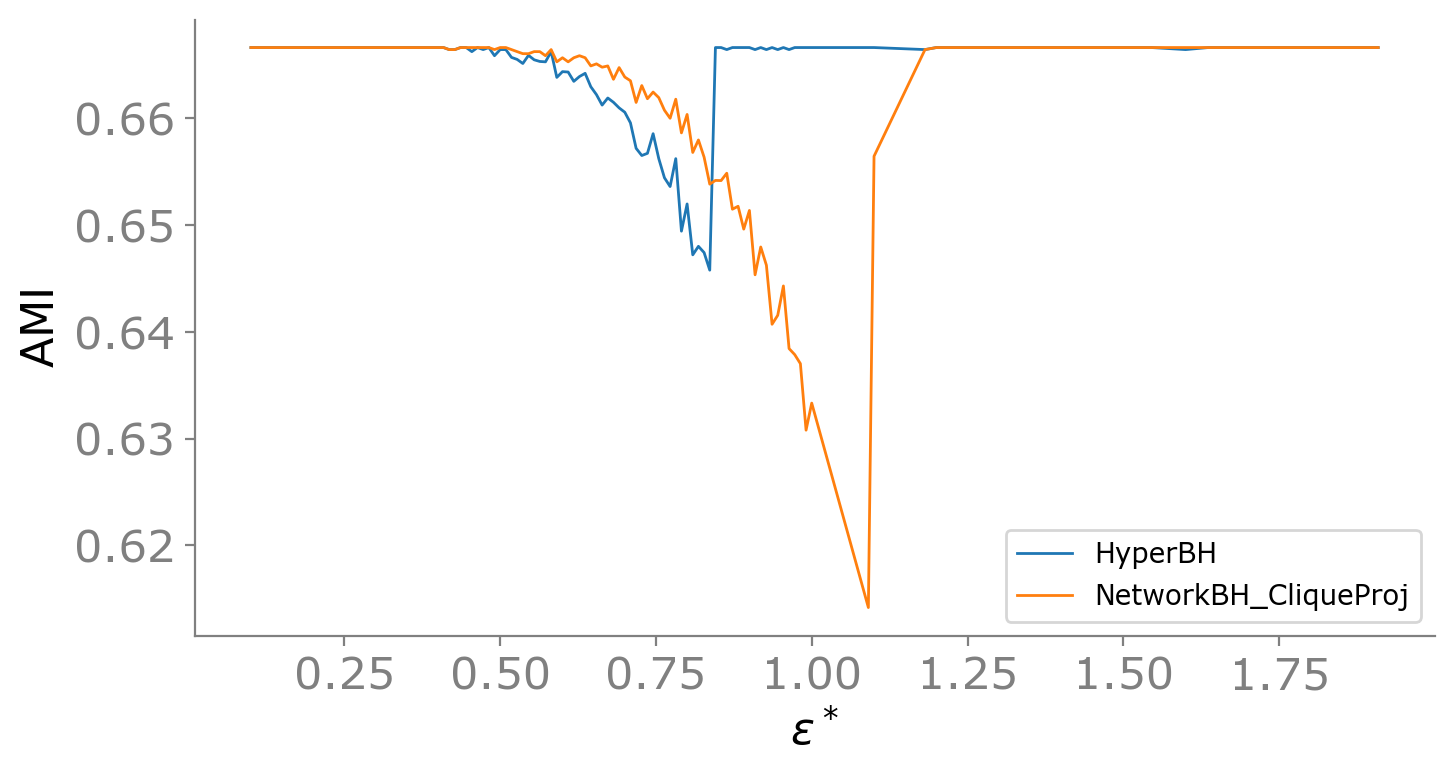

In [6]:
fig = plt.figure(figsize=(8, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

index = np.where(epsilons<2)[0]
ax.plot(epsilons[index], results[index, 2], lw=1, label="HyperBH")
ax.plot(epsilons[index], results[index, 5], lw=1, label="NetworkBH_CliqueProj")
ax.set_xlabel(r"$\epsilon^*$", fontsize=16)
ax.set_ylabel(r"$\rm AMI$", fontsize=16)
plt.legend(loc="lower right", fontsize=10)

save_path = f"./_Figure/Hyper/" + f"OrderEffect_8.15.pdf"
plt.savefig(save_path, dpi=600)

In [3]:
load_path = "./result/hyperOrderEffect/exp8.15_onlyassort.txt"
epsilons, results = read_exp(load_path=load_path)

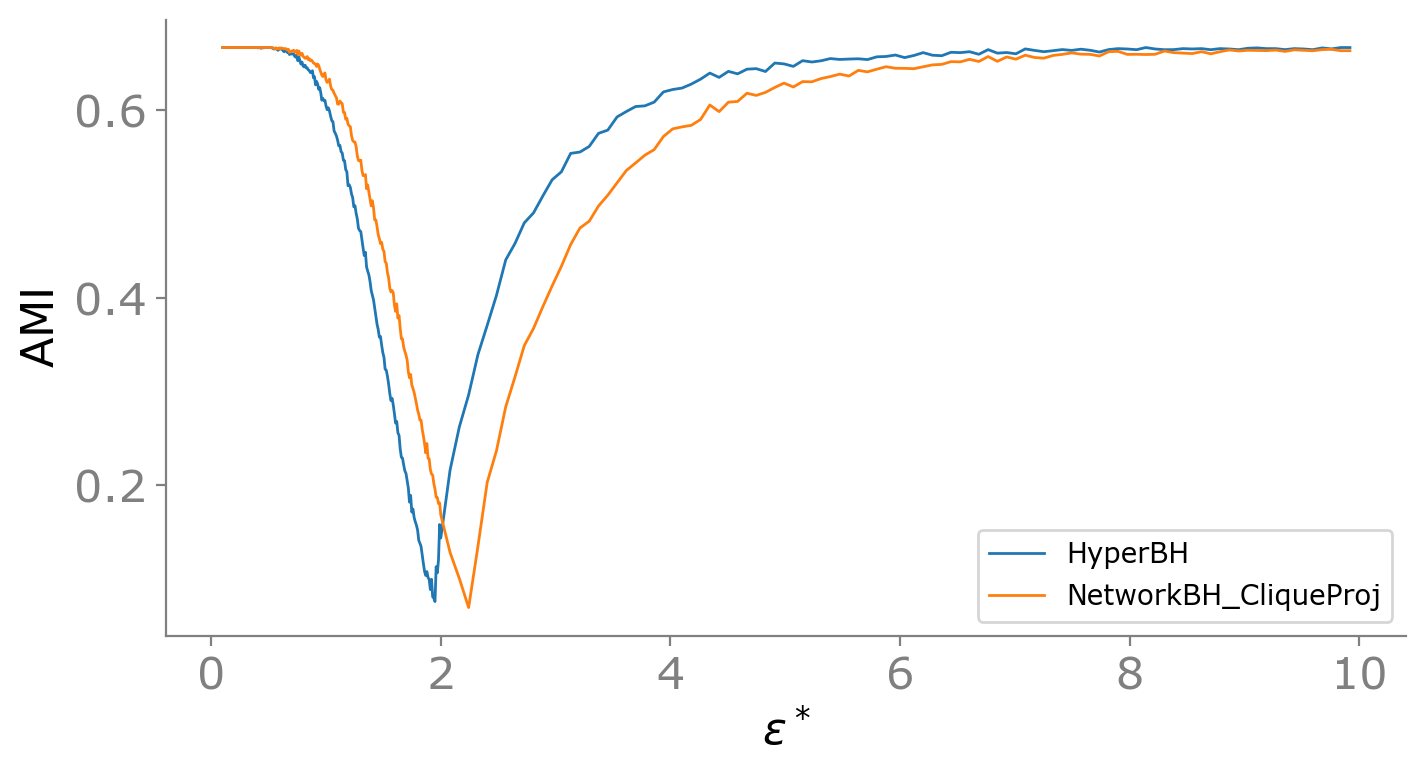

In [5]:
fig = plt.figure(figsize=(8, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

index = np.where(epsilons<10)[0]
ax.plot(epsilons[index], results[index, 2], lw=1, label="HyperBH")
ax.plot(epsilons[index], results[index, 5], lw=1, label="NetworkBH_CliqueProj")
ax.set_xlabel(r"$\epsilon^*$", fontsize=16)
ax.set_ylabel(r"$\rm AMI$", fontsize=16)
plt.legend(loc="lower right", fontsize=10)

save_path = f"./_Figure/Hyper/" + f"OrderEffect_8.15_onlyassort.pdf"
plt.savefig(save_path, dpi=600)

# AMI compared to 2 specific groups under various $\epsilon^*$

In [8]:
load_path = "./result/hyperOrderEffect/exp8.18_onlyassort_amiwith2settinggroup.txt"
epsilons, results = read_exp(load_path=load_path)
print(np.shape(results))

(298, 5)


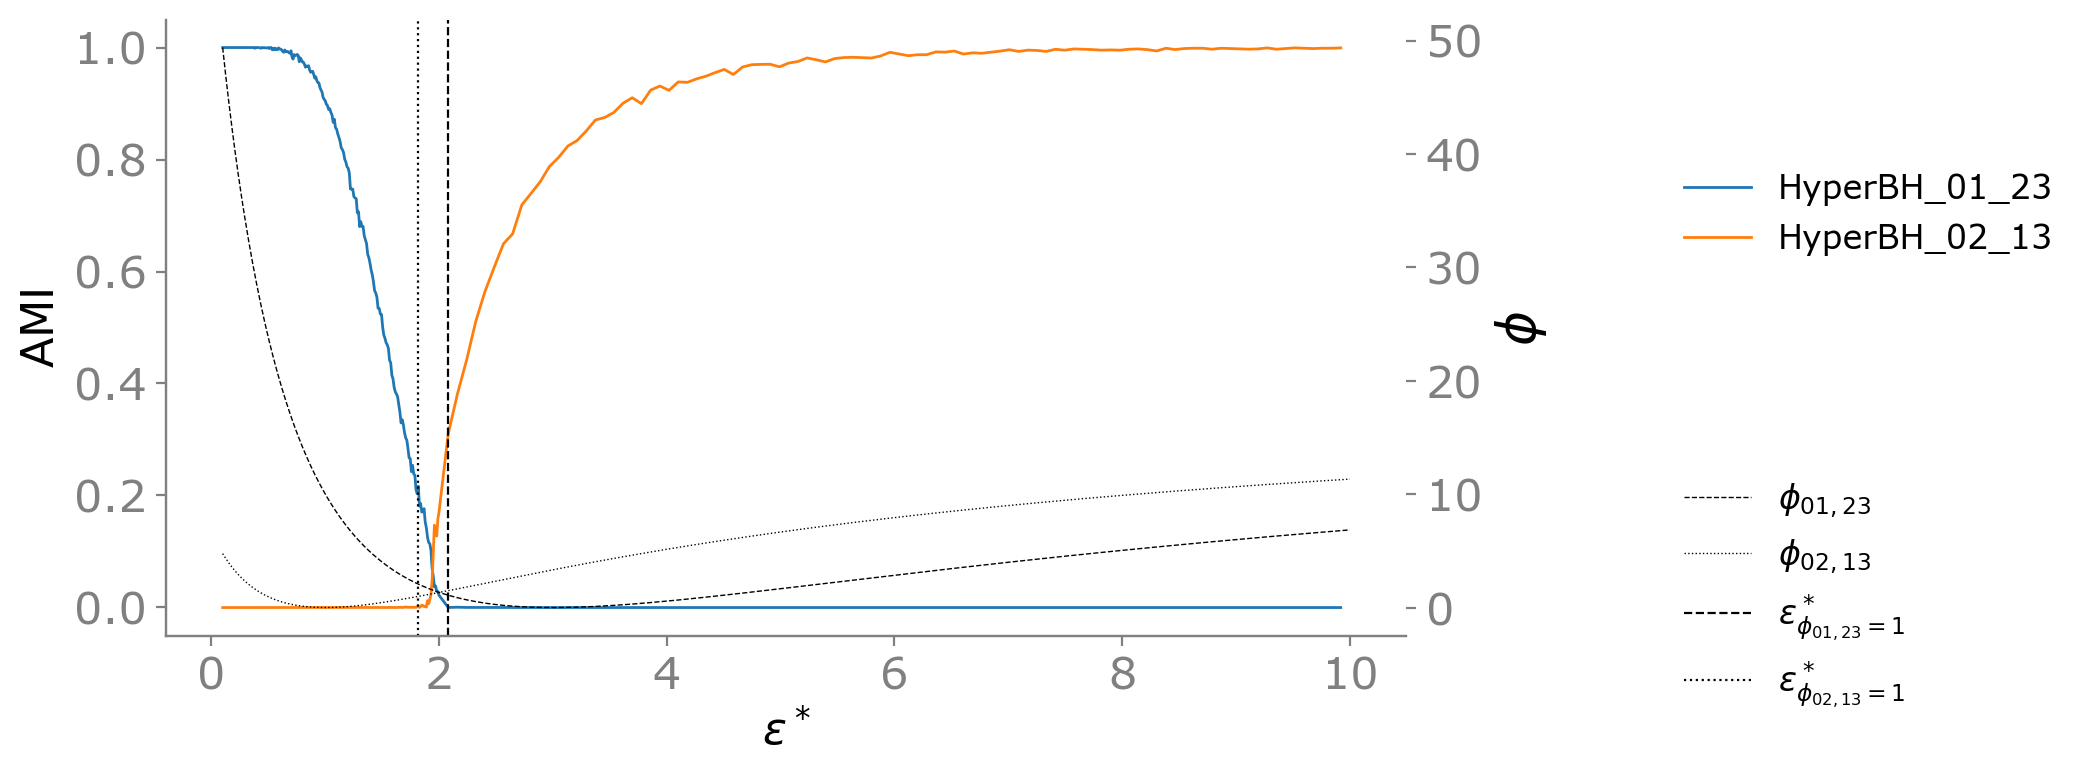

In [34]:
fig = plt.figure(figsize=(8, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

index = np.where(epsilons<10)[0]
ax.plot(epsilons[index], results[index, 1], lw=1, label="HyperBH_01_23")
ax.plot(epsilons[index], results[index, 2], lw=1, label="HyperBH_02_13")
# ax.plot(epsilons[index], results[index, 3], lw=1, label="CliqueProjNetworkBH_01_23")
# ax.plot(epsilons[index], results[index, 4], lw=1, label="CliqueProjNetworkBH_02_13")
ax.set_xlabel(r"$\epsilon^*$", fontsize=16)
ax.set_ylabel(r"$\rm AMI$", fontsize=16)
plt.legend(loc=2, bbox_to_anchor=(1.2, 0.8),  fontsize=12, markerscale=2, frameon=False)

ax_twin = ax.twinx()
ax_twin.plot(epsilon_stars, phis_2group_hyper_01_23, ls='--', color="black",  lw=0.5, label=r"$\phi_{01,23}$")
ax_twin.plot(epsilon_stars, phis_2group_hyper_02_13, ls=':', color="black",  lw=0.5, label=r"$\phi_{02,13}$")
ax_twin.axvline(critical_estar_01_23[0], color='black', lw=0.8, ls='--', label=r'$\epsilon^*_{\phi_{01,23}=1}$')
ax_twin.axvline(critical_estar_02_13[1], color='black', lw=0.8, ls=':', label=r'$\epsilon^*_{\phi_{02,13}=1}$')
ax_twin.set_ylabel(r'$\phi$')
plt.legend(loc="lower right", fontsize=10)
plt.legend(loc=2, bbox_to_anchor=(1.2, 0.3),  fontsize=12, markerscale=2, frameon=False)

# save_path = f"./_Figure/Hyper/" + f"OrderEffect_8.15_onlyassort.pdf"
# plt.savefig(save_path, dpi=600)

In [8]:
def get_snr_2group(epsilon_star, d, n, q):
    a = q**2*d*epsilon_star / (2*(epsilon_star + 1))
    b = n * a / (epsilon_star * (n/q-1))
    snr_2group_hyper = np.abs(6*b*(n/q-1)-4*a*n) / np.sqrt(n*q**2*(2*b*(n/q-1)+2*a*n))
    return snr_2group_hyper

In [20]:
def get_phi_2group(epsilon_star, d, n, q, aggregate="01_23"):
    a = q**2*d*epsilon_star / (2*(epsilon_star + 1))
    b = n * a / (epsilon_star * (n/q-1))
    if aggregate == "01_23":
        cout_2 = a/2
        cin_3 = 3*b/(2*q)
        c_2 = (a / 2) / 2
        c_3 = (((3*b)/(2*q)) / (3-1)) / 2
        phi_2group_hyper = (-cout_2+cin_3)**2 / (2**2*(c_2+c_3*(3-1)))
    elif aggregate =="02_13":
        cin_2 = a/2
        cin_3 = b / (2*q)
        cout_3 = b / q
        c_2 = (a / 2) / 2
        c_3 = (((3*b)/(2*q)) / (3-1)) / 2
        phi_2group_hyper = (cin_2+cin_3-cout_3)**2 / (2**2*(c_2+c_3*(3-1)))
    return phi_2group_hyper

In [36]:
epsilon_stars = np.unique(np.concatenate((np.linspace(0.1, 1, 100), np.linspace(1, 2, 100), np.linspace(2, 10, 100))))
n=4000
q=4
d=10
# snrs_2group_hyper = [get_snr_2group(e, d, n, q) for e in epsilon_stars]
phis_2group_hyper_01_23 = [get_phi_2group(e, d, n, q) for e in epsilon_stars]
phis_2group_hyper_02_13 = [get_phi_2group(e, d, n, q, aggregate="02_13") for e in epsilon_stars]
ones = np.array([1]*len(epsilon_stars))
idx = np.argwhere(np.diff(np.sign(phis_2group_hyper_01_23 - ones))).flatten()
critical_estar_01_23 = epsilon_stars[idx]
print(critical_estar_01_23)
idx = np.argwhere(np.diff(np.sign(phis_2group_hyper_02_13 - ones))).flatten()
critical_estar_02_13 = epsilon_stars[idx]
print(critical_estar_02_13)

switch_idx = np.argwhere(np.diff(np.sign(np.array(phis_2group_hyper_01_23) - np.array(phis_2group_hyper_02_13)))).flatten()
critical_estar_switch = epsilon_stars[switch_idx]
print(critical_estar_switch)

[2.08080808 4.34343434]
[0.48181818 1.81818182]
[2.]


In [4]:
n=4000
q=4
d=10
epsilon_star = 2
a = q**2*d*epsilon_star / (2*(epsilon_star + 1))
b = n * a / (epsilon_star * (n/q-1))
print(a, b, a/b, n*a/((n/q-1)*b))

53.333333333333336 106.77344010677345 0.4995 2.0


In [2]:
n*q**2*d/(2*(n/q-1)*(epsilon_star+1))

106.77344010677344

# switch point for two community structure

In [3]:
def get_epsilon_star_switch(k, k_star):
    return 2**(k_star-k)*((2**(k-1)-1)/(2**(k_star-1)-1))*(math.comb(k_star, 2)/math.comb(k, 2))

In [20]:
load_path = "./result/hyperOrderEffect/exp8.18_onlyassort_amiwith2settinggroup.txt"
epsilons, results = read_exp(load_path=load_path)
# print(np.shape(results))
k = 2
k_star = 3
epsilon_star_switch = get_epsilon_star_switch(k, k_star)
print(epsilon_star_switch)

2.0


D:\BackProgram\Anaconda\envs\network\Lib\site-packages\matplotlib_inline\config.py:68: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):


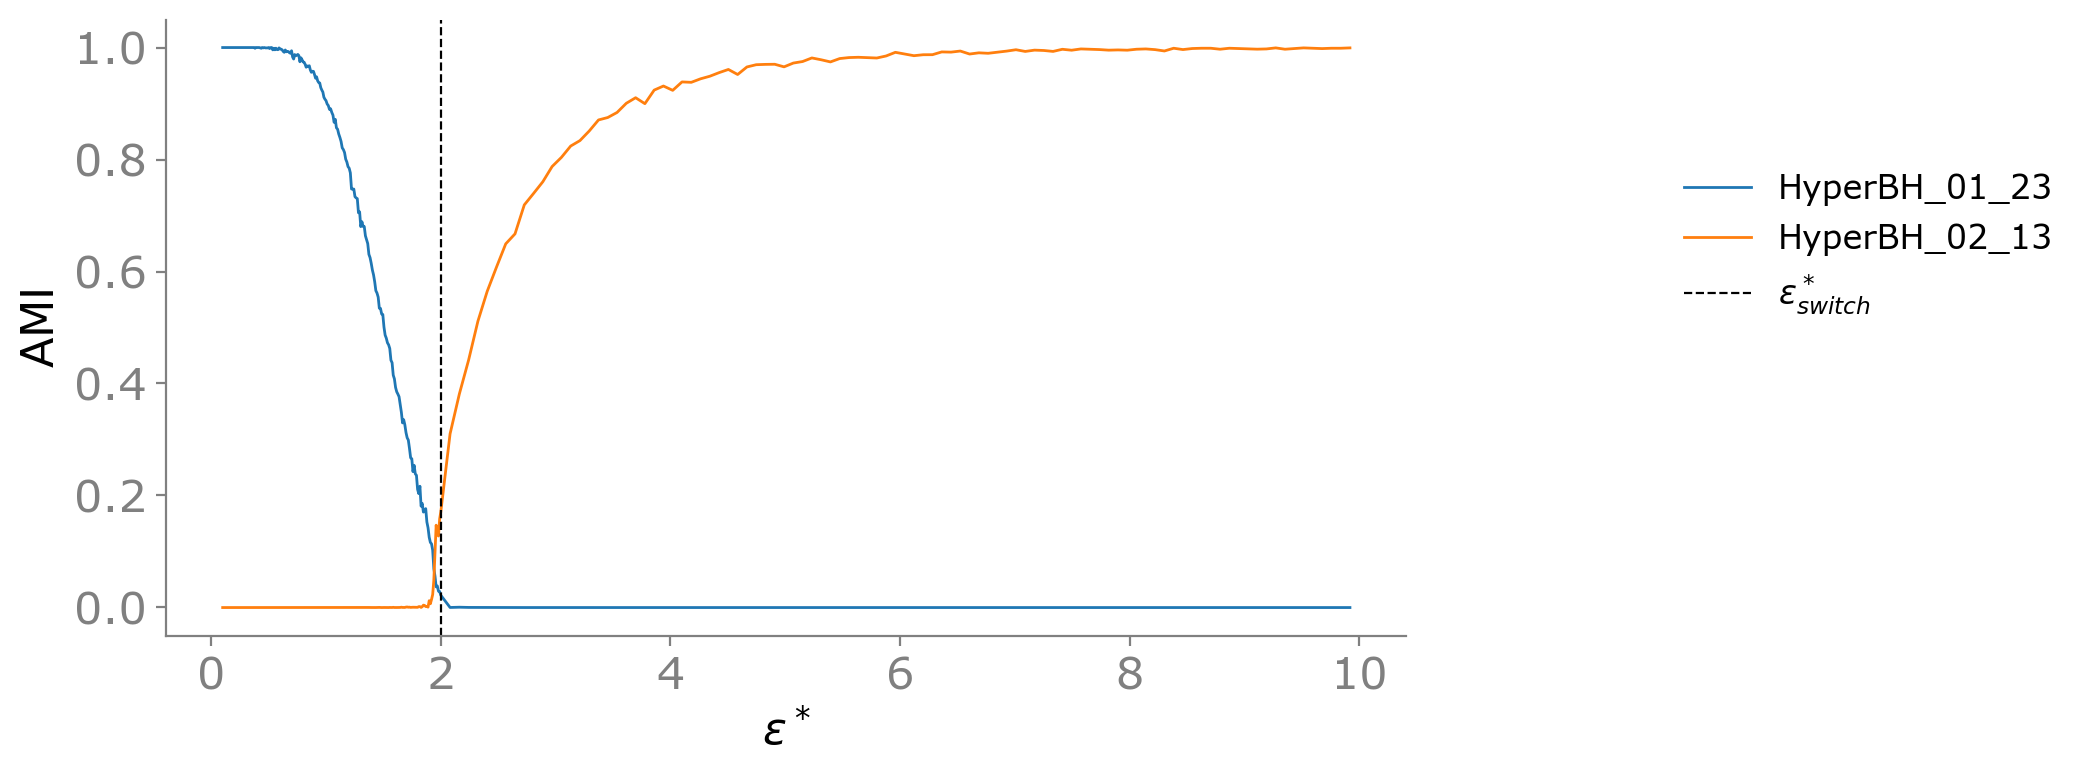

In [21]:
fig = plt.figure(figsize=(8, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

index = np.where(epsilons<10)[0]
ax.plot(epsilons[index], results[index, 1], lw=1, label="HyperBH_01_23")
ax.plot(epsilons[index], results[index, 2], lw=1, label="HyperBH_02_13")
# ax.plot(epsilons[index], results[index, 3], lw=1, label="CliqueProjNetworkBH_01_23")
# ax.plot(epsilons[index], results[index, 4], lw=1, label="CliqueProjNetworkBH_02_13")
ax.axvline(epsilon_star_switch, color='black', lw=0.8, ls='--', label=r'$\epsilon^*_{switch}$')
ax.set_xlabel(r"$\epsilon^*$", fontsize=16)
ax.set_ylabel(r"$\rm AMI$", fontsize=16)
plt.legend(loc=2, bbox_to_anchor=(1.2, 0.8),  fontsize=12, markerscale=2, frameon=False)

# save_path = f"./_Figure/Hyper/" + f"OrderEffect_8.15_onlyassort.pdf"
# plt.savefig(save_path, dpi=600)

In [12]:
n = 4000
d = 10
Ks = (2, 3, )
load_path = f"./result/hyperOrderEffect/exp8.26_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}.txt"
epsilons, results = read_exp(load_path=load_path)
# print(np.shape(results))
k = 2
k_star = 3
epsilon_star_switch = get_epsilon_star_switch(k, k_star)
print(epsilon_star_switch)

2.0


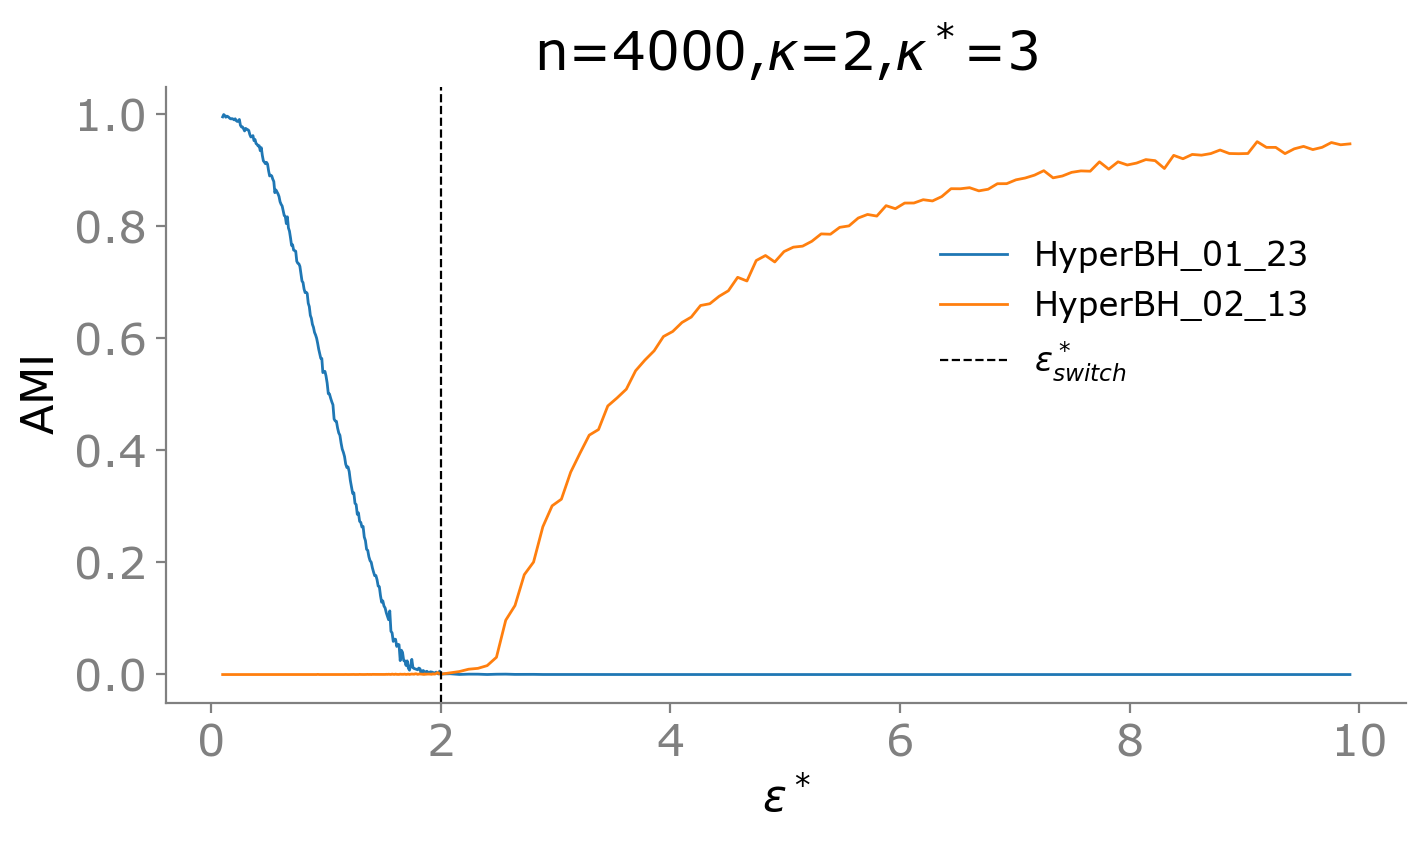

In [13]:
fig = plt.figure(figsize=(8, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

index = np.where(epsilons<10)[0]
ax.plot(epsilons[index], results[index, 1], lw=1, label="HyperBH_01_23")
ax.plot(epsilons[index], results[index, 2], lw=1, label="HyperBH_02_13")
# ax.plot(epsilons[index], results[index, 3], lw=1, label="CliqueProjNetworkBH_01_23")
# ax.plot(epsilons[index], results[index, 4], lw=1, label="CliqueProjNetworkBH_02_13")
ax.axvline(epsilon_star_switch, color='black', lw=0.8, ls='--', label=r'$\epsilon^*_{switch}$')
ax.set_xlabel(r"$\epsilon^*$", fontsize=16)
ax.set_ylabel(r"$\rm AMI$", fontsize=16)
ax.set_title(rf"n={n},$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}")
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.8),  fontsize=12, markerscale=2, frameon=False)

# save_path = f"./_Figure/Hyper/" + f"OrderEffect_8.15_onlyassort.pdf"
# plt.savefig(save_path, dpi=600)

In [6]:
n = 8000
d = 10
Ks = (2, 3, )
load_path = f"./result/hyperOrderEffect/exp8.26_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}.txt"
epsilons, results = read_exp(load_path=load_path)
# print(np.shape(results))
k = 2
k_star = 3
epsilon_star_switch = get_epsilon_star_switch(k, k_star)
print(epsilon_star_switch)

2.0


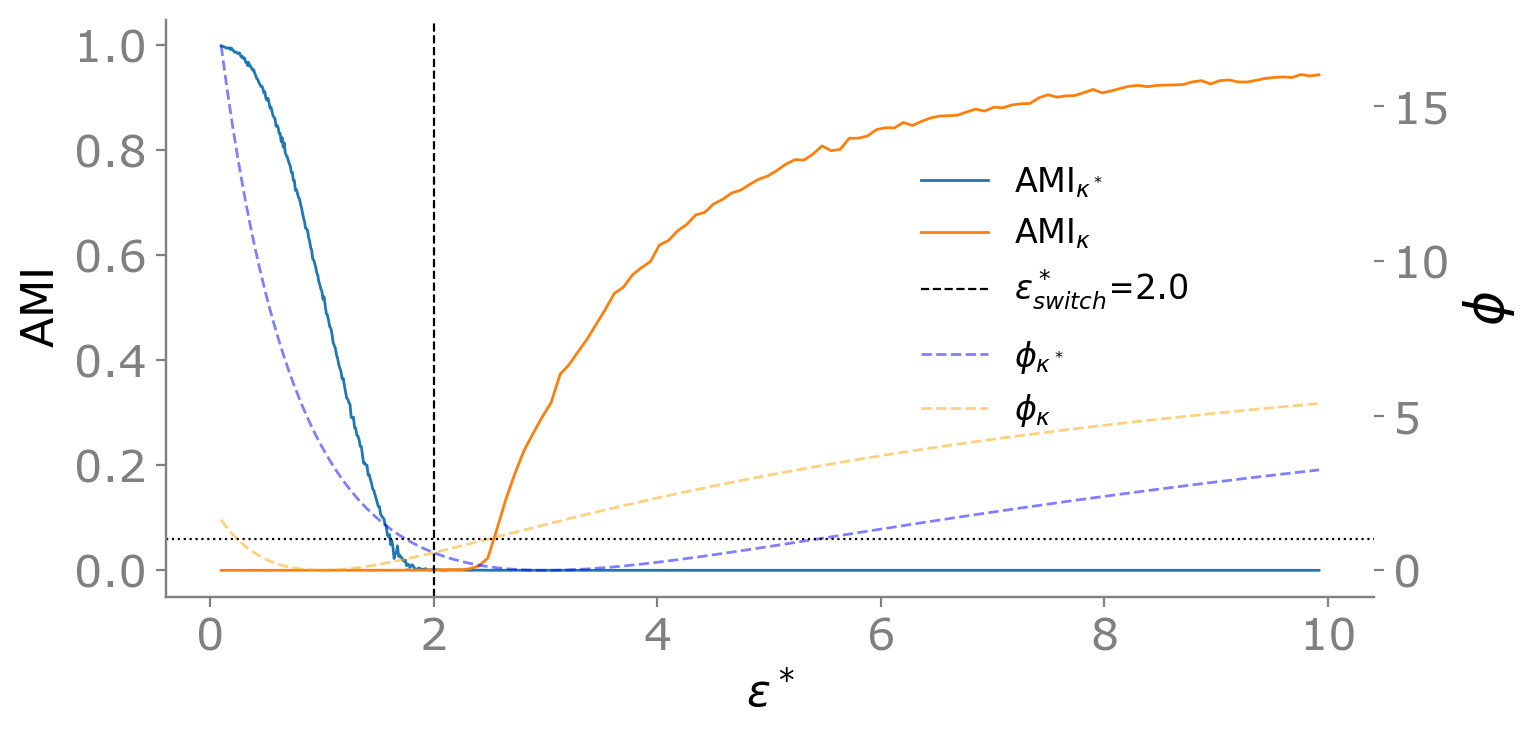

In [15]:
k = Ks[0]
k_star = Ks[1]
d = 10
aoverastar = []
phi_01_23 = []
phi_02_13 = []
for e in epsilons:
    a, astar = get_a_over_astar(e, k, k_star, d)
    aoverastar.append(a/astar)
    phi_01_23.append(get_phi(a, astar, k, k_star, community_conf="01_23"))
    phi_02_13.append(get_phi(a, astar, k, k_star, community_conf="02_13"))
# print(phi_01_23)
fig = plt.figure(figsize=(8, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

index = np.where(epsilons<10)[0]
ax.plot(epsilons[index], results[index, 1], lw=1, label=r"$\mathrm{AMI}_{\kappa^*}$")
ax.plot(epsilons[index], results[index, 2], lw=1, label=r"$\mathrm{AMI}_{\kappa}$")
ax.axvline(epsilon_star_switch, color='black', lw=0.8, ls='--', label=r'$\epsilon^*_{switch}$'+f"={np.round(epsilon_star_switch, 3)}")
# ax.plot(np.array(aoverastar)[index], results[index, 1], lw=1, label="HyperBH_01_23")
# ax.plot(np.array(aoverastar)[index], results[index, 2], lw=1, label="HyperBH_02_13")
# aoverastar_switch = (2**(k-2)*math.factorial(k-2))/ (2**(k_star-2)*math.factorial(k_star-2))
# ax.axvline(aoverastar_switch, color='black', lw=0.8, ls='--', label=r'$\frac{a}{a^*}_{switch}$'+f"={np.round(epsilon_star_switch, 3)}")
ax.set_xlabel(r"$\epsilon^*$", fontsize=16)
ax.set_ylabel(r"$\rm AMI$", fontsize=16)
# ax.set_title(rf"n={n},$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}")
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.8),  fontsize=12, markerscale=2, frameon=False)

ax_twin = ax.twinx()
ax_twin.plot(epsilons[index], np.array(phi_01_23)[index], lw=1, ls='--', color="blue", label=r"$\phi_{\kappa^*}$", alpha=0.5)
ax_twin.plot(epsilons[index], np.array(phi_02_13)[index], lw=1, ls='--', color="orange", label=r"$\phi_{\kappa}$", alpha=0.5)
# ax_twin.plot(np.array(aoverastar)[index], np.array(phi_01_23)[index], lw=1, ls='--', color="blue", label="phi_01_23")
# ax_twin.plot(np.array(aoverastar)[index], np.array(phi_02_13)[index], lw=1, ls='--', color="orange", label="phi_02_13")
ax_twin.set_ylabel(r'$\phi$')
ax_twin.axhline(1, color='black', lw=0.8, ls=':')
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.5),  fontsize=12, markerscale=2, frameon=False)

save_path = f"./_Figure/Hyper/OrderEffect/" + f"Figure_Appendix_n={n}_k={k}_kstar={k_star}.pdf"
plt.tight_layout()
plt.savefig(save_path, dpi=600)

In [26]:
n = 4000
d = 10
Ks = (2, 4, )
load_path = f"./result/hyperOrderEffect/exp8.26_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}.txt"
epsilons, results = read_exp(load_path=load_path)
# print(np.shape(results))
k = Ks[0]
k_star = Ks[1]
epsilon_star_switch = get_epsilon_star_switch(k, k_star)
print(epsilon_star_switch)

3.4285714285714284


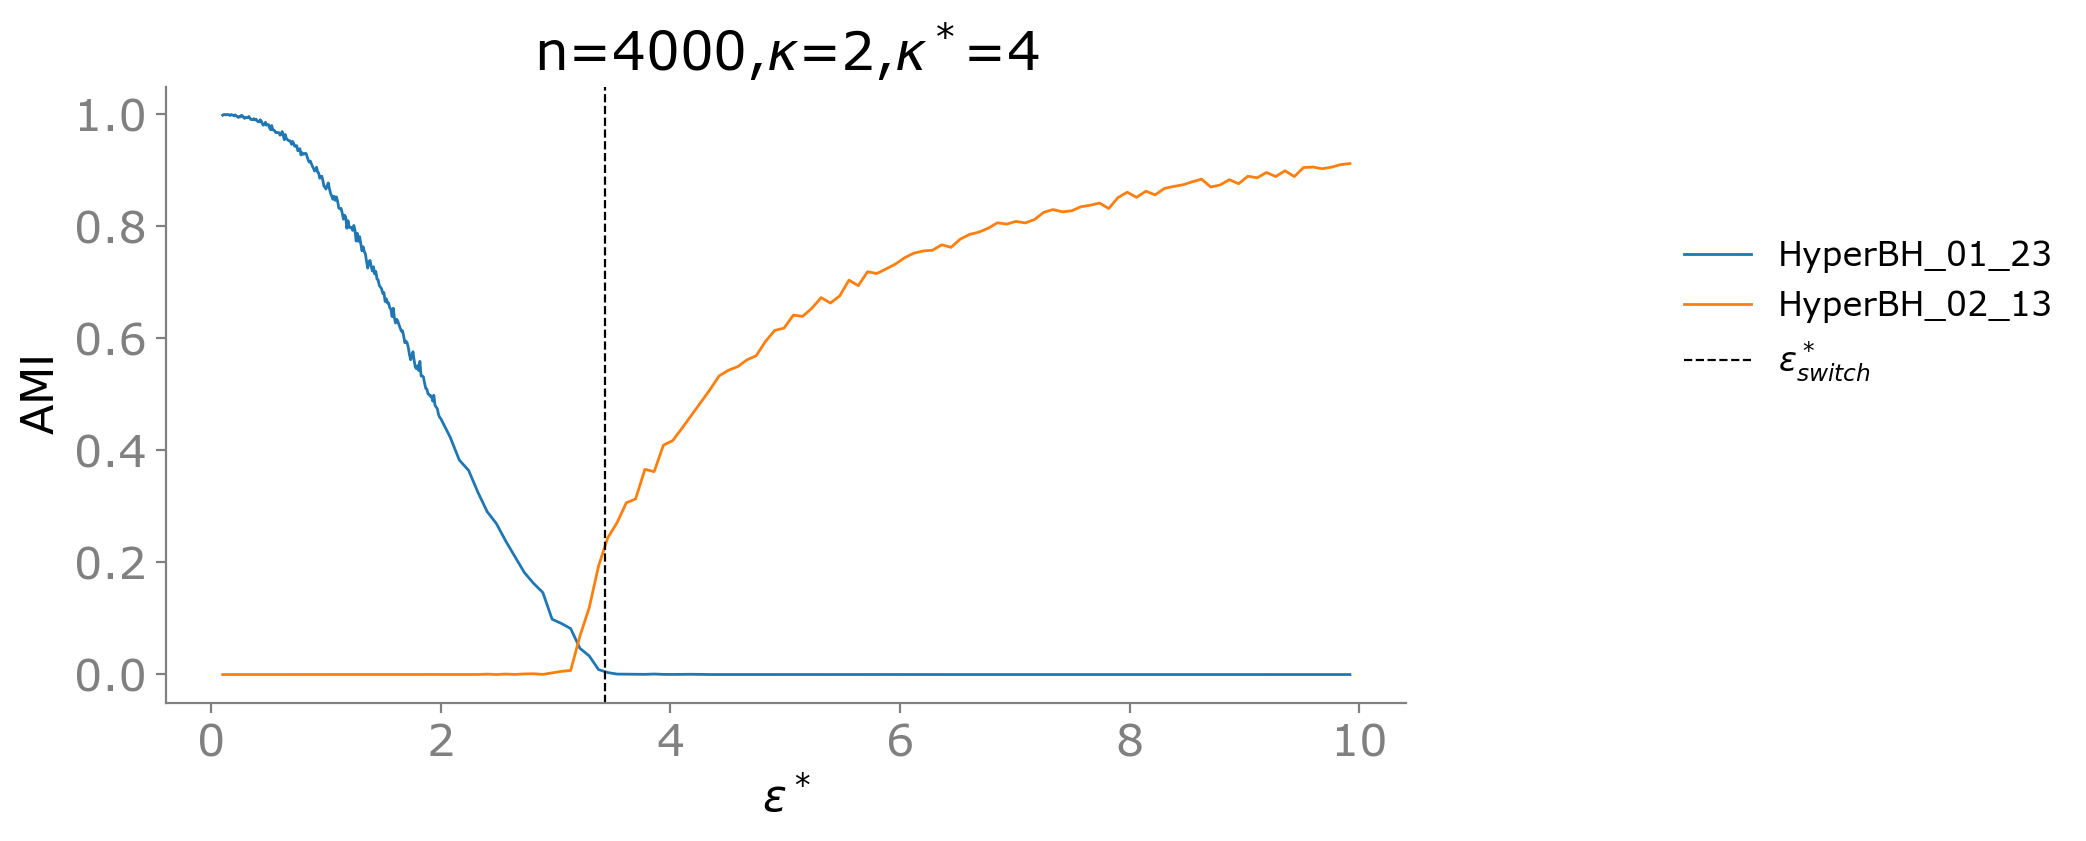

In [37]:
fig = plt.figure(figsize=(8, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

index = np.where(epsilons<10)[0]
ax.plot(epsilons[index], results[index, 1], lw=1, label="HyperBH_01_23")
ax.plot(epsilons[index], results[index, 2], lw=1, label="HyperBH_02_13")
# ax.plot(epsilons[index], results[index, 3], lw=1, label="CliqueProjNetworkBH_01_23")
# ax.plot(epsilons[index], results[index, 4], lw=1, label="CliqueProjNetworkBH_02_13")
ax.axvline(epsilon_star_switch, color='black', lw=0.8, ls='--', label=r'$\epsilon^*_{switch}$')
ax.set_xlabel(r"$\epsilon^*$", fontsize=16)
ax.set_ylabel(r"$\rm AMI$", fontsize=16)
ax.set_title(rf"n={n},$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}")
plt.legend(loc=2, bbox_to_anchor=(1.2, 0.8),  fontsize=12, markerscale=2, frameon=False)

# save_path = f"./_Figure/Hyper/" + f"OrderEffect_8.15_onlyassort.pdf"
# plt.savefig(save_path, dpi=600)

In [100]:
n = 8000
d = 10
Ks = (2, 4, )
load_path = f"./result/hyperOrderEffect/exp8.26_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}.txt"
epsilons, results = read_exp(load_path=load_path)
# print(np.shape(results))
k = Ks[0]
k_star = Ks[1]
epsilon_star_switch = get_epsilon_star_switch(k, k_star)
print(epsilon_star_switch)

3.4285714285714284


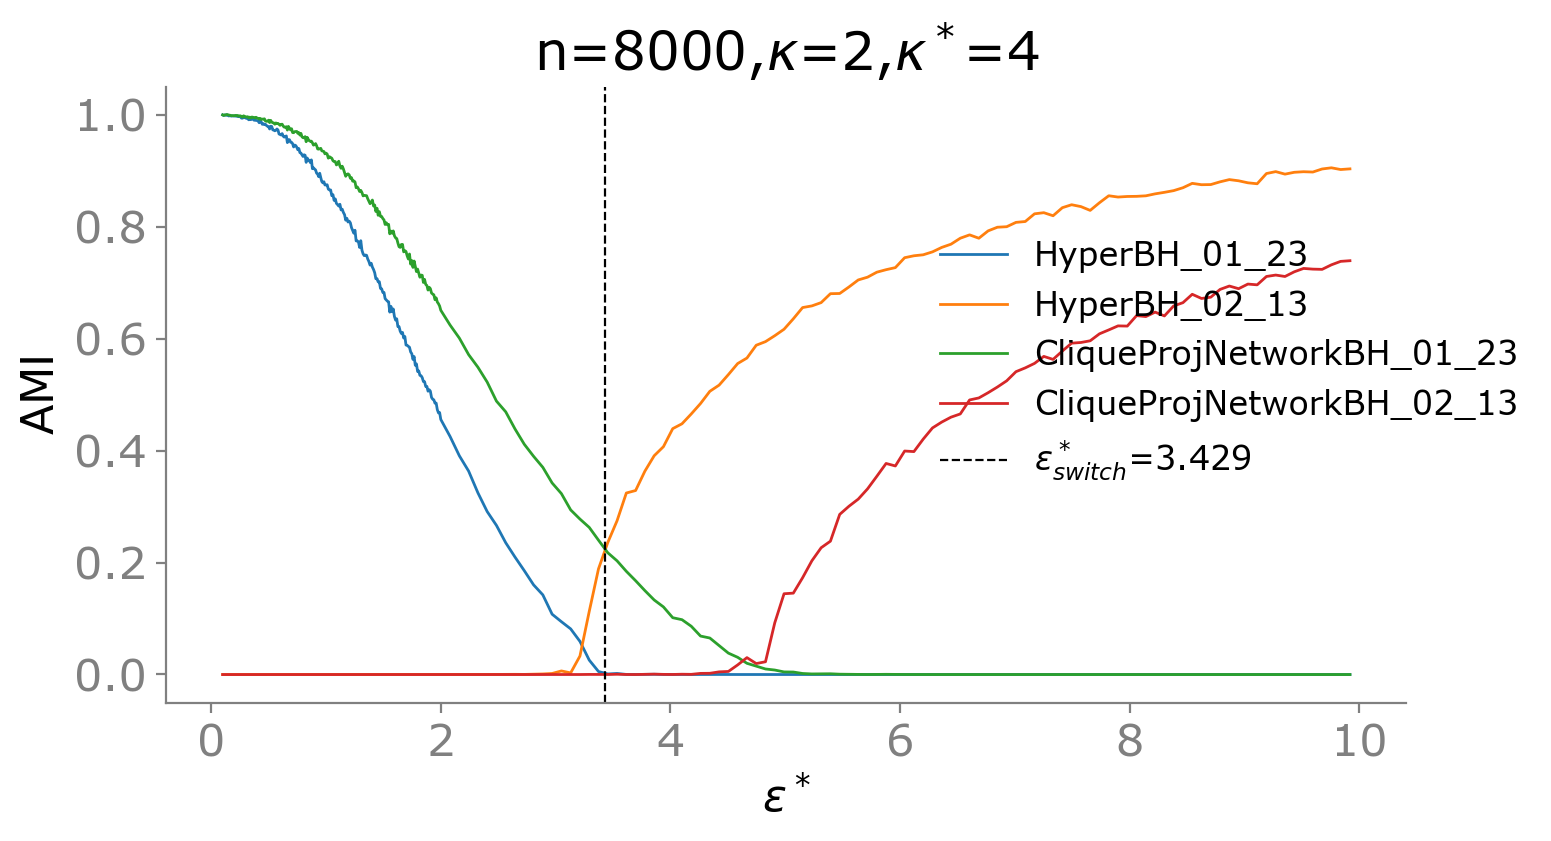

In [17]:
fig = plt.figure(figsize=(8, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

index = np.where(epsilons<10)[0]
ax.plot(epsilons[index], results[index, 1], lw=1, label="HyperBH_01_23")
ax.plot(epsilons[index], results[index, 2], lw=1, label="HyperBH_02_13")
ax.plot(epsilons[index], results[index, 3], lw=1, label="CliqueProjNetworkBH_01_23")
ax.plot(epsilons[index], results[index, 4], lw=1, label="CliqueProjNetworkBH_02_13")
ax.axvline(epsilon_star_switch, color='black', lw=0.8, ls='--', label=r'$\epsilon^*_{switch}$'+f"={np.round(epsilon_star_switch, 3)}")
ax.set_xlabel(r"$\epsilon^*$", fontsize=16)
ax.set_ylabel(r"$\rm AMI$", fontsize=16)
ax.set_title(rf"n={n},$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}")
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.8),  fontsize=12, markerscale=2, frameon=False)

# save_path = f"./_Figure/Hyper/" + f"OrderEffect_8.15_onlyassort.pdf"
# plt.savefig(save_path, dpi=600)

In [34]:
n = 8000
d = 10
Ks = (2, 5, )
load_path = f"./result/hyperOrderEffect/exp8.26_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}.txt"
epsilons, results = read_exp(load_path=load_path)
# print(np.shape(results))
k = Ks[0]
k_star = Ks[1]
epsilon_star_switch = get_epsilon_star_switch(k, k_star)
print(epsilon_star_switch)

5.333333333333333


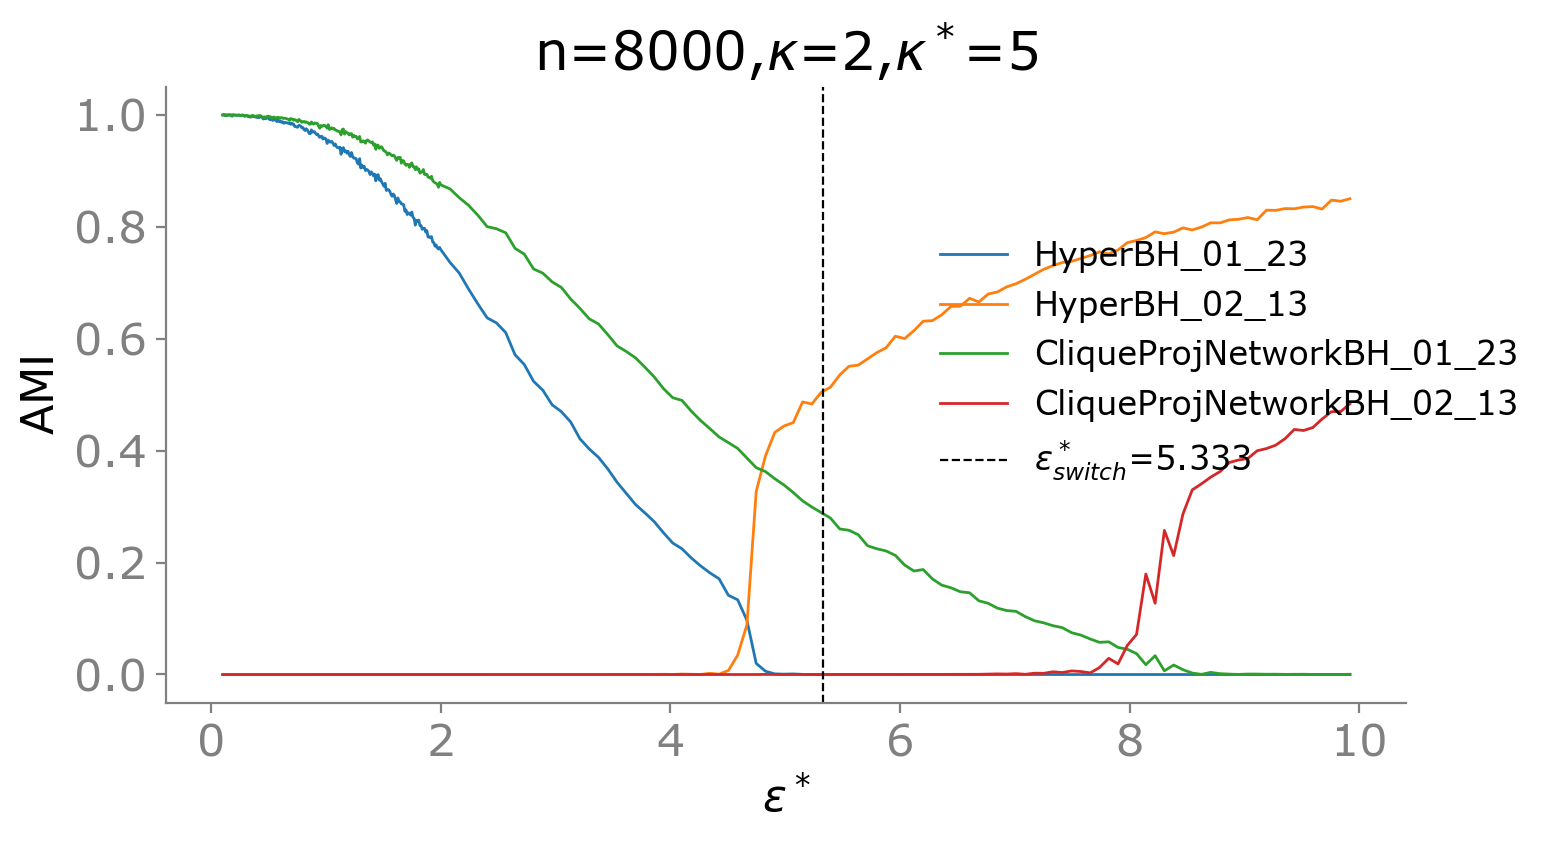

In [14]:
fig = plt.figure(figsize=(8, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

index = np.where(epsilons<10)[0]
ax.plot(epsilons[index], results[index, 1], lw=1, label="HyperBH_01_23")
ax.plot(epsilons[index], results[index, 2], lw=1, label="HyperBH_02_13")
ax.plot(epsilons[index], results[index, 3], lw=1, label="CliqueProjNetworkBH_01_23")
ax.plot(epsilons[index], results[index, 4], lw=1, label="CliqueProjNetworkBH_02_13")
ax.axvline(epsilon_star_switch, color='black', lw=0.8, ls='--', label=r'$\epsilon^*_{switch}$'+f'={np.round(epsilon_star_switch, 3)}')
ax.set_xlabel(r"$\epsilon^*$", fontsize=16)
ax.set_ylabel(r"$\rm AMI$", fontsize=16)
ax.set_title(rf"n={n},$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}")
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.8),  fontsize=12, markerscale=2, frameon=False)

# save_path = f"./_Figure/Hyper/" + f"OrderEffect_8.15_onlyassort.pdf"
# plt.savefig(save_path, dpi=600)

In [128]:
n = 8000
d = 10
Ks = (3, 4, )
load_path = f"./result/hyperOrderEffect/exp8.26_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}.txt"
epsilons, results = read_exp(load_path=load_path)
# print(np.shape(results))
k = Ks[0]
k_star = Ks[1]
epsilon_star_switch = get_epsilon_star_switch(k, k_star)
print(epsilon_star_switch)

1.7142857142857142


D:\BackProgram\Anaconda\envs\network\Lib\site-packages\matplotlib_inline\config.py:68: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):


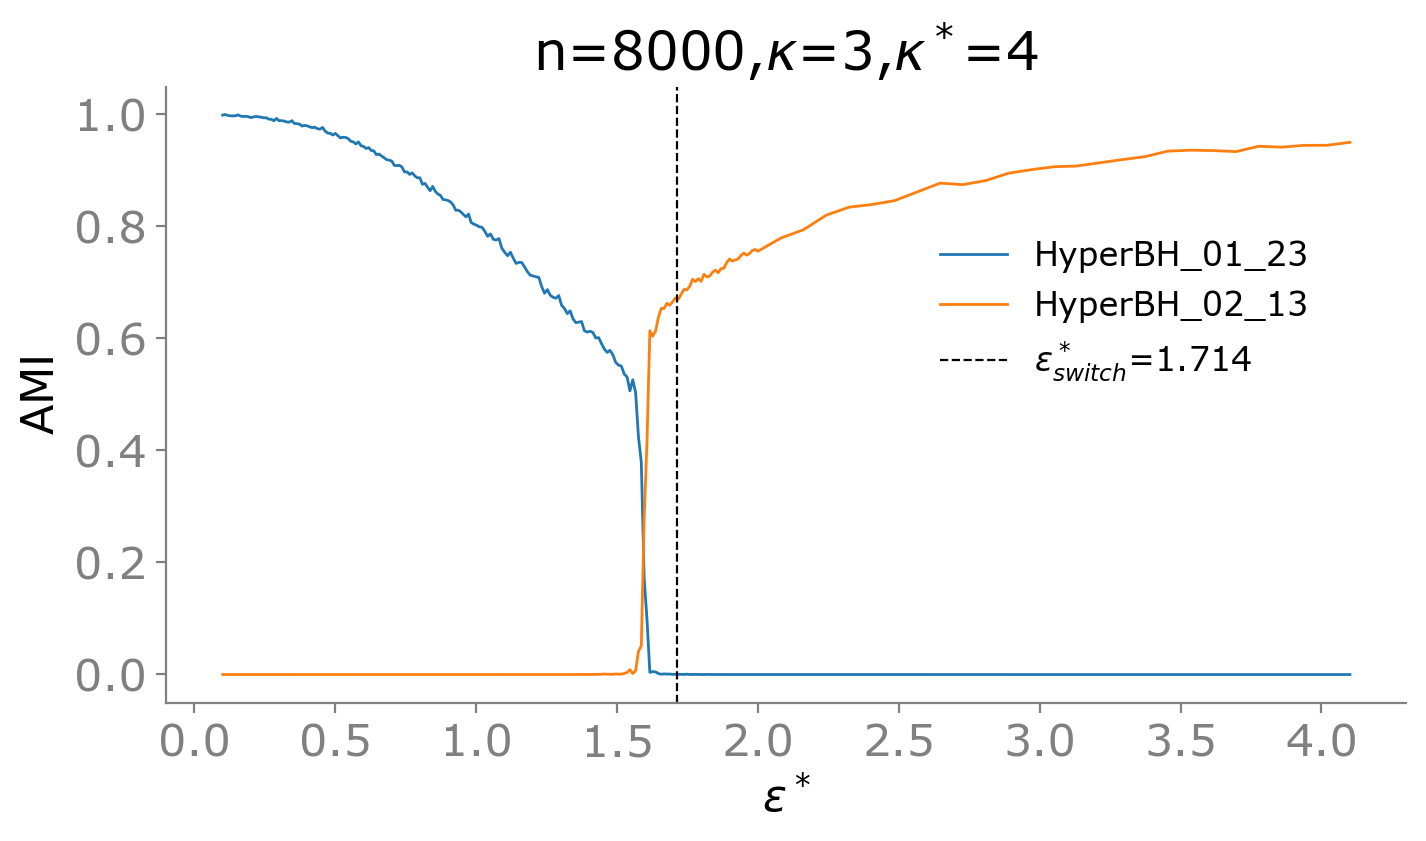

In [5]:
fig = plt.figure(figsize=(8, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

index = np.where(epsilons<10)[0]
ax.plot(epsilons[index], results[index, 1], lw=1, label="HyperBH_01_23")
ax.plot(epsilons[index], results[index, 2], lw=1, label="HyperBH_02_13")
# ax.plot(epsilons[index], results[index, 3], lw=1, label="CliqueProjNetworkBH_01_23")
# ax.plot(epsilons[index], results[index, 4], lw=1, label="CliqueProjNetworkBH_02_13")
ax.axvline(epsilon_star_switch, color='black', lw=0.8, ls='--', label=r'$\epsilon^*_{switch}$'+f"={np.round(epsilon_star_switch, 3)}")
ax.set_xlabel(r"$\epsilon^*$", fontsize=16)
ax.set_ylabel(r"$\rm AMI$", fontsize=16)
ax.set_title(rf"n={n},$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}")
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.8),  fontsize=12, markerscale=2, frameon=False)

# save_path = f"./_Figure/Hyper/" + f"OrderEffect_8.15_onlyassort.pdf"
# plt.savefig(save_path, dpi=600)

In [49]:
n = 8000
d = 10
Ks = (4, 4, )
load_path = f"./result/hyperOrderEffect/exp8.26_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}.txt"
epsilons, results = read_exp(load_path=load_path)
# print(np.shape(results))
k = Ks[0]
k_star = Ks[1]
# epsilon_star_switch = get_epsilon_star_switch(k, k_star)
epsilon_star_switch = 2/3
print(epsilon_star_switch)

0.6666666666666666


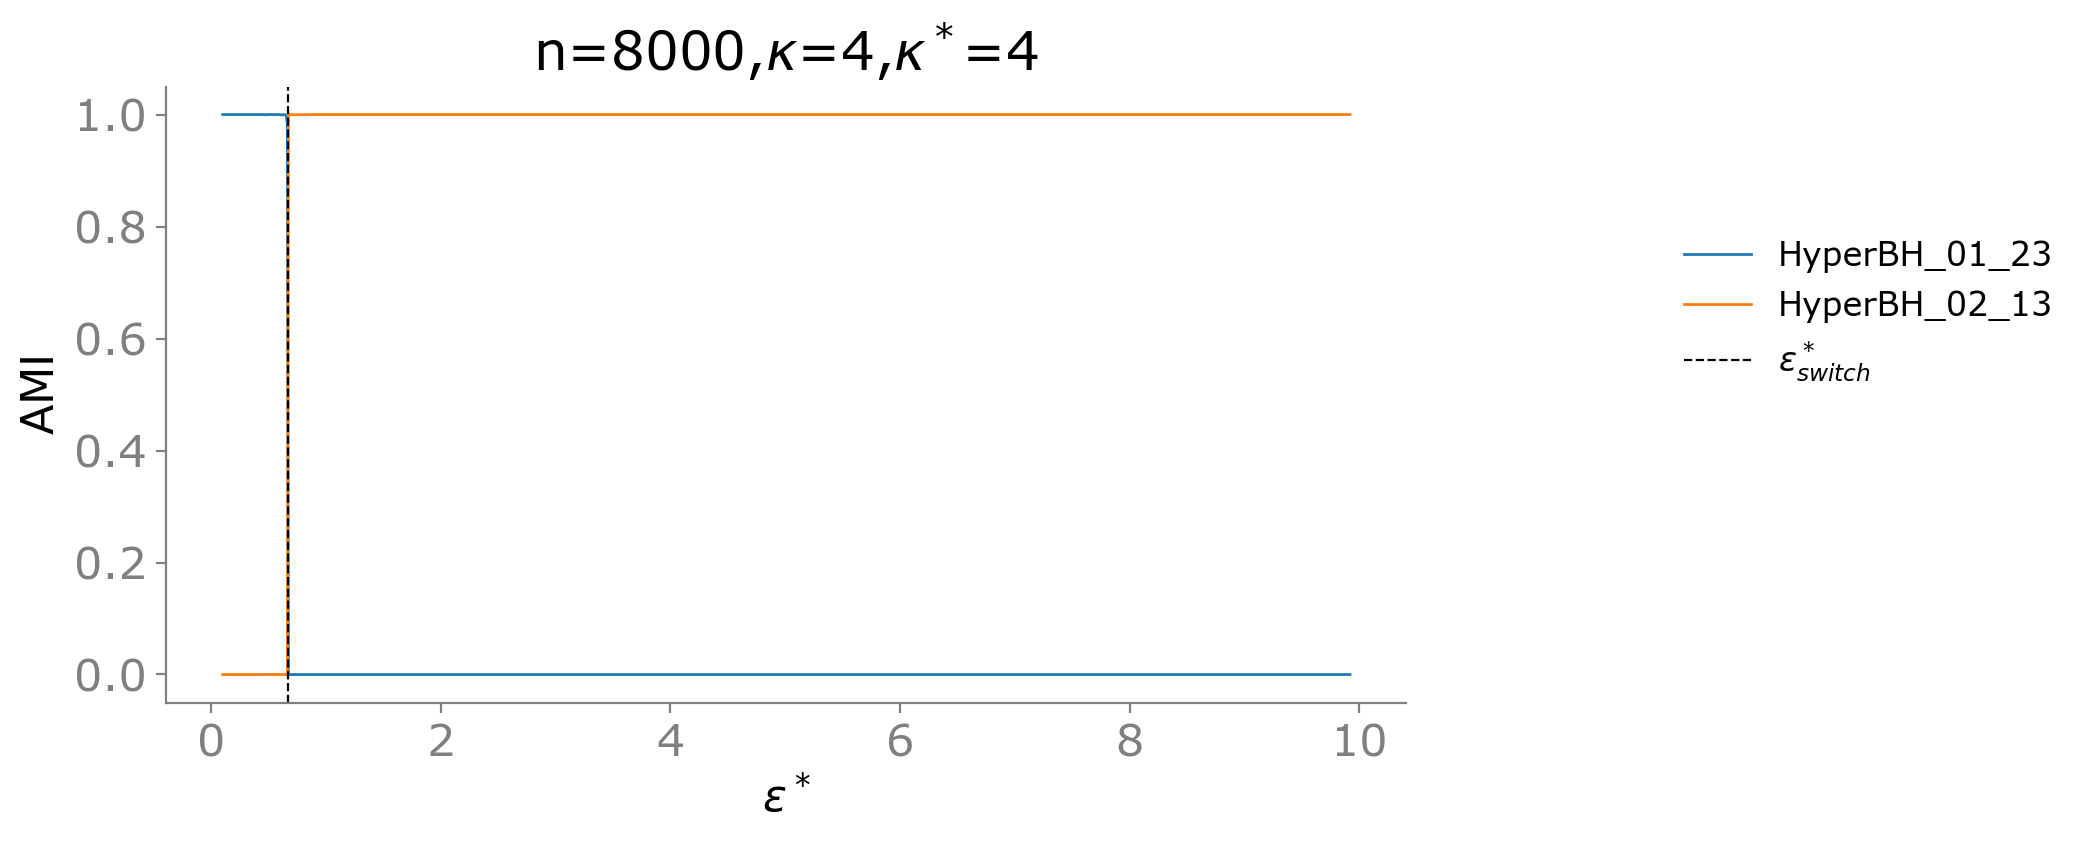

In [50]:
fig = plt.figure(figsize=(8, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

index = np.where(epsilons<10)[0]
ax.plot(epsilons[index], results[index, 1], lw=1, label="HyperBH_01_23")
ax.plot(epsilons[index], results[index, 2], lw=1, label="HyperBH_02_13")
# ax.plot(epsilons[index], results[index, 3], lw=1, label="CliqueProjNetworkBH_01_23")
# ax.plot(epsilons[index], results[index, 4], lw=1, label="CliqueProjNetworkBH_02_13")
ax.axvline(epsilon_star_switch, color='black', lw=0.8, ls='--', label=r'$\epsilon^*_{switch}$')
ax.set_xlabel(r"$\epsilon^*$", fontsize=16)
ax.set_ylabel(r"$\rm AMI$", fontsize=16)
ax.set_title(rf"n={n},$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}")
plt.legend(loc=2, bbox_to_anchor=(1.2, 0.8),  fontsize=12, markerscale=2, frameon=False)

# save_path = f"./_Figure/Hyper/" + f"OrderEffect_8.15_onlyassort.pdf"
# plt.savefig(save_path, dpi=600)

# Affect of Shape of Hyperedges

In [27]:
n = 8000
d = 10
Ks = (4, 4, )
load_path = f"./result/hyperOrderEffect/exp8.27_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}_modify.txt"
epsilons, results = read_exp(load_path=load_path)
# print(np.shape(results))
k = Ks[0]
k_star = Ks[1]
# epsilon_star_switch = get_epsilon_star_switch(k, k_star)
epsilon_star_switch = 4/3
print(epsilon_star_switch)

1.3333333333333333


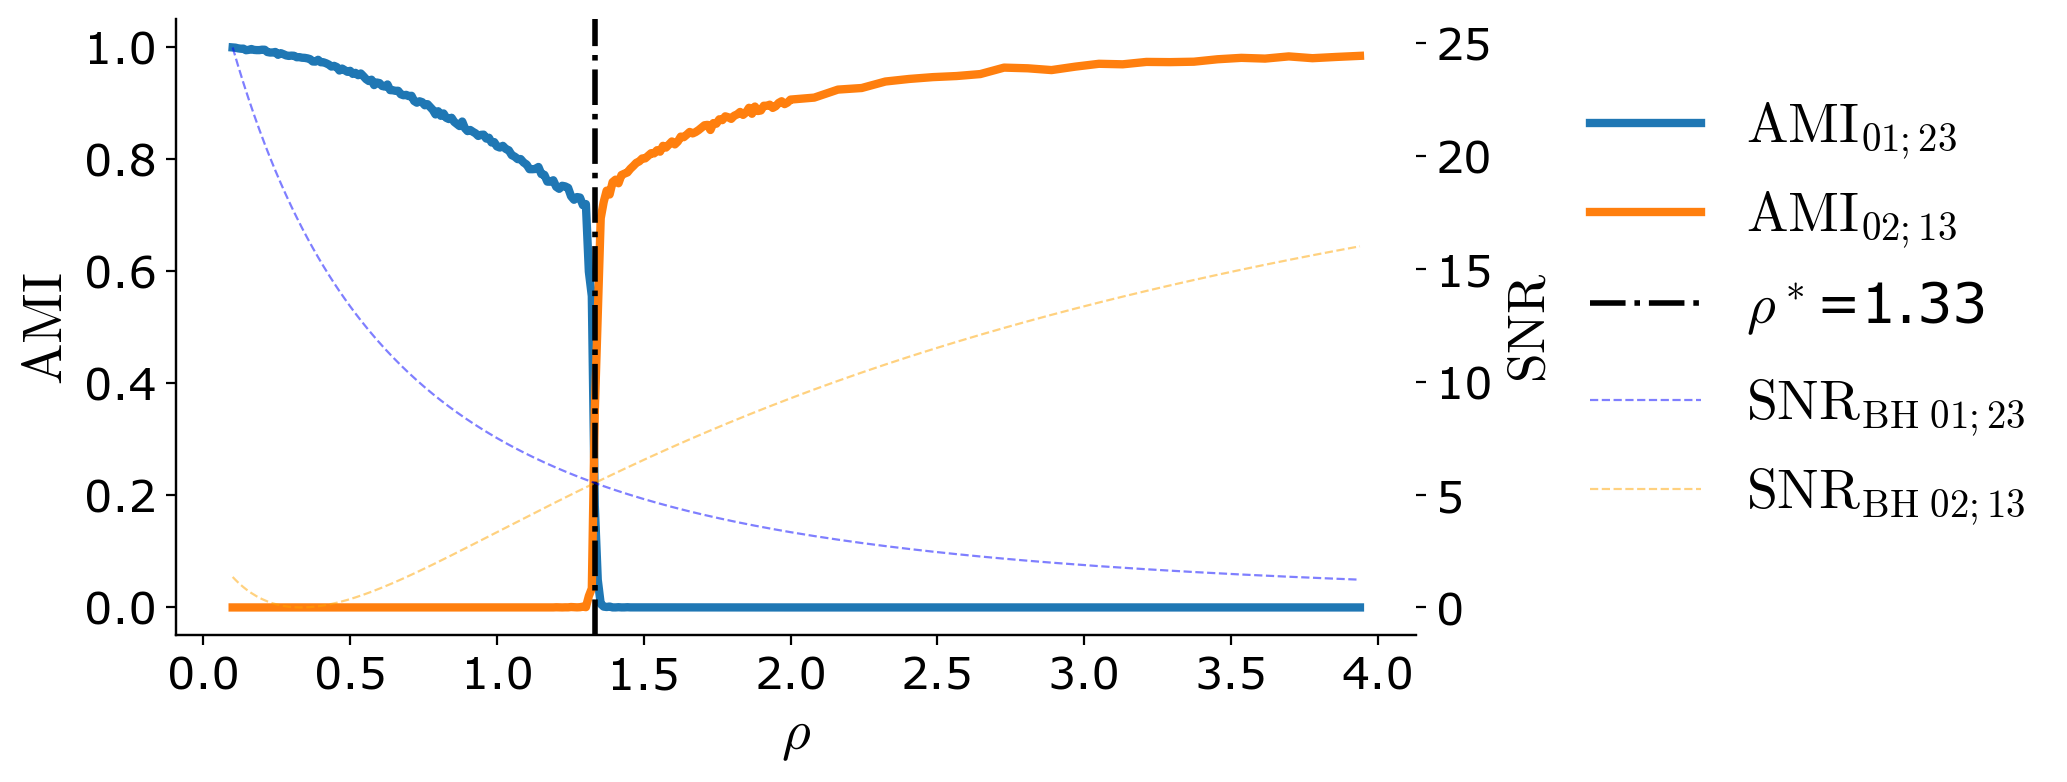

In [28]:
k = Ks[0]
k_star = Ks[1]
d = 10
aoverastar = []
phi_01_23 = []
phi_02_13 = []
for e in epsilons:
    a = 6*4**2*d*e/(e+1)
    astar = 2*4**3*d/(e+1)
    aoverastar.append(a/astar)
    phi_01_23.append((3*astar/64)**2/(12*d))
    phi_02_13.append(((2*a-astar/2)/32)**2/(12*d))
phi_01_23 = np.array(phi_01_23)
phi_02_13 = np.array(phi_02_13)
# print(phi_01_23)
fig = plt.figure(figsize=(8, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

index = np.where(epsilons<4)[0]
ax.plot(epsilons[index], results[index, 1], lw=3, label=r"$\mathrm{AMI}_{01;23}$")
ax.plot(epsilons[index], results[index, 2], lw=3, label=r"$\mathrm{AMI}_{02;13}$")
ax.axvline(epsilon_star_switch, color='black', lw=2, ls='-.', label=r'$\rho^*$'+f"={np.round(epsilon_star_switch, 2)}")
# ax.plot(np.array(aoverastar)[index], results[index, 1], lw=1, label="HyperBH_01_23")
# ax.plot(np.array(aoverastar)[index], results[index, 2], lw=1, label="HyperBH_02_13")
# aoverastar_switch = (2**(k-2)*math.factorial(k-2))/ (2**(k_star-2)*math.factorial(k_star-2))
# ax.axvline(aoverastar_switch, color='black', lw=0.8, ls='--', label=r'$\frac{a}{a^*}_{switch}$'+f"={np.round(epsilon_star_switch, 3)}")
ax.set_xlabel(r"$\rho$", fontsize=20)
ax.set_ylabel(r"$\rm AMI$", fontsize=20)
# ax.set_title(rf"n={n},$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}")
leg1 = plt.legend(loc=2, bbox_to_anchor=(1.1, 0.95),  fontsize=20, markerscale=2, frameon=False)

ax_twin = ax.twinx()
# ax_twin.plot(epsilons[index], np.array(phi_01_23)[index], lw=1, ls='--', color="blue", label=r"$\phi_{\kappa^*}$", alpha=0.5)
# ax_twin.plot(epsilons[index], np.array(phi_02_13)[index], lw=1, ls='--', color="orange", label=r"$\phi_{\kappa}$", alpha=0.5)
# # ax_twin.plot(np.array(aoverastar)[index], np.array(phi_01_23)[index], lw=1, ls='--', color="blue", label="phi_01_23")
# # ax_twin.plot(np.array(aoverastar)[index], np.array(phi_02_13)[index], lw=1, ls='--', color="orange", label="phi_02_13")
ax_twin.plot(epsilons[index], phi_01_23[index], lw=0.8, ls='--', color="blue", label=r"${\mathrm{SNR}_{\rm{BH}\ 01;23}}$", alpha=0.5)
ax_twin.plot(epsilons[index], phi_02_13[index], lw=0.8, ls='--', color="orange", label=r"${\mathrm{SNR}_{\rm{BH}\ 02;13}}$", alpha=0.5)
ax_twin.set_ylabel(r'$\mathrm{SNR}$')
# ax_twin.axhline(1, color='black', lw=0.8, ls=':')
leg2 = plt.legend(loc=2, bbox_to_anchor=(1.1, 0.5),  fontsize=20, markerscale=2, frameon=False)

# save_path = f"./_Figure/Hyper/OrderEffect/" + f"Figure_Appendix_n={n}_k={k}_kstar={k_star}_shapediff_v1.pdf"
save_path = f"./_Figure/Hyper/OrderEffect/" + f"Figure_Appendix_n={n}_k={k}_kstar={k_star}_shapediff_v2.pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_inches='tight', bbox_extra_artists=(leg1, leg2))

In [18]:
n = 8000
d = 10
Ks = (5, 5, )
load_path = f"./result/hyperOrderEffect/exp11.3_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}_diffshape.txt"
epsilons, results = read_exp(load_path=load_path)
# print(np.shape(results))
k = Ks[0]
k_star = Ks[1]
# epsilon_star_switch = get_epsilon_star_switch(k, k_star)
epsilon_star_switch = 3/2
print(epsilon_star_switch)

1.5


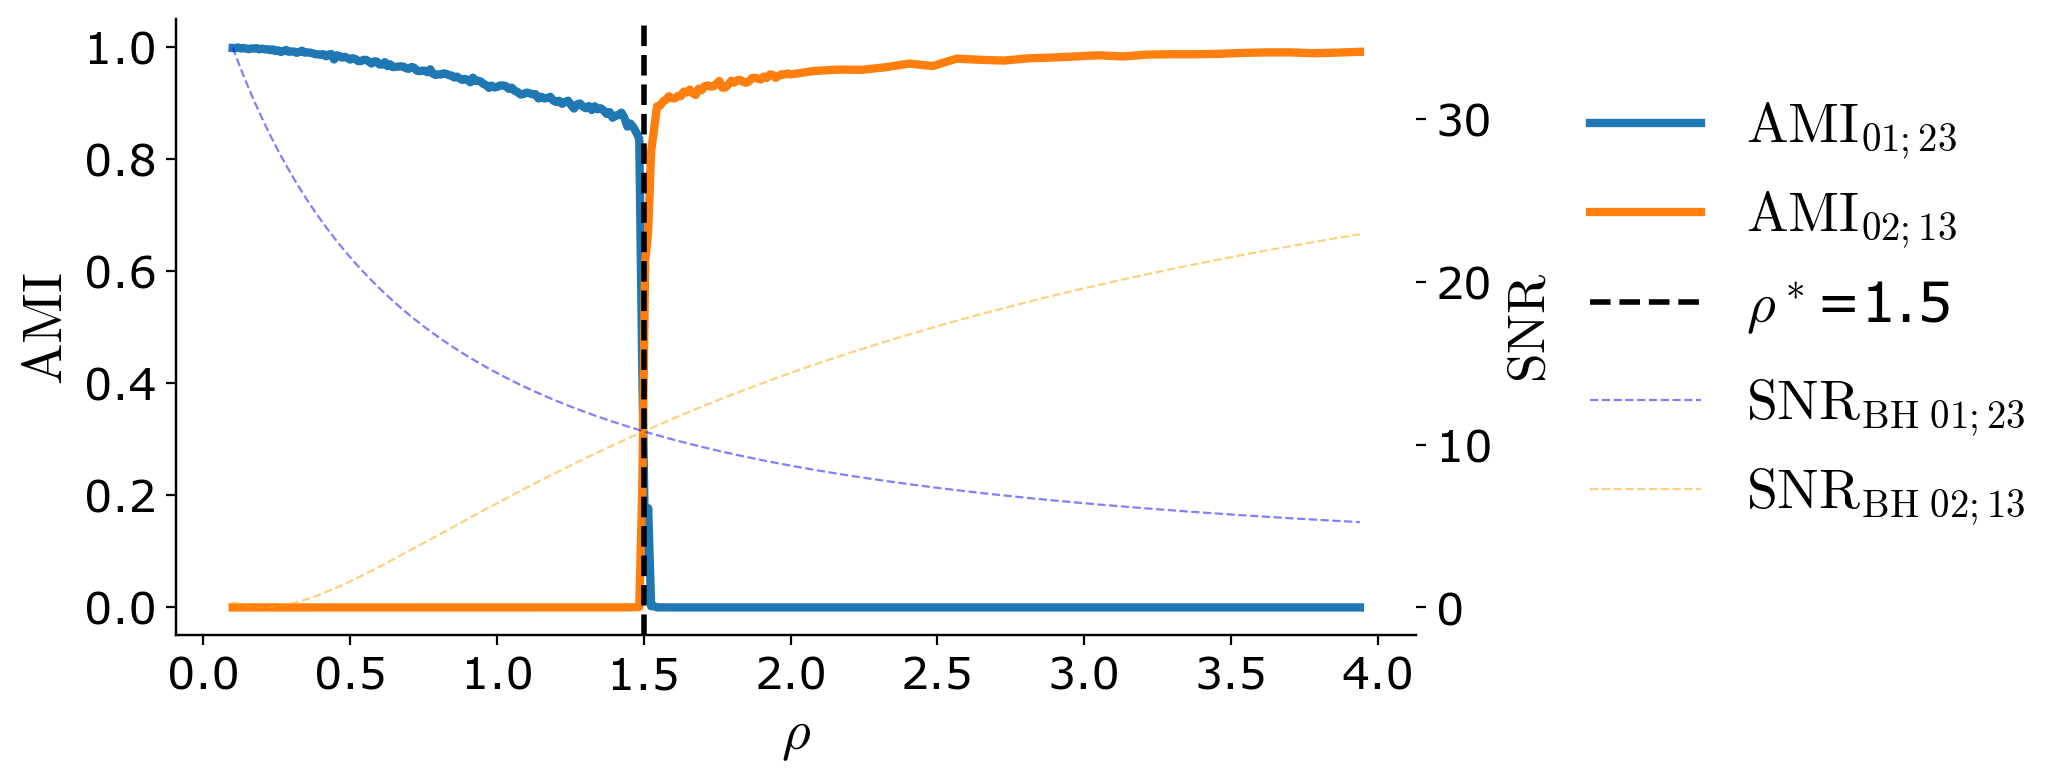

In [25]:
k = Ks[0]
k_star = Ks[1]
d = 10
aoverastar = []
phi_01_23 = []
phi_02_13 = []
for e in epsilons:
    a = 24*4**4*d*e/(5*(e+1))
    astar = 12*4**4*d/(5*(e+1))
    aoverastar.append(a/astar)
    phi_01_23.append(((5*astar+a/2)/(64*6))**2/(16*d))
    phi_02_13.append(((2.5*a-astar)/(64*6))**2/(16*d))
# print(phi_01_23)
phi_01_23 = np.array(phi_01_23)
phi_02_13 = np.array(phi_02_13)
fig = plt.figure(figsize=(8, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

index = np.where(epsilons<4)[0]
ax.plot(epsilons[index], results[index, 1], lw=3, label=r"$\mathrm{AMI}_{01;23}$")
ax.plot(epsilons[index], results[index, 2], lw=3, label=r"$\mathrm{AMI}_{02;13}$")
ax.axvline(epsilon_star_switch, color='black', lw=2, ls='--', label=r'$\rho^*$'+f"={np.round(epsilon_star_switch, 3)}")
# ax.plot(np.array(aoverastar)[index], results[index, 1], lw=1, label="HyperBH_01_23")
# ax.plot(np.array(aoverastar)[index], results[index, 2], lw=1, label="HyperBH_02_13")
# aoverastar_switch = (2**(k-2)*math.factorial(k-2))/ (2**(k_star-2)*math.factorial(k_star-2))
# ax.axvline(aoverastar_switch, color='black', lw=0.8, ls='--', label=r'$\frac{a}{a^*}_{switch}$'+f"={np.round(epsilon_star_switch, 3)}")
ax.set_xlabel(r"$\rho$", fontsize=20)
ax.set_ylabel(r"$\rm AMI$", fontsize=20)
# ax.set_title(rf"n={n},$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}")
leg1 = plt.legend(loc=2, bbox_to_anchor=(1.1, 0.95),  fontsize=20, markerscale=2, frameon=False)

ax_twin = ax.twinx()
# ax_twin.plot(epsilons[index], np.array(phi_01_23)[index], lw=1, ls='--', color="blue", label=r"$\phi_{\kappa^*}$", alpha=0.5)
# ax_twin.plot(epsilons[index], np.array(phi_02_13)[index], lw=1, ls='--', color="orange", label=r"$\phi_{\kappa}$", alpha=0.5)
# # ax_twin.plot(np.array(aoverastar)[index], np.array(phi_01_23)[index], lw=1, ls='--', color="blue", label="phi_01_23")
# # ax_twin.plot(np.array(aoverastar)[index], np.array(phi_02_13)[index], lw=1, ls='--', color="orange", label="phi_02_13")
ax_twin.plot(epsilons[index], phi_01_23[index], lw=0.8, ls='--', color="blue", label=r"${\mathrm{SNR}_{\rm{BH}\ 01;23}}$", alpha=0.5)
ax_twin.plot(epsilons[index], phi_02_13[index], lw=0.8, ls='--', color="orange", label=r"${\mathrm{SNR}_{\rm{BH}\ 02;13}}$", alpha=0.5)
ax_twin.set_ylabel(r'$\mathrm{SNR}$')
# ax_twin.axhline(1, color='black', lw=0.8, ls=':')
leg2 = plt.legend(loc=2, bbox_to_anchor=(1.1, 0.5),  fontsize=20, markerscale=2, frameon=False)

save_path = f"./_Figure/Hyper/OrderEffect/" + f"Figure_Appendix_n={n}_k={k}_kstar={k_star}_shapediff_v1.pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_inches='tight', bbox_extra_artists=(leg1, leg2))

# Test

In [7]:
n = 10000
k = 2
k_star = 5
epsilon_star = get_epsilon_star_switch(k, k_star)
print(epsilon_star)

5.333333333333333


In [10]:
n = 1000000
a = 2**(k-2)*math.factorial(k-2)
a_star = 2**(k_star-2)*math.factorial(k_star-2)
(math.comb(int(2*n/4), k) - 2*math.comb(int(n/4), k)) / (math.comb(int(2*n/4), k_star) - 2*math.comb(int(n/4), k_star)) * (n**(k_star-k)) * (a/a_star)

5.33343289014994

In [6]:
def get_a_over_astar(epsilon_star, k, k_star, d):
    q = 4
    a = q**k*math.factorial(k)*d*epsilon_star / (2*(2**k-2)*(k*epsilon_star + k_star))
    a_star = q**k_star*math.factorial(k_star)*d / (2*(2**k_star-2)*(k*epsilon_star + k_star))
    return a, a_star

In [7]:
def get_phi(a, a_star, k, k_star, community_conf="01_23"):
    c_k = (a*(2**(k-1)-1))/(4**(k-1)*math.factorial(k-1))
    c_kstar = (a_star*(2**(k_star-1)-1))/(4**(k_star-1)*math.factorial(k_star-1))
    denominator = 4*((k-1)*c_k+(k_star-1)*c_kstar)
    if community_conf == "01_23":
        phi = ((a_star*(2**(k_star-2)-1/2))/(4**(k_star-2)*math.factorial(k_star-2))-(a/2)/(4**(k-2)*math.factorial(k-2)))**2 / denominator
    elif community_conf == "02_13":
        phi = ((a*(2**(k-2)-1/2))/(4**(k-2)*math.factorial(k-2))-(a_star/2)/(4**(k_star-2)*math.factorial(k_star-2)))**2 / denominator
    return phi

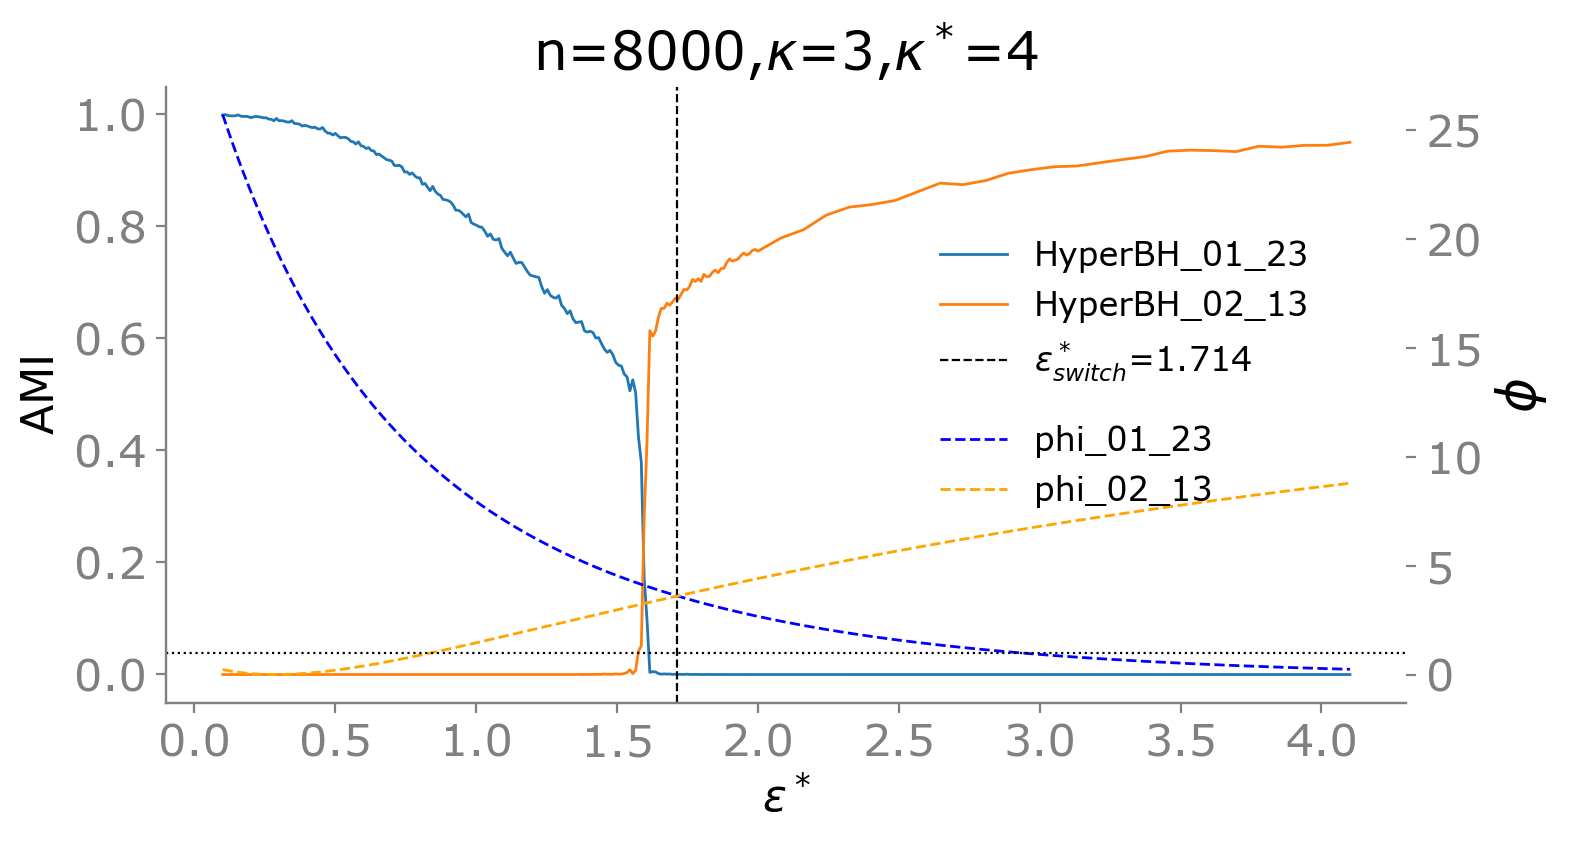

In [15]:
k = Ks[0]
k_star = Ks[1]
d = 10
aoverastar = []
phi_01_23 = []
phi_02_13 = []
for e in epsilons:
    a, astar = get_a_over_astar(e, k, k_star, d)
    aoverastar.append(a/astar)
    phi_01_23.append(get_phi(a, astar, k, k_star, community_conf="01_23"))
    phi_02_13.append(get_phi(a, astar, k, k_star, community_conf="02_13"))
# print(phi_01_23)
fig = plt.figure(figsize=(8, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

index = np.where(epsilons<10)[0]
ax.plot(epsilons[index], results[index, 1], lw=1, label="HyperBH_01_23")
ax.plot(epsilons[index], results[index, 2], lw=1, label="HyperBH_02_13")
ax.axvline(epsilon_star_switch, color='black', lw=0.8, ls='--', label=r'$\epsilon^*_{switch}$'+f"={np.round(epsilon_star_switch, 3)}")
# ax.plot(np.array(aoverastar)[index], results[index, 1], lw=1, label="HyperBH_01_23")
# ax.plot(np.array(aoverastar)[index], results[index, 2], lw=1, label="HyperBH_02_13")
# aoverastar_switch = (2**(k-2)*math.factorial(k-2))/ (2**(k_star-2)*math.factorial(k_star-2))
# ax.axvline(aoverastar_switch, color='black', lw=0.8, ls='--', label=r'$\frac{a}{a^*}_{switch}$'+f"={np.round(epsilon_star_switch, 3)}")
ax.set_xlabel(r"$\epsilon^*$", fontsize=16)
ax.set_ylabel(r"$\rm AMI$", fontsize=16)
ax.set_title(rf"n={n},$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}")
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.8),  fontsize=12, markerscale=2, frameon=False)

ax_twin = ax.twinx()
ax_twin.plot(epsilons[index], np.array(phi_01_23)[index], lw=1, ls='--', color="blue", label="phi_01_23")
ax_twin.plot(epsilons[index], np.array(phi_02_13)[index], lw=1, ls='--', color="orange", label="phi_02_13")
# ax_twin.plot(np.array(aoverastar)[index], np.array(phi_01_23)[index], lw=1, ls='--', color="blue", label="phi_01_23")
# ax_twin.plot(np.array(aoverastar)[index], np.array(phi_02_13)[index], lw=1, ls='--', color="orange", label="phi_02_13")
ax_twin.set_ylabel(r'$\phi$')
ax_twin.axhline(1, color='black', lw=0.8, ls=':')
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.5),  fontsize=12, markerscale=2, frameon=False)

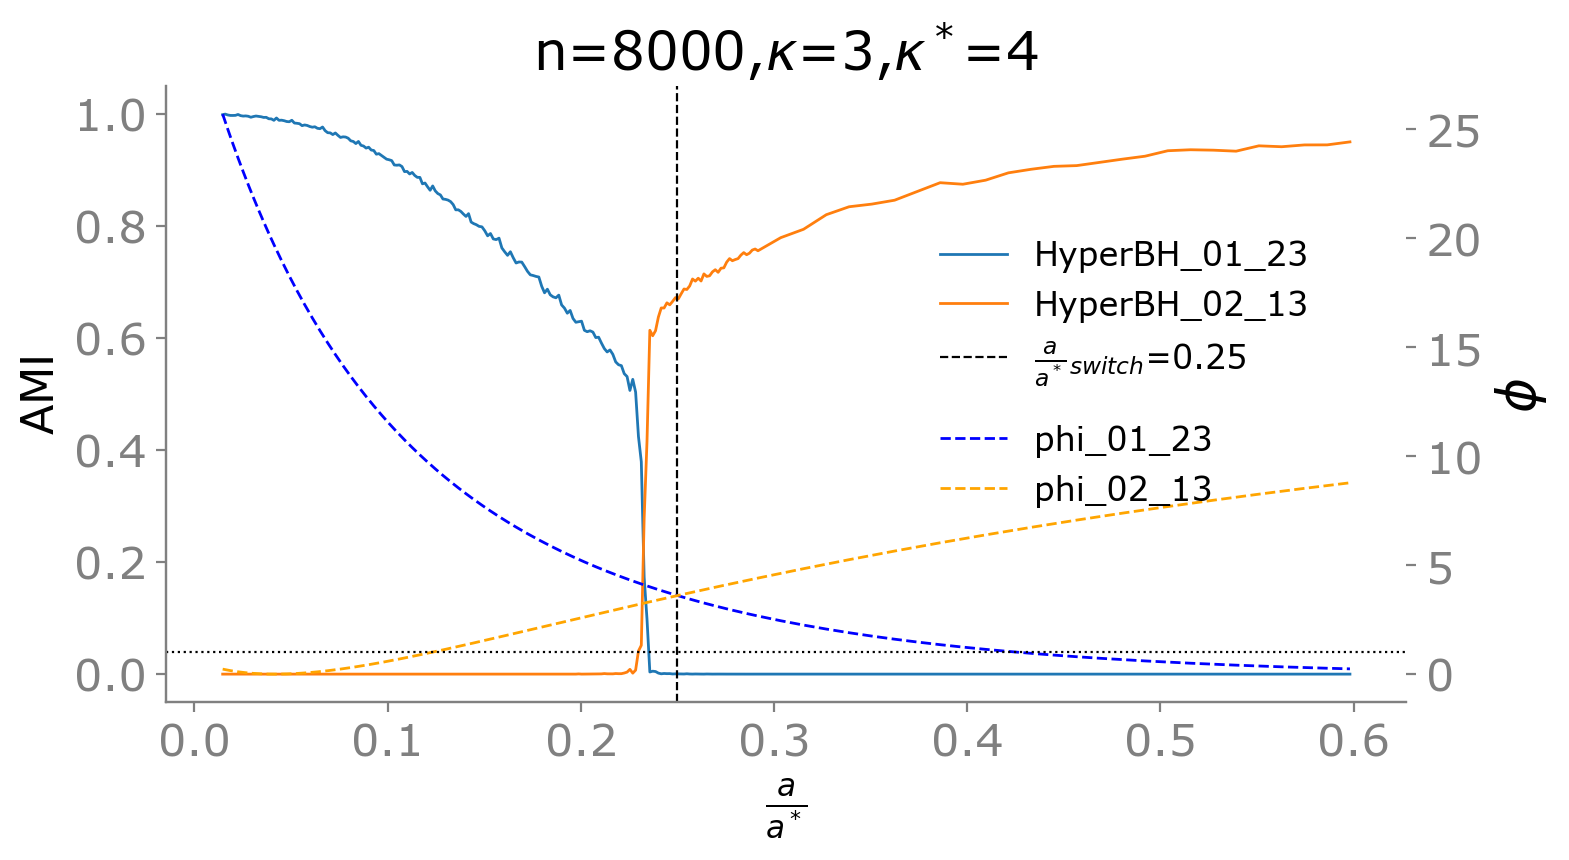

In [131]:
fig = plt.figure(figsize=(8, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

index = np.where(epsilons<10)[0]
# ax.plot(epsilons[index], results[index, 1], lw=1, label="HyperBH_01_23")
# ax.plot(epsilons[index], results[index, 2], lw=1, label="HyperBH_02_13")
# ax.axvline(epsilon_star_switch, color='black', lw=0.8, ls='--', label=r'$\epsilon^*_{switch}$'+f"={np.round(epsilon_star_switch, 3)}")
ax.plot(np.array(aoverastar)[index], results[index, 1], lw=1, label="HyperBH_01_23")
ax.plot(np.array(aoverastar)[index], results[index, 2], lw=1, label="HyperBH_02_13")
aoverastar_switch = (2**(k-2)*math.factorial(k-2))/ (2**(k_star-2)*math.factorial(k_star-2))
# aoverastar_switch = (2**(k-2)*math.factorial(k-1))/ (2**(k_star-2)*math.factorial(k_star-1))  # Test (the case without k-1 in phi), failed
ax.axvline(aoverastar_switch, color='black', lw=0.8, ls='--', label=r'$\frac{a}{a^*}_{switch}$'+f"={np.round(aoverastar_switch, 3)}")
ax.set_xlabel(r"$\frac{a}{a^*}$", fontsize=16)
ax.set_ylabel(r"$\rm AMI$", fontsize=16)
ax.set_title(rf"n={n},$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}")
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.8),  fontsize=12, markerscale=2, frameon=False)

ax_twin = ax.twinx()
# ax_twin.plot(epsilons[index], np.array(phi_01_23)[index], lw=1, ls='--', color="blue", label="phi_01_23")
# ax_twin.plot(epsilons[index], np.array(phi_02_13)[index], lw=1, ls='--', color="orange", label="phi_02_13")
ax_twin.plot(np.array(aoverastar)[index], np.array(phi_01_23)[index], lw=1, ls='--', color="blue", label="phi_01_23")
ax_twin.plot(np.array(aoverastar)[index], np.array(phi_02_13)[index], lw=1, ls='--', color="orange", label="phi_02_13")
ax_twin.set_ylabel(r'$\phi$')
ax_twin.axhline(1, color='black', lw=0.8, ls=':')
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.5),  fontsize=12, markerscale=2, frameon=False)

In [104]:
n = 30000
d = 10
Ks = (3, 4, )
load_path = f"./result/hyperOrderEffect/exp8.26_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}.txt"
epsilons, results = read_exp(load_path=load_path)
# print(np.shape(results))
k = Ks[0]
k_star = Ks[1]
epsilon_star_switch = get_epsilon_star_switch(k, k_star)
print(epsilon_star_switch)

1.7142857142857142


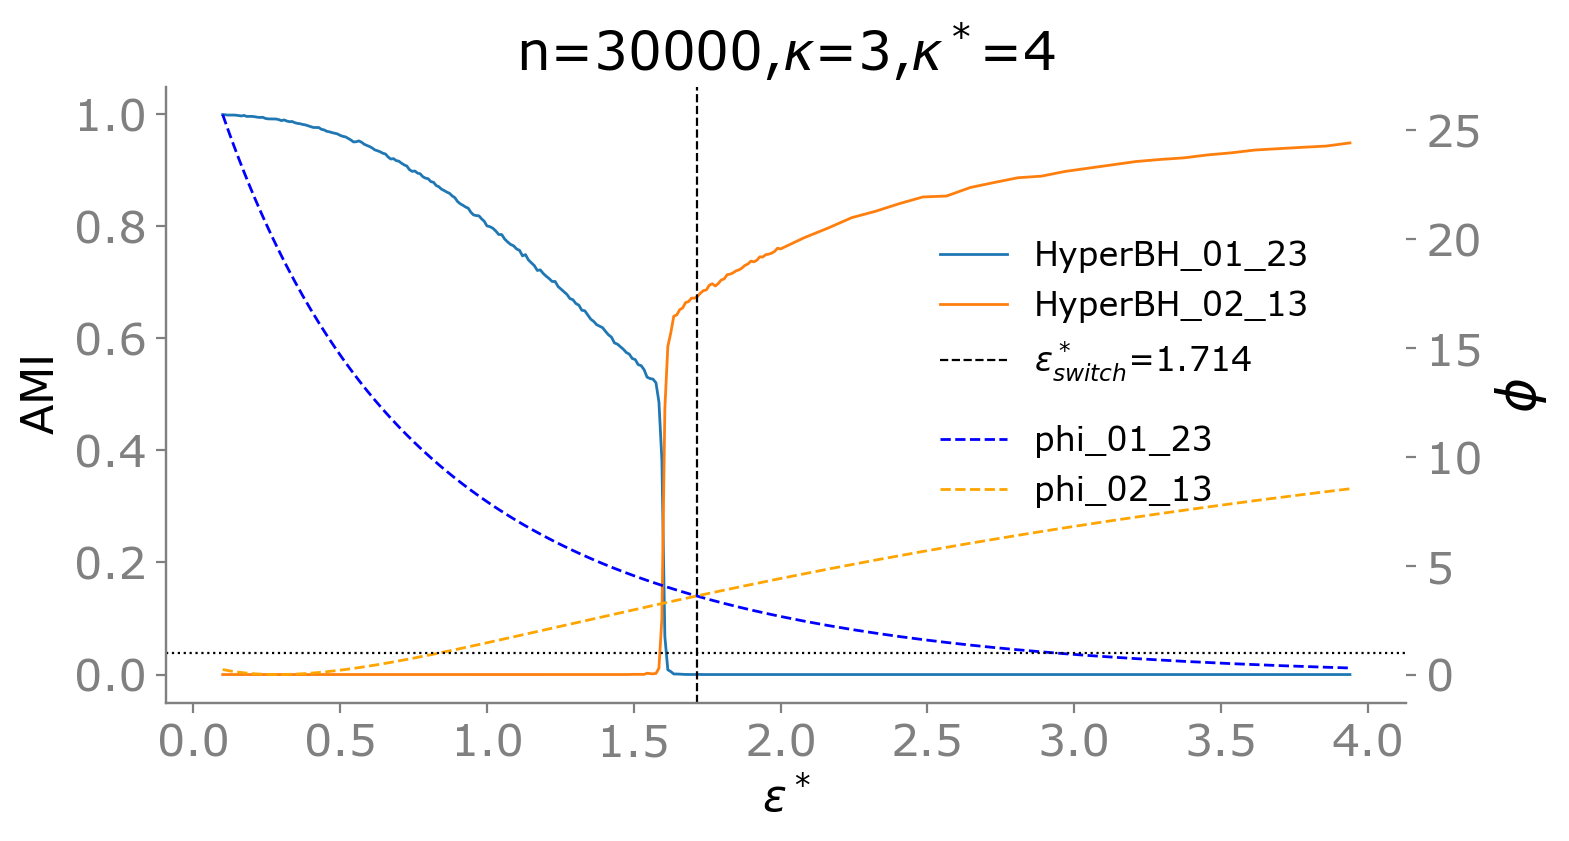

In [105]:
k = Ks[0]
k_star = Ks[1]
d = 10
aoverastar = []
phi_01_23 = []
phi_02_13 = []
for e in epsilons:
    a, astar = get_a_over_astar(e, k, k_star, d)
    aoverastar.append(a/astar)
    phi_01_23.append(get_phi(a, astar, k, k_star, community_conf="01_23"))
    phi_02_13.append(get_phi(a, astar, k, k_star, community_conf="02_13"))
# print(phi_01_23)
fig = plt.figure(figsize=(8, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

index = np.where(epsilons<4)[0]
ax.plot(epsilons[index], results[index, 1], lw=1, label="HyperBH_01_23")
ax.plot(epsilons[index], results[index, 2], lw=1, label="HyperBH_02_13")
ax.axvline(epsilon_star_switch, color='black', lw=0.8, ls='--', label=r'$\epsilon^*_{switch}$'+f"={np.round(epsilon_star_switch, 3)}")
# ax.plot(np.array(aoverastar)[index], results[index, 1], lw=1, label="HyperBH_01_23")
# ax.plot(np.array(aoverastar)[index], results[index, 2], lw=1, label="HyperBH_02_13")
# aoverastar_switch = (2**(k-2)*math.factorial(k-2))/ (2**(k_star-2)*math.factorial(k_star-2))
# ax.axvline(aoverastar_switch, color='black', lw=0.8, ls='--', label=r'$\frac{a}{a^*}_{switch}$'+f"={np.round(epsilon_star_switch, 3)}")
ax.set_xlabel(r"$\epsilon^*$", fontsize=16)
ax.set_ylabel(r"$\rm AMI$", fontsize=16)
ax.set_title(rf"n={n},$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}")
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.8),  fontsize=12, markerscale=2, frameon=False)

ax_twin = ax.twinx()
ax_twin.plot(epsilons[index], np.array(phi_01_23)[index], lw=1, ls='--', color="blue", label="phi_01_23")
ax_twin.plot(epsilons[index], np.array(phi_02_13)[index], lw=1, ls='--', color="orange", label="phi_02_13")
# ax_twin.plot(np.array(aoverastar)[index], np.array(phi_01_23)[index], lw=1, ls='--', color="blue", label="phi_01_23")
# ax_twin.plot(np.array(aoverastar)[index], np.array(phi_02_13)[index], lw=1, ls='--', color="orange", label="phi_02_13")
ax_twin.set_ylabel(r'$\phi$')
ax_twin.axhline(1, color='black', lw=0.8, ls=':')
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.5),  fontsize=12, markerscale=2, frameon=False)

In [76]:
n = 8000
d = 10
Ks = (4, 5, )
load_path = f"./result/hyperOrderEffect/exp10.12_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}.txt"
epsilons, results = read_exp(load_path=load_path)
# print(np.shape(results))
k = Ks[0]
k_star = Ks[1]
epsilon_star_switch = get_epsilon_star_switch(k, k_star)
print(epsilon_star_switch)

1.5555555555555556


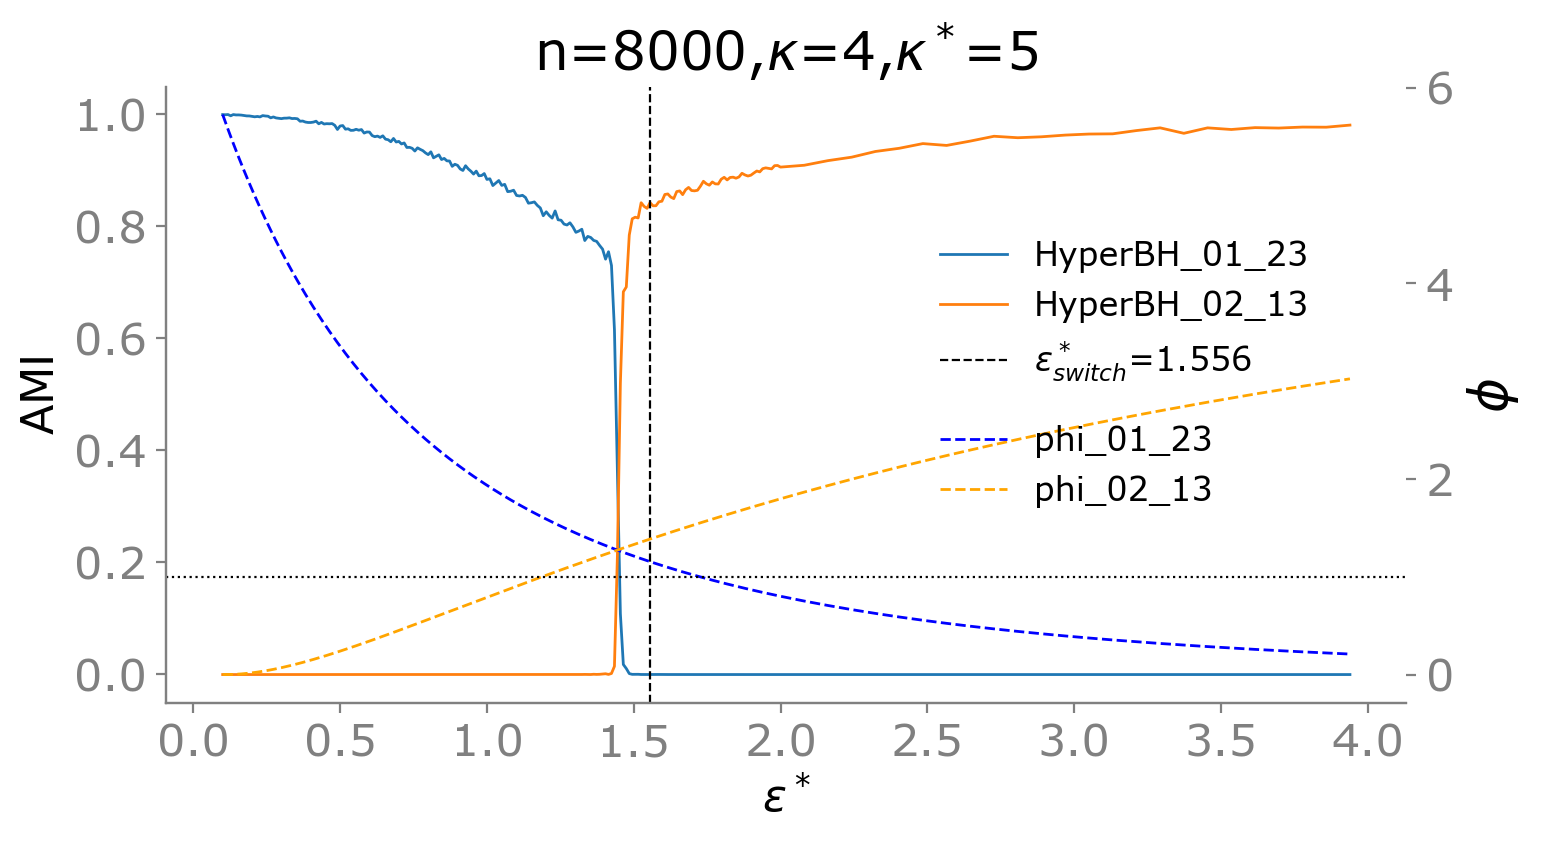

In [78]:
k = Ks[0]
k_star = Ks[1]
d = 10
aoverastar = []
phi_01_23 = []
phi_02_13 = []
for e in epsilons:
    a, astar = get_a_over_astar(e, k, k_star, d)
    aoverastar.append(a/astar)
    phi_01_23.append(get_phi(a, astar, k, k_star, community_conf="01_23"))
    phi_02_13.append(get_phi(a, astar, k, k_star, community_conf="02_13"))
# print(phi_01_23)
fig = plt.figure(figsize=(8, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

index = np.where(epsilons<4)[0]
ax.plot(epsilons[index], results[index, 1], lw=1, label="HyperBH_01_23")
ax.plot(epsilons[index], results[index, 2], lw=1, label="HyperBH_02_13")
ax.axvline(epsilon_star_switch, color='black', lw=0.8, ls='--', label=r'$\epsilon^*_{switch}$'+f"={np.round(epsilon_star_switch, 3)}")
# ax.plot(np.array(aoverastar)[index], results[index, 1], lw=1, label="HyperBH_01_23")
# ax.plot(np.array(aoverastar)[index], results[index, 2], lw=1, label="HyperBH_02_13")
# aoverastar_switch = (2**(k-2)*math.factorial(k-2))/ (2**(k_star-2)*math.factorial(k_star-2))
# ax.axvline(aoverastar_switch, color='black', lw=0.8, ls='--', label=r'$\frac{a}{a^*}_{switch}$'+f"={np.round(epsilon_star_switch, 3)}")
ax.set_xlabel(r"$\epsilon^*$", fontsize=16)
ax.set_ylabel(r"$\rm AMI$", fontsize=16)
ax.set_title(rf"n={n},$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}")
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.8),  fontsize=12, markerscale=2, frameon=False)

ax_twin = ax.twinx()
ax_twin.plot(epsilons[index], np.array(phi_01_23)[index]/(k_star+1), lw=1, ls='--', color="blue", label="phi_01_23")
ax_twin.plot(epsilons[index], np.array(phi_02_13)[index]/(k+1), lw=1, ls='--', color="orange", label="phi_02_13")
# ax_twin.plot(np.array(aoverastar)[index], np.array(phi_01_23)[index], lw=1, ls='--', color="blue", label="phi_01_23")
# ax_twin.plot(np.array(aoverastar)[index], np.array(phi_02_13)[index], lw=1, ls='--', color="orange", label="phi_02_13")
ax_twin.set_ylabel(r'$\phi$')
ax_twin.axhline(1, color='black', lw=0.8, ls=':')
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.5),  fontsize=12, markerscale=2, frameon=False)

In [100]:
n = 8000
d = 10
Ks = (3, 8, )
load_path = f"./result/hyperOrderEffect/exp10.12_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}.txt"
epsilons, results = read_exp(load_path=load_path)
# print(np.shape(results))
k = Ks[0]
k_star = Ks[1]
epsilon_star_switch = get_epsilon_star_switch(k, k_star)
print(epsilon_star_switch)

7.055118110236221


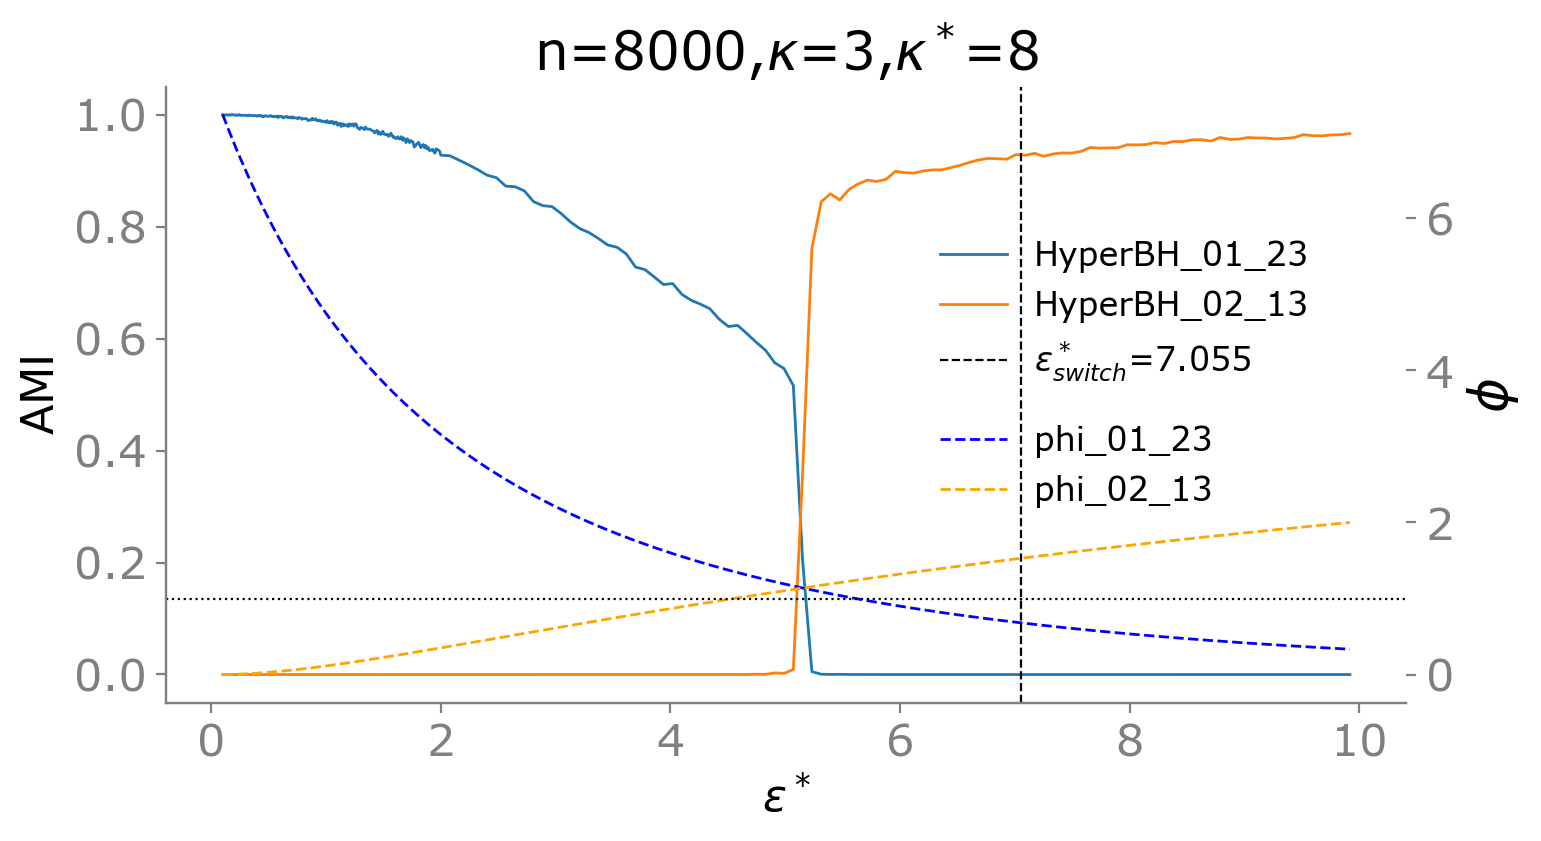

In [102]:
k = Ks[0]
k_star = Ks[1]
d = 10
aoverastar = []
phi_01_23 = []
phi_02_13 = []
for e in epsilons:
    a, astar = get_a_over_astar(e, k, k_star, d)
    aoverastar.append(a/astar)
    phi_01_23.append(get_phi(a, astar, k, k_star, community_conf="01_23"))
    phi_02_13.append(get_phi(a, astar, k, k_star, community_conf="02_13"))
# print(phi_01_23)
fig = plt.figure(figsize=(8, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

index = np.where(epsilons<10)[0]
ax.plot(epsilons[index], results[index, 1], lw=1, label="HyperBH_01_23")
ax.plot(epsilons[index], results[index, 2], lw=1, label="HyperBH_02_13")
ax.axvline(epsilon_star_switch, color='black', lw=0.8, ls='--', label=r'$\epsilon^*_{switch}$'+f"={np.round(epsilon_star_switch, 3)}")
# ax.plot(np.array(aoverastar)[index], results[index, 1], lw=1, label="HyperBH_01_23")
# ax.plot(np.array(aoverastar)[index], results[index, 2], lw=1, label="HyperBH_02_13")
# aoverastar_switch = (2**(k-2)*math.factorial(k-2))/ (2**(k_star-2)*math.factorial(k_star-2))
# ax.axvline(aoverastar_switch, color='black', lw=0.8, ls='--', label=r'$\frac{a}{a^*}_{switch}$'+f"={np.round(epsilon_star_switch, 3)}")
ax.set_xlabel(r"$\epsilon^*$", fontsize=16)
ax.set_ylabel(r"$\rm AMI$", fontsize=16)
ax.set_title(rf"n={n},$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}")
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.8),  fontsize=12, markerscale=2, frameon=False)

ax_twin = ax.twinx()
ax_twin.plot(epsilons[index], np.array(phi_01_23)[index]/(k_star+1), lw=1, ls='--', color="blue", label="phi_01_23")
ax_twin.plot(epsilons[index], np.array(phi_02_13)[index]/(k+1), lw=1, ls='--', color="orange", label="phi_02_13")
# ax_twin.plot(np.array(aoverastar)[index], np.array(phi_01_23)[index], lw=1, ls='--', color="blue", label="phi_01_23")
# ax_twin.plot(np.array(aoverastar)[index], np.array(phi_02_13)[index], lw=1, ls='--', color="orange", label="phi_02_13")
ax_twin.set_ylabel(r'$\phi$')
ax_twin.axhline(1, color='black', lw=0.8, ls=':')
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.5),  fontsize=12, markerscale=2, frameon=False)

In [109]:
n = 8000
d = 10
Ks = (4, 4, )
load_path = f"./result/hyperOrderEffect/exp10.12_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}.txt"
epsilons, results = read_exp(load_path=load_path)
# print(np.shape(results))
k = Ks[0]
k_star = Ks[1]
epsilon_star_switch = get_epsilon_star_switch(k, k_star)
print(epsilon_star_switch)

1.0


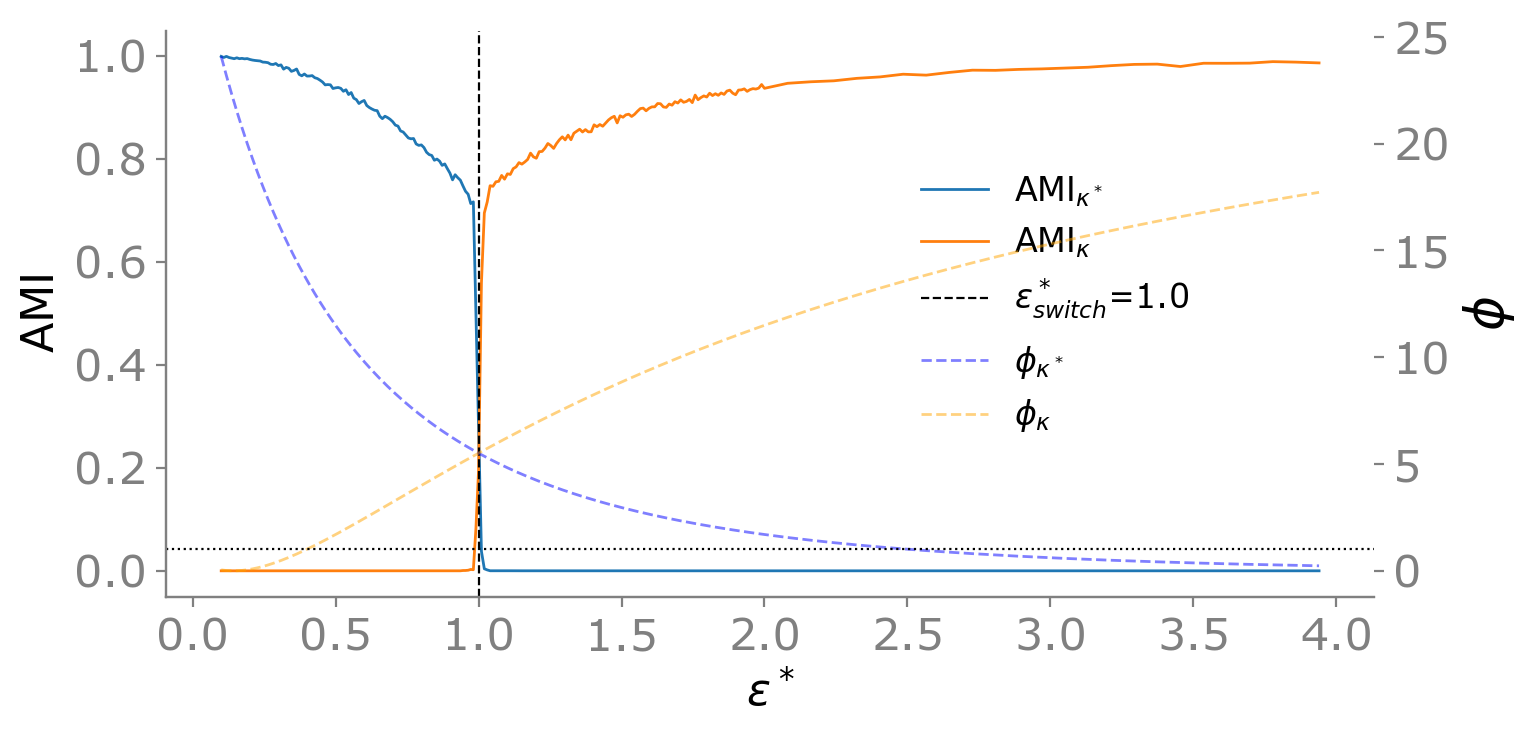

In [112]:
k = Ks[0]
k_star = Ks[1]
d = 10
aoverastar = []
phi_01_23 = []
phi_02_13 = []
for e in epsilons:
    a, astar = get_a_over_astar(e, k, k_star, d)
    aoverastar.append(a/astar)
    phi_01_23.append(get_phi(a, astar, k, k_star, community_conf="01_23"))
    phi_02_13.append(get_phi(a, astar, k, k_star, community_conf="02_13"))
# print(phi_01_23)
fig = plt.figure(figsize=(8, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

index = np.where(epsilons<4)[0]
ax.plot(epsilons[index], results[index, 1], lw=1, label=r"$\mathrm{AMI}_{\kappa^*}$")
ax.plot(epsilons[index], results[index, 2], lw=1, label=r"$\mathrm{AMI}_{\kappa}$")
ax.axvline(epsilon_star_switch, color='black', lw=0.8, ls='--', label=r'$\epsilon^*_{switch}$'+f"={np.round(epsilon_star_switch, 3)}")
# ax.plot(np.array(aoverastar)[index], results[index, 1], lw=1, label="HyperBH_01_23")
# ax.plot(np.array(aoverastar)[index], results[index, 2], lw=1, label="HyperBH_02_13")
# aoverastar_switch = (2**(k-2)*math.factorial(k-2))/ (2**(k_star-2)*math.factorial(k_star-2))
# ax.axvline(aoverastar_switch, color='black', lw=0.8, ls='--', label=r'$\frac{a}{a^*}_{switch}$'+f"={np.round(epsilon_star_switch, 3)}")
ax.set_xlabel(r"$\epsilon^*$", fontsize=16)
ax.set_ylabel(r"$\rm AMI$", fontsize=16)
# ax.set_title(rf"n={n},$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}")
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.8),  fontsize=12, markerscale=2, frameon=False)

ax_twin = ax.twinx()
ax_twin.plot(epsilons[index], np.array(phi_01_23)[index], lw=1, ls='--', color="blue", label=r"$\phi_{\kappa^*}$", alpha=0.5)
ax_twin.plot(epsilons[index], np.array(phi_02_13)[index], lw=1, ls='--', color="orange", label=r"$\phi_{\kappa}$", alpha=0.5)
# ax_twin.plot(np.array(aoverastar)[index], np.array(phi_01_23)[index], lw=1, ls='--', color="blue", label="phi_01_23")
# ax_twin.plot(np.array(aoverastar)[index], np.array(phi_02_13)[index], lw=1, ls='--', color="orange", label="phi_02_13")
ax_twin.set_ylabel(r'$\phi$')
ax_twin.axhline(1, color='black', lw=0.8, ls=':')
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.5),  fontsize=12, markerscale=2, frameon=False)

save_path = f"./_Figure/Hyper/OrderEffect/" + f"Figure_Appendix_n={n}_k={k}_kstar={k_star}_noshapediff.pdf"
plt.tight_layout()
plt.savefig(save_path, dpi=600)

In [4]:
n = 8000
d = 50
Ks = (2, 3, )
load_path = f"./result/hyperOrderEffect/exp10.23_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}.txt"
epsilons, results = read_exp(load_path=load_path)
# print(np.shape(results))
k = Ks[0]
k_star = Ks[1]
epsilon_star_switch = get_epsilon_star_switch(k, k_star)
print(epsilon_star_switch)

2.0


D:\BackProgram\Anaconda\envs\network\Lib\site-packages\matplotlib_inline\config.py:68: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):


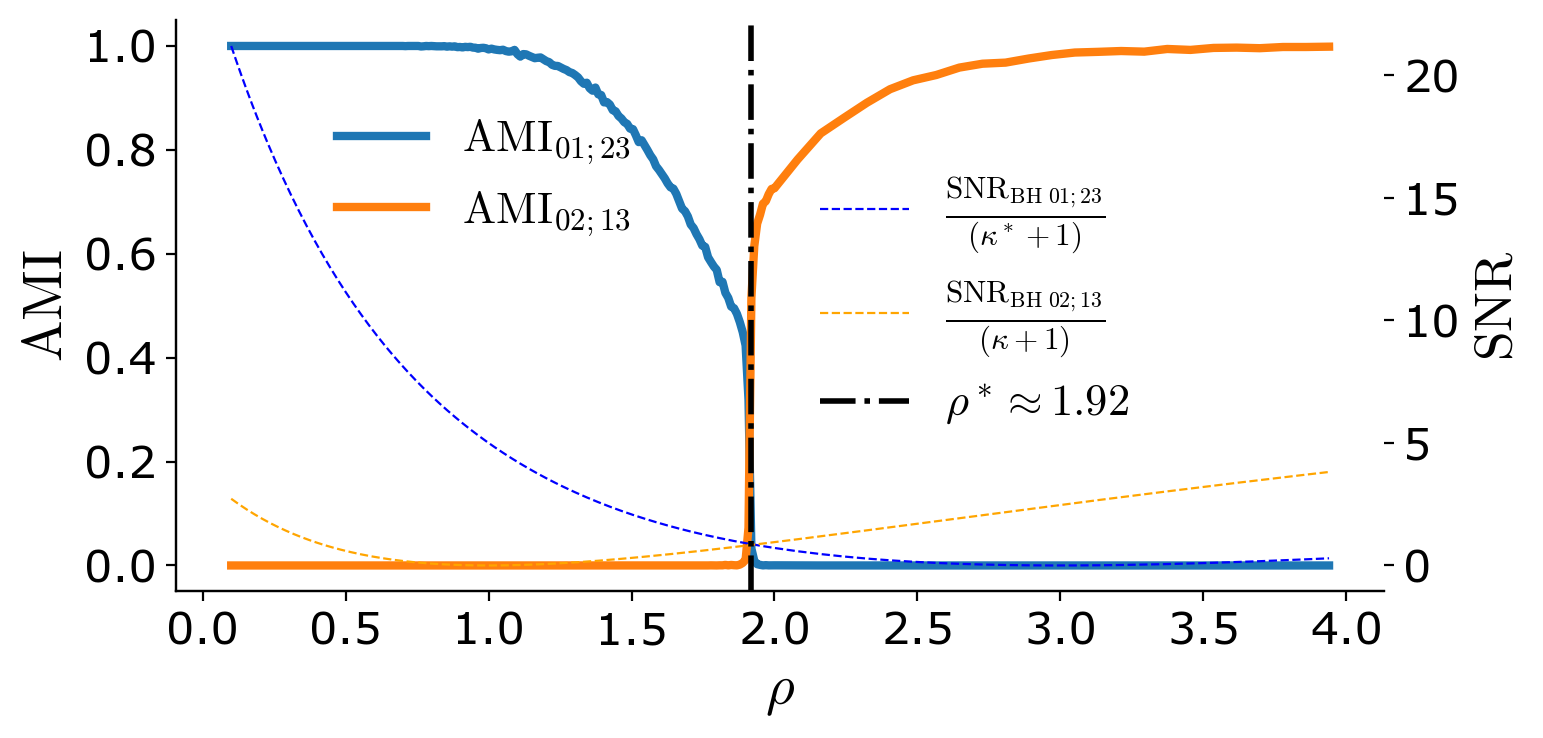

In [8]:
k = Ks[0]
k_star = Ks[1]
aoverastar = []
phi_01_23 = []
phi_02_13 = []
for e in epsilons:
    a, astar = get_a_over_astar(e, k, k_star, d)
    aoverastar.append(a/astar)
    phi_01_23.append(get_phi(a, astar, k, k_star, community_conf="01_23"))
    phi_02_13.append(get_phi(a, astar, k, k_star, community_conf="02_13"))
    # phi_01_23.append(get_modify_snr(a, astar, k, k_star, community_conf="01_23"))
    # phi_02_13.append(get_modify_snr(a, astar, k, k_star, community_conf="02_13"))
# print(phi_01_23)
fig = plt.figure(figsize=(8, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

index = np.where(epsilons<4)[0]
ax.plot(epsilons[index], results[index, 1], lw=3, label=r"$\mathrm{AMI}_{01;23}$")
ax.plot(epsilons[index], results[index, 2], lw=3, label=r"$\mathrm{AMI}_{02;13}$")
# ax.axvline(epsilon_star_switch, color='gray', lw=0.8, ls='--', label=r'$\epsilon^*_{switch}$'+f"={np.round(epsilon_star_switch, 3)}")
# ax.plot(np.array(aoverastar)[index], results[index, 1], lw=1, label="HyperBH_01_23")
# ax.plot(np.array(aoverastar)[index], results[index, 2], lw=1, label="HyperBH_02_13")
# aoverastar_switch = (2**(k-2)*math.factorial(k-2))/ (2**(k_star-2)*math.factorial(k_star-2))
# ax.axvline(aoverastar_switch, color='black', lw=0.8, ls='--', label=r'$\frac{a}{a^*}_{switch}$'+f"={np.round(epsilon_star_switch, 3)}")
ax.set_xlabel(r"$\rho$", fontsize=20)
ax.set_ylabel(r"$\rm AMI$", fontsize=20)
# ax.set_title(rf"n={n},d={d},$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}")
plt.legend(loc=2, bbox_to_anchor=(0.1, 0.9),  fontsize=16, markerscale=2, frameon=False)

ax_twin = ax.twinx()
ax_twin.plot(epsilons[index], np.array(phi_01_23)[index]/(k_star+1), lw=0.8, ls='--', color="blue", label=r"$\frac{\mathrm{SNR}_{\rm{BH}\ 01;23}}{(\kappa^*+1)}$")
ax_twin.plot(epsilons[index], np.array(phi_02_13)[index]/(k+1), lw=0.8, ls='--', color="orange", label=r"$\frac{\mathrm{SNR}_{\rm{BH}\ 02;13}}{(\kappa+1)}$")
# ax_twin.plot(epsilons[index], np.array(phi_01_23)[index], lw=1, ls='--', color="blue", label=r"$\phi_{01;23}$")
# ax_twin.plot(epsilons[index], np.array(phi_02_13)[index], lw=1, ls='--', color="orange", label=r"$\phi_{02;13}$")
phi_01_23 = np.array(phi_01_23)[index]/(k_star+1)
phi_02_13 = np.array(phi_02_13)[index]/(k+1)
diff = phi_01_23 - phi_02_13
indices = np.where(np.sign(diff[:-1]) * np.sign(diff[1:]) < 0)[0]
epsilon_star_switch_m = epsilons[index][indices]
# ax_twin.plot(np.array(aoverastar)[index], np.array(phi_01_23)[index], lw=1, ls='--', color="blue", label="phi_01_23")
# ax_twin.plot(np.array(aoverastar)[index], np.array(phi_02_13)[index], lw=1, ls='--', color="orange", label="phi_02_13")
ax_twin.set_ylabel(r'$\mathrm{SNR}$')
# ax_twin.axhline(1, color='black', lw=0.8, ls=':')
# ax_twin.axvline(epsilon_star_switch_m, color='black', lw=2, ls='-.', label=r'$\epsilon^*_{\frac{\phi_{01;23}}{(k^*+1)}=\frac{\phi_{02;13}}{(k+1)}}\approx$'+f"{np.round(epsilon_star_switch_m[0], 2)}")
ax_twin.axvline(epsilon_star_switch_m, color='black', lw=2, ls='-.', label=rf'$\rho^*\approx{np.round(epsilon_star_switch_m[0], 2)}$')

plt.legend(loc=2, bbox_to_anchor=(0.5, 0.8),  fontsize=16, markerscale=2, frameon=False)

save_path = f"./_Figure/Hyper/OrderEffect/" + f"Figure_Appendix_n={n}_d={d}_k={k}_kstar={k_star}_orderdiff_v2.pdf"
plt.tight_layout()
plt.savefig(save_path, dpi=600)

In [40]:
n = 8000
d = 50
Ks = (2, 4, )
load_path = f"./result/hyperOrderEffect/exp10.27_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}.txt"
epsilons, results = read_exp(load_path=load_path)
# print(np.shape(results))
k = Ks[0]
k_star = Ks[1]
epsilon_star_switch = get_epsilon_star_switch(k, k_star)
print(epsilon_star_switch)

3.4285714285714284


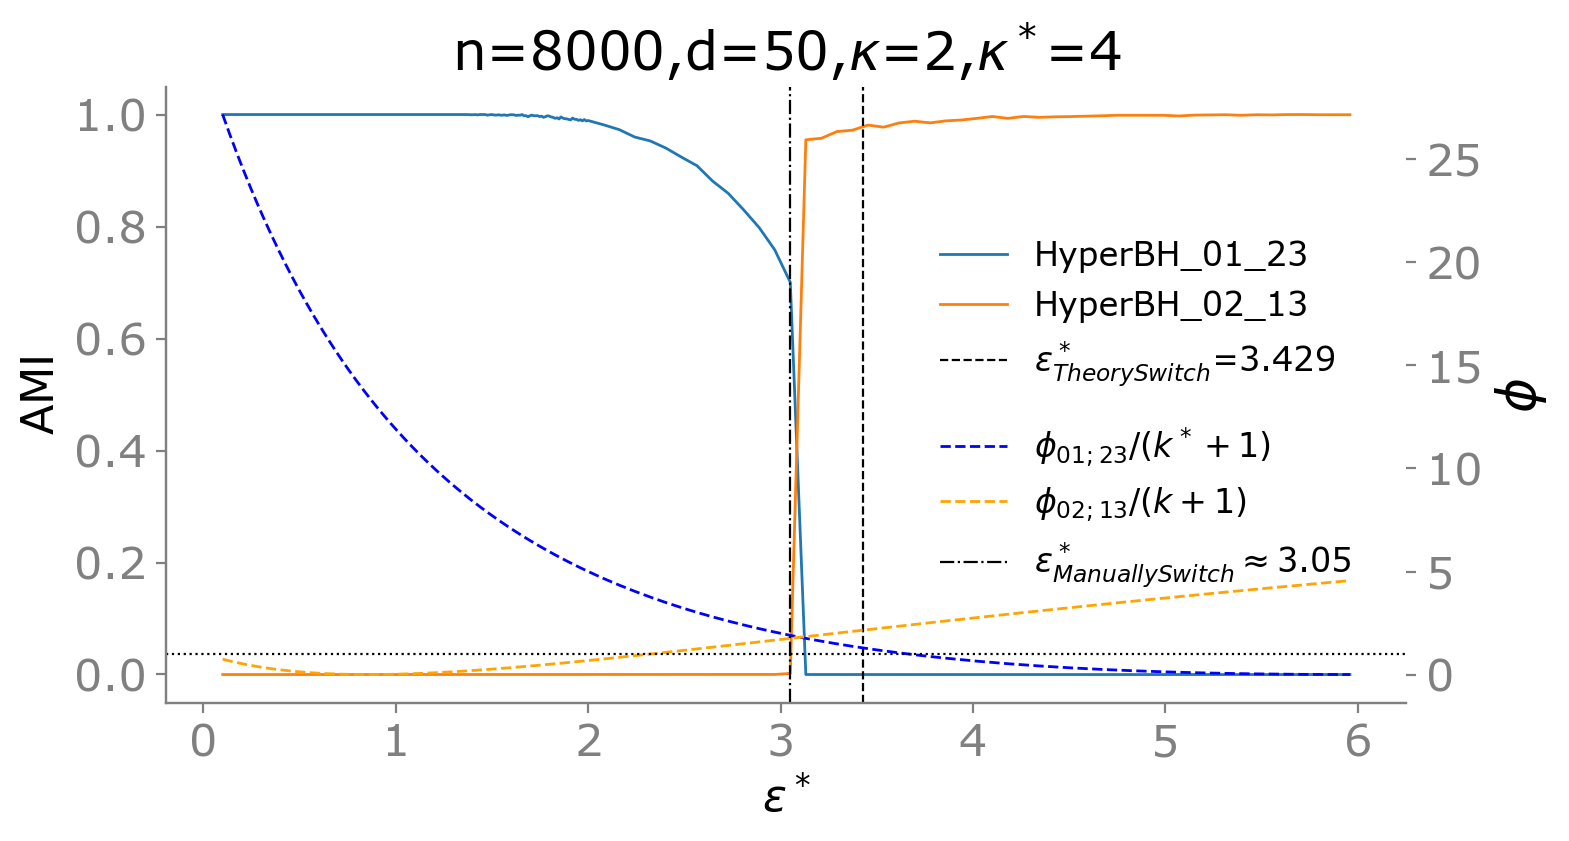

In [42]:
k = Ks[0]
k_star = Ks[1]
aoverastar = []
phi_01_23 = []
phi_02_13 = []
for e in epsilons:
    a, astar = get_a_over_astar(e, k, k_star, d)
    aoverastar.append(a/astar)
    # phi_01_23.append(get_phi(a, astar, k, k_star, community_conf="01_23"))
    # phi_02_13.append(get_phi(a, astar, k, k_star, community_conf="02_13"))
    phi_01_23.append(get_modify_phi(a, astar, k, k_star, community_conf="01_23"))
    phi_02_13.append(get_modify_phi(a, astar, k, k_star, community_conf="02_13"))
# print(phi_01_23)
fig = plt.figure(figsize=(8, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

index = np.where(epsilons<6)[0]
ax.plot(epsilons[index], results[index, 1], lw=1, label="HyperBH_01_23")
ax.plot(epsilons[index], results[index, 2], lw=1, label="HyperBH_02_13")
ax.axvline(epsilon_star_switch, color='black', lw=0.8, ls='--', label=r'$\epsilon^*_{TheorySwitch}$'+f"={np.round(epsilon_star_switch, 3)}")
# ax.plot(np.array(aoverastar)[index], results[index, 1], lw=1, label="HyperBH_01_23")
# ax.plot(np.array(aoverastar)[index], results[index, 2], lw=1, label="HyperBH_02_13")
# aoverastar_switch = (2**(k-2)*math.factorial(k-2))/ (2**(k_star-2)*math.factorial(k_star-2))
# ax.axvline(aoverastar_switch, color='black', lw=0.8, ls='--', label=r'$\frac{a}{a^*}_{switch}$'+f"={np.round(epsilon_star_switch, 3)}")
ax.set_xlabel(r"$\epsilon^*$", fontsize=16)
ax.set_ylabel(r"$\rm AMI$", fontsize=16)
ax.set_title(rf"n={n},d={d},$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}")
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.8),  fontsize=12, markerscale=2, frameon=False)

ax_twin = ax.twinx()
ax_twin.plot(epsilons[index], np.array(phi_01_23)[index]/(k_star+1), lw=1, ls='--', color="blue", label=r"$\phi_{01;23}/(k^*+1)$")
ax_twin.plot(epsilons[index], np.array(phi_02_13)[index]/(k+1), lw=1, ls='--', color="orange", label=r"$\phi_{02;13}/(k+1)$")
phi_01_23 = np.array(phi_01_23)[index]/(k_star+1)
phi_02_13 = np.array(phi_02_13)[index]/(k+1)
diff = phi_01_23 - phi_02_13
indices = np.where(np.sign(diff[:-1]) * np.sign(diff[1:]) < 0)[0]
epsilon_star_switch_m = epsilons[index][indices]
# ax_twin.plot(np.array(aoverastar)[index], np.array(phi_01_23)[index], lw=1, ls='--', color="blue", label="phi_01_23")
# ax_twin.plot(np.array(aoverastar)[index], np.array(phi_02_13)[index], lw=1, ls='--', color="orange", label="phi_02_13")
ax_twin.set_ylabel(r'$\phi$')
ax_twin.axhline(1, color='black', lw=0.8, ls=':')
ax_twin.axvline(epsilon_star_switch_m, color='black', lw=0.8, ls='-.', label=r'$\epsilon^*_{ManuallySwitch}\approx$'+f"{np.round(epsilon_star_switch_m[0], 2)}")
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.5),  fontsize=12, markerscale=2, frameon=False)

In [43]:
n = 8000
d = 50
Ks = (2, 5, )
load_path = f"./result/hyperOrderEffect/exp10.27_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}.txt"
epsilons, results = read_exp(load_path=load_path)
# print(np.shape(results))
k = Ks[0]
k_star = Ks[1]
epsilon_star_switch = get_epsilon_star_switch(k, k_star)
print(epsilon_star_switch)

5.333333333333333


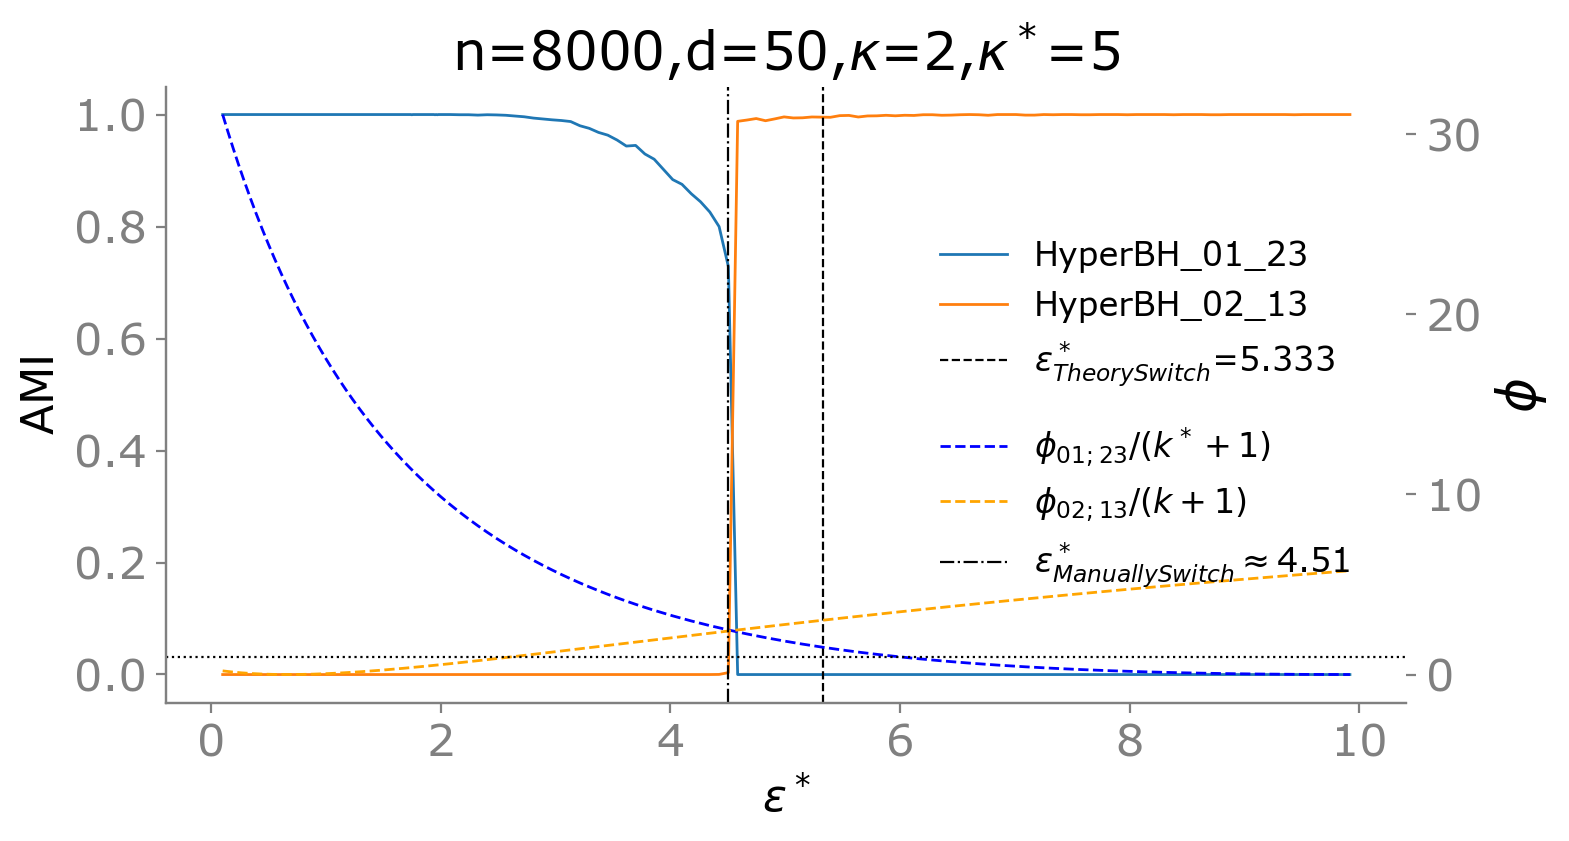

In [45]:
k = Ks[0]
k_star = Ks[1]
aoverastar = []
phi_01_23 = []
phi_02_13 = []
for e in epsilons:
    a, astar = get_a_over_astar(e, k, k_star, d)
    aoverastar.append(a/astar)
    # phi_01_23.append(get_phi(a, astar, k, k_star, community_conf="01_23"))
    # phi_02_13.append(get_phi(a, astar, k, k_star, community_conf="02_13"))
    phi_01_23.append(get_modify_phi(a, astar, k, k_star, community_conf="01_23"))
    phi_02_13.append(get_modify_phi(a, astar, k, k_star, community_conf="02_13"))
# print(phi_01_23)
fig = plt.figure(figsize=(8, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

index = np.where(epsilons<10)[0]
ax.plot(epsilons[index], results[index, 1], lw=1, label="HyperBH_01_23")
ax.plot(epsilons[index], results[index, 2], lw=1, label="HyperBH_02_13")
ax.axvline(epsilon_star_switch, color='black', lw=0.8, ls='--', label=r'$\epsilon^*_{TheorySwitch}$'+f"={np.round(epsilon_star_switch, 3)}")
# ax.plot(np.array(aoverastar)[index], results[index, 1], lw=1, label="HyperBH_01_23")
# ax.plot(np.array(aoverastar)[index], results[index, 2], lw=1, label="HyperBH_02_13")
# aoverastar_switch = (2**(k-2)*math.factorial(k-2))/ (2**(k_star-2)*math.factorial(k_star-2))
# ax.axvline(aoverastar_switch, color='black', lw=0.8, ls='--', label=r'$\frac{a}{a^*}_{switch}$'+f"={np.round(epsilon_star_switch, 3)}")
ax.set_xlabel(r"$\epsilon^*$", fontsize=16)
ax.set_ylabel(r"$\rm AMI$", fontsize=16)
ax.set_title(rf"n={n},d={d},$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}")
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.8),  fontsize=12, markerscale=2, frameon=False)

ax_twin = ax.twinx()
ax_twin.plot(epsilons[index], np.array(phi_01_23)[index]/(k_star+1), lw=1, ls='--', color="blue", label=r"$\phi_{01;23}/(k^*+1)$")
ax_twin.plot(epsilons[index], np.array(phi_02_13)[index]/(k+1), lw=1, ls='--', color="orange", label=r"$\phi_{02;13}/(k+1)$")
phi_01_23 = np.array(phi_01_23)[index]/(k_star+1)
phi_02_13 = np.array(phi_02_13)[index]/(k+1)
diff = phi_01_23 - phi_02_13
indices = np.where(np.sign(diff[:-1]) * np.sign(diff[1:]) < 0)[0]
epsilon_star_switch_m = epsilons[index][indices]
# ax_twin.plot(np.array(aoverastar)[index], np.array(phi_01_23)[index], lw=1, ls='--', color="blue", label="phi_01_23")
# ax_twin.plot(np.array(aoverastar)[index], np.array(phi_02_13)[index], lw=1, ls='--', color="orange", label="phi_02_13")
ax_twin.set_ylabel(r'$\phi$')
ax_twin.axhline(1, color='black', lw=0.8, ls=':')
ax_twin.axvline(epsilon_star_switch_m, color='black', lw=0.8, ls='-.', label=r'$\epsilon^*_{ManuallySwitch}\approx$'+f"{np.round(epsilon_star_switch_m[0], 2)}")
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.5),  fontsize=12, markerscale=2, frameon=False)

## Test Hetergenous Connection

In [38]:
def get_modify_phi(a, a_star, k, k_star, community_conf="01_23"):
    c_k = (a*(2**(k-1)-1))/(4**(k-1)*math.factorial(k-1))
    c_kstar = (a_star*(2**(k_star-1)-1))/(4**(k_star-1)*math.factorial(k_star-1))
    denominator = 4*((k-1)*c_k+(k_star-1)*c_kstar)
    if community_conf == "01_23":
        phi = (((a_star*(2**(k_star-2)-1/2))/(4**(k_star-2)*math.factorial(k_star-2)))**2+(-(a/2)/(4**(k-2)*math.factorial(k-2)))**2) / denominator
    elif community_conf == "02_13":
        phi = (((a*(2**(k-2)-1/2))/(4**(k-2)*math.factorial(k-2)))**2+(-(a_star/2)/(4**(k_star-2)*math.factorial(k_star-2)))**2) / denominator
    return phi

In [40]:
n = 8000
d = 10
Ks = (3, 4, )
load_path = f"./result/hyperOrderEffect/exp8.26_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}.txt"
epsilons, results = read_exp(load_path=load_path)
# print(np.shape(results))
k = Ks[0]
k_star = Ks[1]
epsilon_star_switch = get_epsilon_star_switch(k, k_star)
print(epsilon_star_switch)

1.7142857142857142


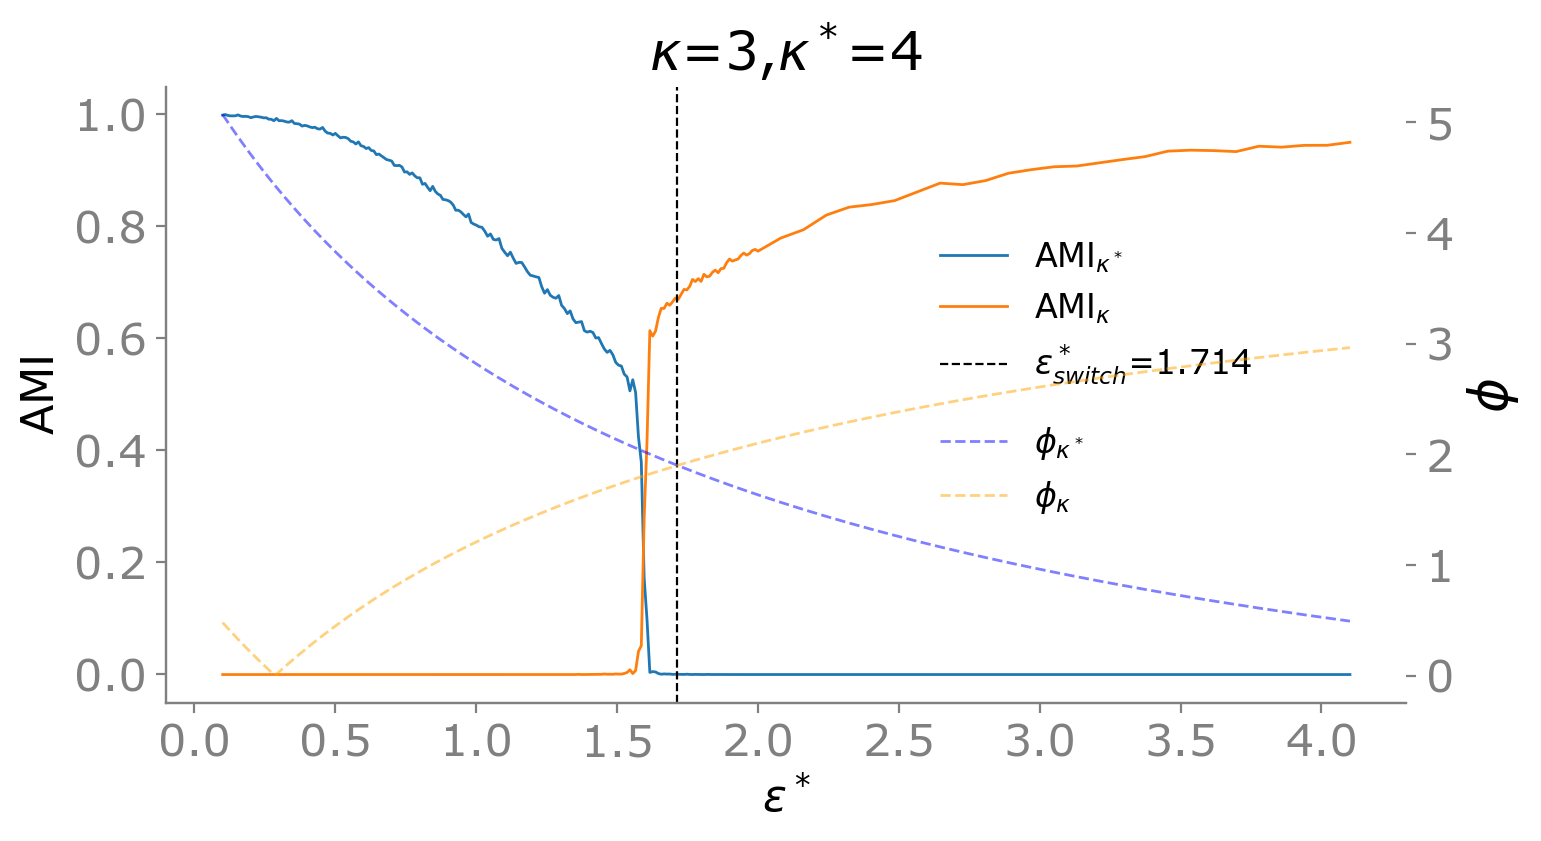

In [43]:
fig = plt.figure(figsize=(8, 4))
widths = [3]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
index = np.where(epsilons<5)[0]
phi_01_23 = []
phi_02_13 = []
for e in epsilons[index]:
    a, astar = get_a_over_astar(e, k, k_star, d)
    phi_01_23.append(get_phi(a, astar, k, k_star, community_conf="01_23"))
    phi_02_13.append(get_phi(a, astar, k, k_star, community_conf="02_13"))
phi_01_23 = np.array(phi_01_23)
phi_02_13 = np.array(phi_02_13)
plot_ami_phi(ax, epsilons=epsilons[index], ami_kstar=results[index, 1], ami=results[index, 2], 
             phi_kstar=np.sqrt(phi_01_23), phi=np.sqrt(phi_02_13), epsilon_switch=epsilon_star_switch, 
             title=rf"$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}", show_legend=True)

In [7]:
n = 8000
d = 10
Ks = (3, 4, )
epsilon_star = 1.66
_, results = exp_subprocess(n=n, q=4, d=d, epsilon_star=epsilon_star, Ks=Ks, times=1, save_path=None, only_assortative=True, old=False, diff_shape=False)
print(results)

Generating hyper edges for order 3...
Generating hyper edges for order 4...
times=0 start. d=10, E_2/E_3=1.66, hsbm construct time=1.396514892578125
{3: 14780, 4: 8894}
Combined evals: [-2.55221606 -0.36344999], select 2 groups for assortative, select 0 groups for disassortative
EVECs construct: 0.06646466255187988
times=0 end. d=10, E_2/E_3=1.66, total time=1.7494254112243652
1.66 0 0.005097692757740092 0.6252645150463049 0.574477498471713 0.0014713039780922064



In [36]:
k, kstar = Ks[0], Ks[1]
a, astar = get_a_over_astar(e, k, kstar, d)
print(f"In original setting, a(for k)={a}, a*(for k*)={astar}")
# Only consider k* dominated community structure: {01;23}
C_hat_in_k = a / (4**(k-2)*math.factorial(k-2)) * ((2**(k-2)-1)/2)
C_hat_out_k = a / (4**(k-2)*math.factorial(k-2)) * ((2**(k-2))/2)
C_hat_in_kstar = astar / (4**(kstar-2)*math.factorial(kstar-2)) * (2**(kstar-2)-1/2)
C_hat_out_kstar = 0
print(rf"In original setting, aggregate $C$ by k* dominated community structure, we have \n$\hat{{C}}_{{in}}^{{\kappa}}=${C_hat_in_k}, \n$\hat{{C}}_{{out}}^{{\kappa}}=${C_hat_out_k}, \n$\hat{{C}}_{{in}}^{{\kappa^*}}=${C_hat_in_kstar}, \n$\hat{{C}}_{{out}}^{{\kappa^*}}=${C_hat_out_kstar}")

c_out_k = math.factorial(k-2) * C_hat_out_k
c_in_k = 2**(k-2)*math.factorial(k-2)*C_hat_in_k-(2**(k-2)-1)*math.factorial(k-2)*C_hat_out_k
c_out_kstar = math.factorial(kstar-2) * C_hat_out_kstar
c_in_kstar = 2**(kstar-2)*math.factorial(kstar-2)*C_hat_in_kstar-(2**(kstar-2)-1)*math.factorial(kstar-2)*C_hat_out_kstar

print(rf"In new setting with 2 communities: 01;23, the derived tensor $C$ based on $\hat{{C}}$ is: \n$C_{{in}}^{{\kappa}}=${c_in_k}, \n$C_{{out}}^{{\kappa}}=${c_out_k}, \n$C_{{in}}^{{\kappa^*}}=${c_in_kstar}, \n$C_{{out}}^{{\kappa^*}}=${c_out_kstar}")

sizes = [int(n / 2)] * 2
ps_dict = dict()
ps_dict[k] = np.zeros(tuple([2]*k))
for index in itertools.product(range(2), repeat=k):
    if np.size(np.unique(index)) == 1:
        ps_dict[k][index] = c_in_k / (n**(k-1))
    else:
        ps_dict[k][index] = c_out_k / (n**(k-1))
ps_dict[kstar] = np.zeros(tuple([2]*kstar))
for index in itertools.product(range(2), repeat=kstar):
    if np.size(np.unique(index)) == 1:
        ps_dict[kstar][index] = c_in_kstar / (n**(kstar-1))
    else:
        ps_dict[kstar][index] = c_out_kstar / (n**(kstar-1))

start = time.time()
results = ""
hsbm = HyperSBM(sizes, ps_dict)
t = 0
print(f't={t} d={d}, E_2/E_3={epsilon_star}, hsbm construct time={time.time()-start}')
# Community Detection
BH_Partition = CDwithBH(hsbm, given_q=2, only_assortative=True)  # Hyper BH
group_01_23 = np.array([0] * (4000) + [1] * (4000))
ami_01_23 = adjusted_mutual_info_score(group_01_23, BH_Partition)
group_02_13 = np.array([0]*2000 + [1]*2000+ [0]*2000 + [1]*2000)
ami_02_13 = adjusted_mutual_info_score(group_02_13, BH_Partition)
results += f'{epsilon_star} {t} {ami_01_23} {ami_02_13}'
print(results)

In original setting, a(for k)=80.49566246274465, a*(for k*)=134.59373590588464
In original setting, aggregate $C$ by k* dominated community structure, we have \n$\hat{C}_{in}^{\kappa}=$10.061957807843081, \n$\hat{C}_{out}^{\kappa}=$20.123915615686162, \n$\hat{C}_{in}^{\kappa^*}=$14.721189864706133, \n$\hat{C}_{out}^{\kappa^*}=$0
In new setting with 2 communities: 01;23, the derived tensor $C$ based on $\hat{C}$ is: \n$C_{in}^{\kappa}=$0.0, \n$C_{out}^{\kappa}=$20.123915615686162, \n$C_{in}^{\kappa^*}=$117.76951891764907, \n$C_{out}^{\kappa^*}=$0
Generating hyper edges for order 3...
Generating hyper edges for order 4...
t=0 d=10, E_2/E_3=1.66, hsbm construct time=2.6080410480499268
{3: 20118, 4: 4898}
Combined evals: [-2.4632609  -0.00344944], select 2 groups for assortative, select 0 groups for disassortative
EVECs construct: 0.13002443313598633
1.66 0 0.0005599945029696331 -7.866704427086757e-05


In [37]:
print(BH_Partition)

[1 0 1 ... 0 1 1]


## Consider snr cross point

In [12]:
def get_modify_snr(a, a_star, k, k_star, community_conf="01_23"):
    d_k = (a*(2**(k-1)-1))/(4**(k-1)*math.factorial(k-1))
    d_kstar = (a_star*(2**(k_star-1)-1))/(4**(k_star-1)*math.factorial(k_star-1))
    d = d_k + d_kstar
    hat_k = d / (d_k/k + d_kstar/k_star)
    q = 2
    if community_conf == "01_23":
        cin_k = 0
        cout_k = a / (2**(k-1))
        cin_kstar = (2**k_star-2) * a_star / (2**k_star)
        cout_kstar = 0
        snr = d*(hat_k-1)
        # print(snr, end=" ")
        snr = snr*(abs(cin_k-cout_k)/(d_k*math.factorial(k-1)*q**(k-1)))**(2*(hat_k*d_k)/(d*k))
        # print(2*(hat_k*d_k)/(d*k))
        snr = snr*(abs(cin_kstar-cout_kstar)/(d_kstar*math.factorial(k_star-1)*q**(k_star-1)))**(2*(hat_k*d_kstar)/(d*k_star))
    elif community_conf == "02_13":
        cin_k = (2**k-2) * a / (2**k)
        cout_k = 0
        cin_kstar = 0
        cout_kstar = a_star / (2**(k_star-1))
        snr = d*(hat_k-1)
        snr = snr*(abs(cin_k-cout_k)/(d_k*math.factorial(k-1)*q**(k-1)))**(2*(hat_k*d_k)/(d*k))
        snr = snr*(abs(cin_kstar-cout_kstar)/(d_kstar*math.factorial(k_star-1)*q**(k_star-1)))**(2*(hat_k*d_kstar)/(d*k_star))
    return snr

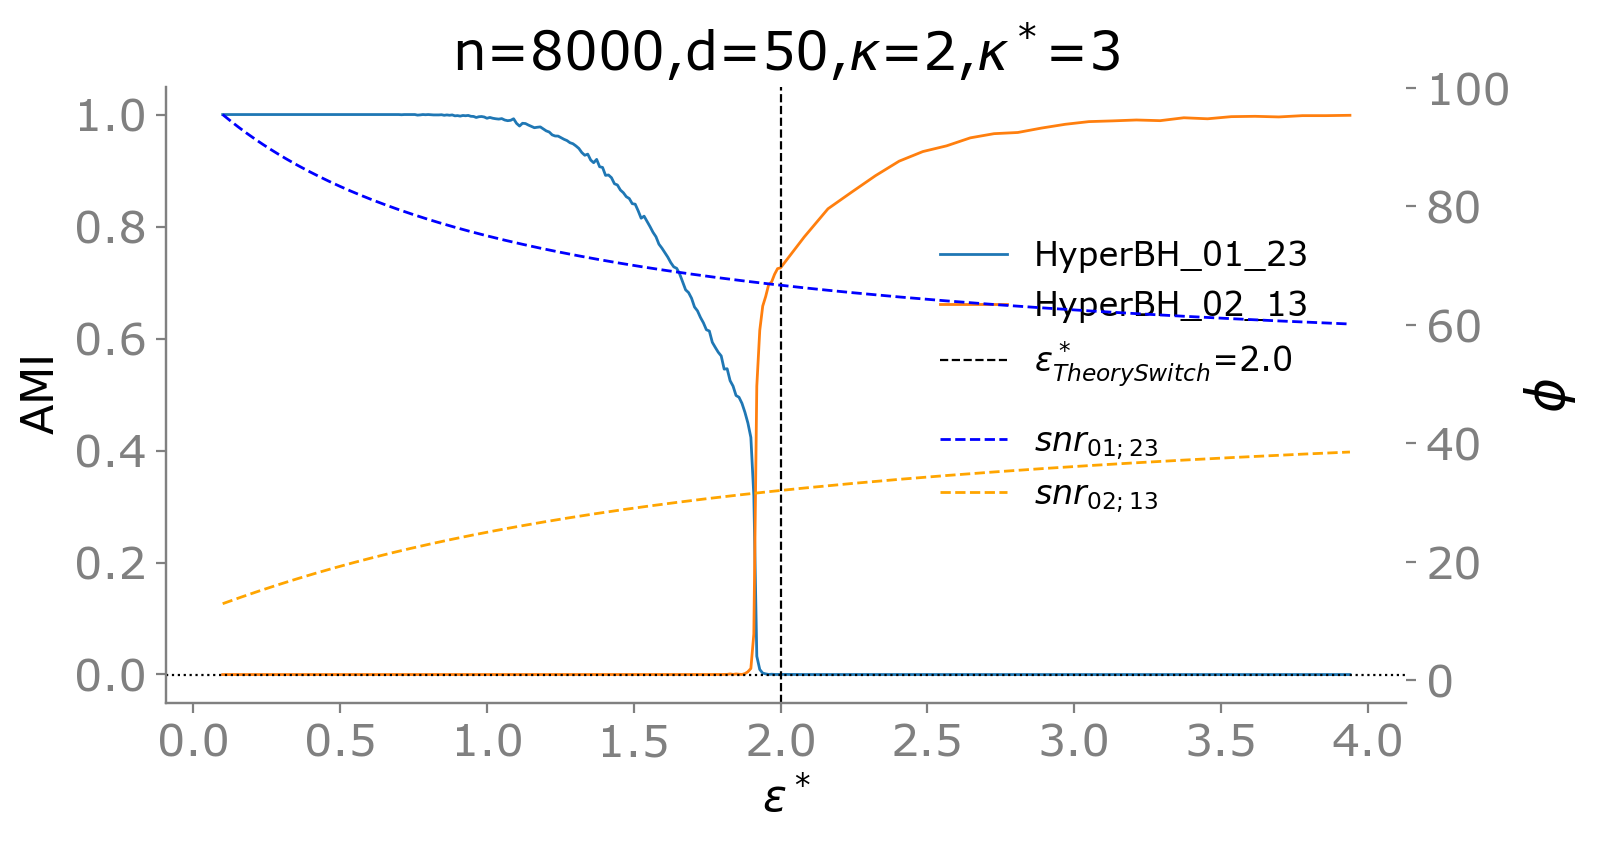

In [15]:
k = Ks[0]
k_star = Ks[1]
aoverastar = []
phi_01_23 = []
phi_02_13 = []
for e in epsilons:
    a, astar = get_a_over_astar(e, k, k_star, d)
    aoverastar.append(a/astar)
    # phi_01_23.append(get_phi(a, astar, k, k_star, community_conf="01_23"))
    # phi_02_13.append(get_phi(a, astar, k, k_star, community_conf="02_13"))
    phi_01_23.append(get_modify_snr(a, astar, k, k_star, community_conf="01_23"))
    phi_02_13.append(get_modify_snr(a, astar, k, k_star, community_conf="02_13"))
# print(phi_01_23)
fig = plt.figure(figsize=(8, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

index = np.where(epsilons<4)[0]
ax.plot(epsilons[index], results[index, 1], lw=1, label="HyperBH_01_23")
ax.plot(epsilons[index], results[index, 2], lw=1, label="HyperBH_02_13")
ax.axvline(epsilon_star_switch, color='black', lw=0.8, ls='--', label=r'$\epsilon^*_{TheorySwitch}$'+f"={np.round(epsilon_star_switch, 3)}")
# ax.plot(np.array(aoverastar)[index], results[index, 1], lw=1, label="HyperBH_01_23")
# ax.plot(np.array(aoverastar)[index], results[index, 2], lw=1, label="HyperBH_02_13")
# aoverastar_switch = (2**(k-2)*math.factorial(k-2))/ (2**(k_star-2)*math.factorial(k_star-2))
# ax.axvline(aoverastar_switch, color='black', lw=0.8, ls='--', label=r'$\frac{a}{a^*}_{switch}$'+f"={np.round(epsilon_star_switch, 3)}")
ax.set_xlabel(r"$\epsilon^*$", fontsize=16)
ax.set_ylabel(r"$\rm AMI$", fontsize=16)
ax.set_title(rf"n={n},d={d},$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}")
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.8),  fontsize=12, markerscale=2, frameon=False)

ax_twin = ax.twinx()
# ax_twin.plot(epsilons[index], np.array(phi_01_23)[index]/(k_star+1), lw=1, ls='--', color="blue", label=r"$\phi_{01;23}/(k^*+1)$")
# ax_twin.plot(epsilons[index], np.array(phi_02_13)[index]/(k+1), lw=1, ls='--', color="orange", label=r"$\phi_{02;13}/(k+1)$")
ax_twin.plot(epsilons[index], np.array(phi_01_23)[index], lw=1, ls='--', color="blue", label=r"$snr_{01;23}$")
ax_twin.plot(epsilons[index], np.array(phi_02_13)[index], lw=1, ls='--', color="orange", label=r"$snr_{02;13}$")
phi_01_23 = np.array(phi_01_23)[index]/(k_star+1)
phi_02_13 = np.array(phi_02_13)[index]/(k+1)
diff = phi_01_23 - phi_02_13
indices = np.where(np.sign(diff[:-1]) * np.sign(diff[1:]) < 0)[0]
epsilon_star_switch_m = epsilons[index][indices]
# ax_twin.plot(np.array(aoverastar)[index], np.array(phi_01_23)[index], lw=1, ls='--', color="blue", label="phi_01_23")
# ax_twin.plot(np.array(aoverastar)[index], np.array(phi_02_13)[index], lw=1, ls='--', color="orange", label="phi_02_13")
ax_twin.set_ylabel(r'$\phi$')
ax_twin.axhline(1, color='black', lw=0.8, ls=':')
# ax_twin.axvline(epsilon_star_switch_m, color='black', lw=0.8, ls='-.', label=r'$\epsilon^*_{ManuallySwitch}\approx$'+f"{np.round(epsilon_star_switch_m[0], 2)}")
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.5),  fontsize=12, markerscale=2, frameon=False)

## Consider Disassortative

In [46]:
n = 8000
d = 50
Ks = (2, 3, )
load_path = f"./result/hyperOrderEffect/exp10.28_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}_allowdisassortative.txt"
epsilons, results = read_exp(load_path=load_path)
# print(np.shape(results))
k = Ks[0]
k_star = Ks[1]
epsilon_star_switch = get_epsilon_star_switch(k, k_star)
print(epsilon_star_switch)

2.0


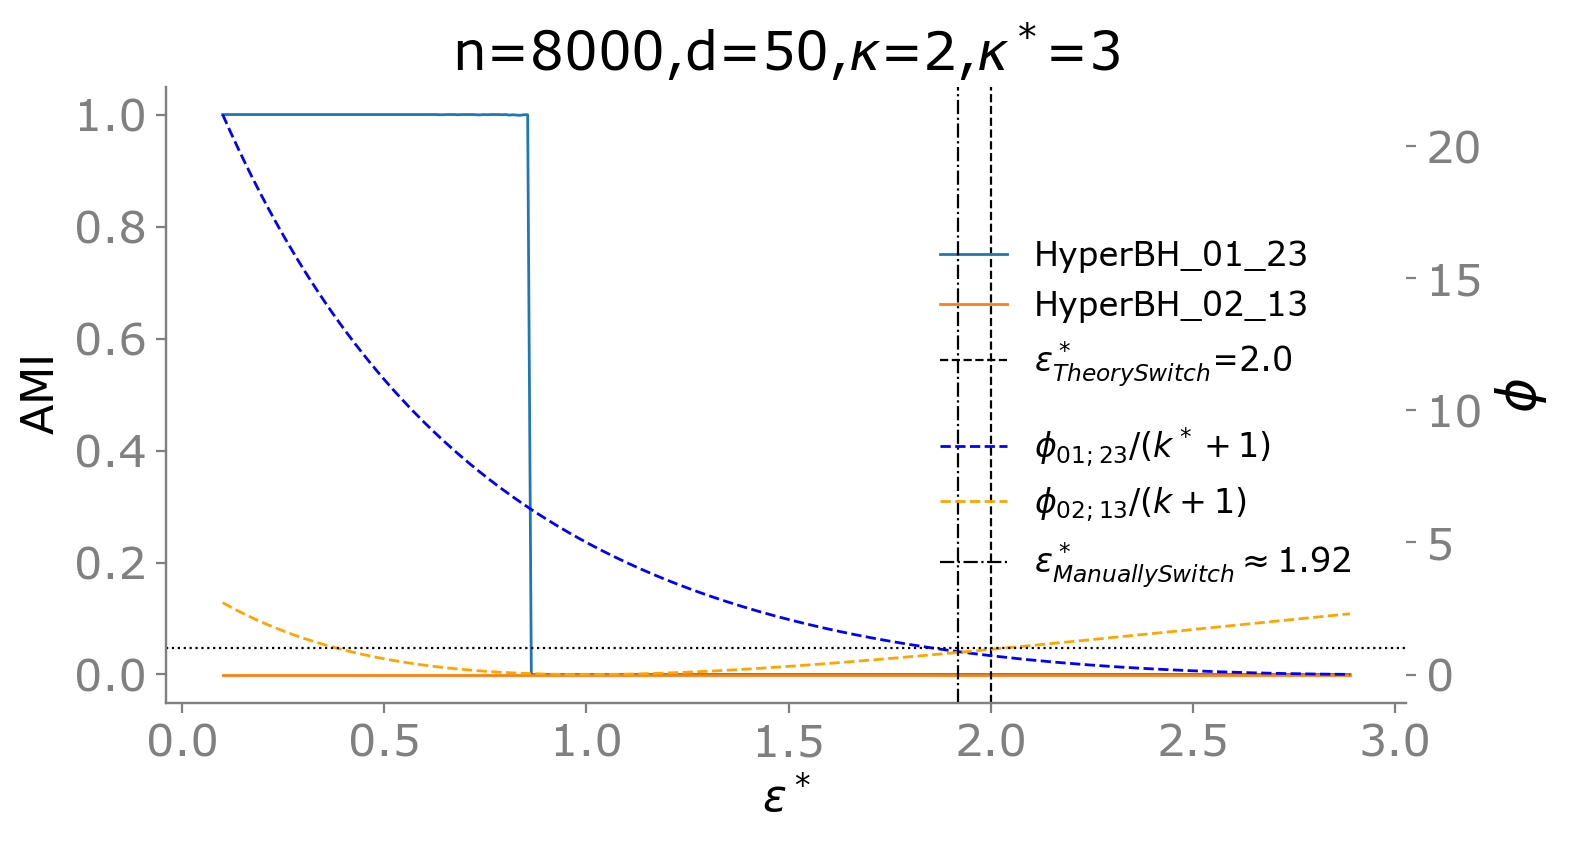

In [47]:
k = Ks[0]
k_star = Ks[1]
aoverastar = []
phi_01_23 = []
phi_02_13 = []
for e in epsilons:
    a, astar = get_a_over_astar(e, k, k_star, d)
    aoverastar.append(a/astar)
    # phi_01_23.append(get_phi(a, astar, k, k_star, community_conf="01_23"))
    # phi_02_13.append(get_phi(a, astar, k, k_star, community_conf="02_13"))
    phi_01_23.append(get_modify_phi(a, astar, k, k_star, community_conf="01_23"))
    phi_02_13.append(get_modify_phi(a, astar, k, k_star, community_conf="02_13"))
# print(phi_01_23)
fig = plt.figure(figsize=(8, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

index = np.where(epsilons<4)[0]
ax.plot(epsilons[index], results[index, 1], lw=1, label="HyperBH_01_23")
ax.plot(epsilons[index], results[index, 2], lw=1, label="HyperBH_02_13")
ax.axvline(epsilon_star_switch, color='black', lw=0.8, ls='--', label=r'$\epsilon^*_{TheorySwitch}$'+f"={np.round(epsilon_star_switch, 3)}")
# ax.plot(np.array(aoverastar)[index], results[index, 1], lw=1, label="HyperBH_01_23")
# ax.plot(np.array(aoverastar)[index], results[index, 2], lw=1, label="HyperBH_02_13")
# aoverastar_switch = (2**(k-2)*math.factorial(k-2))/ (2**(k_star-2)*math.factorial(k_star-2))
# ax.axvline(aoverastar_switch, color='black', lw=0.8, ls='--', label=r'$\frac{a}{a^*}_{switch}$'+f"={np.round(epsilon_star_switch, 3)}")
ax.set_xlabel(r"$\epsilon^*$", fontsize=16)
ax.set_ylabel(r"$\rm AMI$", fontsize=16)
ax.set_title(rf"n={n},d={d},$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}")
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.8),  fontsize=12, markerscale=2, frameon=False)

ax_twin = ax.twinx()
ax_twin.plot(epsilons[index], np.array(phi_01_23)[index]/(k_star+1), lw=1, ls='--', color="blue", label=r"$\phi_{01;23}/(k^*+1)$")
ax_twin.plot(epsilons[index], np.array(phi_02_13)[index]/(k+1), lw=1, ls='--', color="orange", label=r"$\phi_{02;13}/(k+1)$")
phi_01_23 = np.array(phi_01_23)[index]/(k_star+1)
phi_02_13 = np.array(phi_02_13)[index]/(k+1)
diff = phi_01_23 - phi_02_13
indices = np.where(np.sign(diff[:-1]) * np.sign(diff[1:]) < 0)[0]
epsilon_star_switch_m = epsilons[index][indices]
# ax_twin.plot(np.array(aoverastar)[index], np.array(phi_01_23)[index], lw=1, ls='--', color="blue", label="phi_01_23")
# ax_twin.plot(np.array(aoverastar)[index], np.array(phi_02_13)[index], lw=1, ls='--', color="orange", label="phi_02_13")
ax_twin.set_ylabel(r'$\phi$')
ax_twin.axhline(1, color='black', lw=0.8, ls=':')
ax_twin.axvline(epsilon_star_switch_m, color='black', lw=0.8, ls='-.', label=r'$\epsilon^*_{ManuallySwitch}\approx$'+f"{np.round(epsilon_star_switch_m[0], 2)}")
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.5),  fontsize=12, markerscale=2, frameon=False)

## manually modify phi or switch point

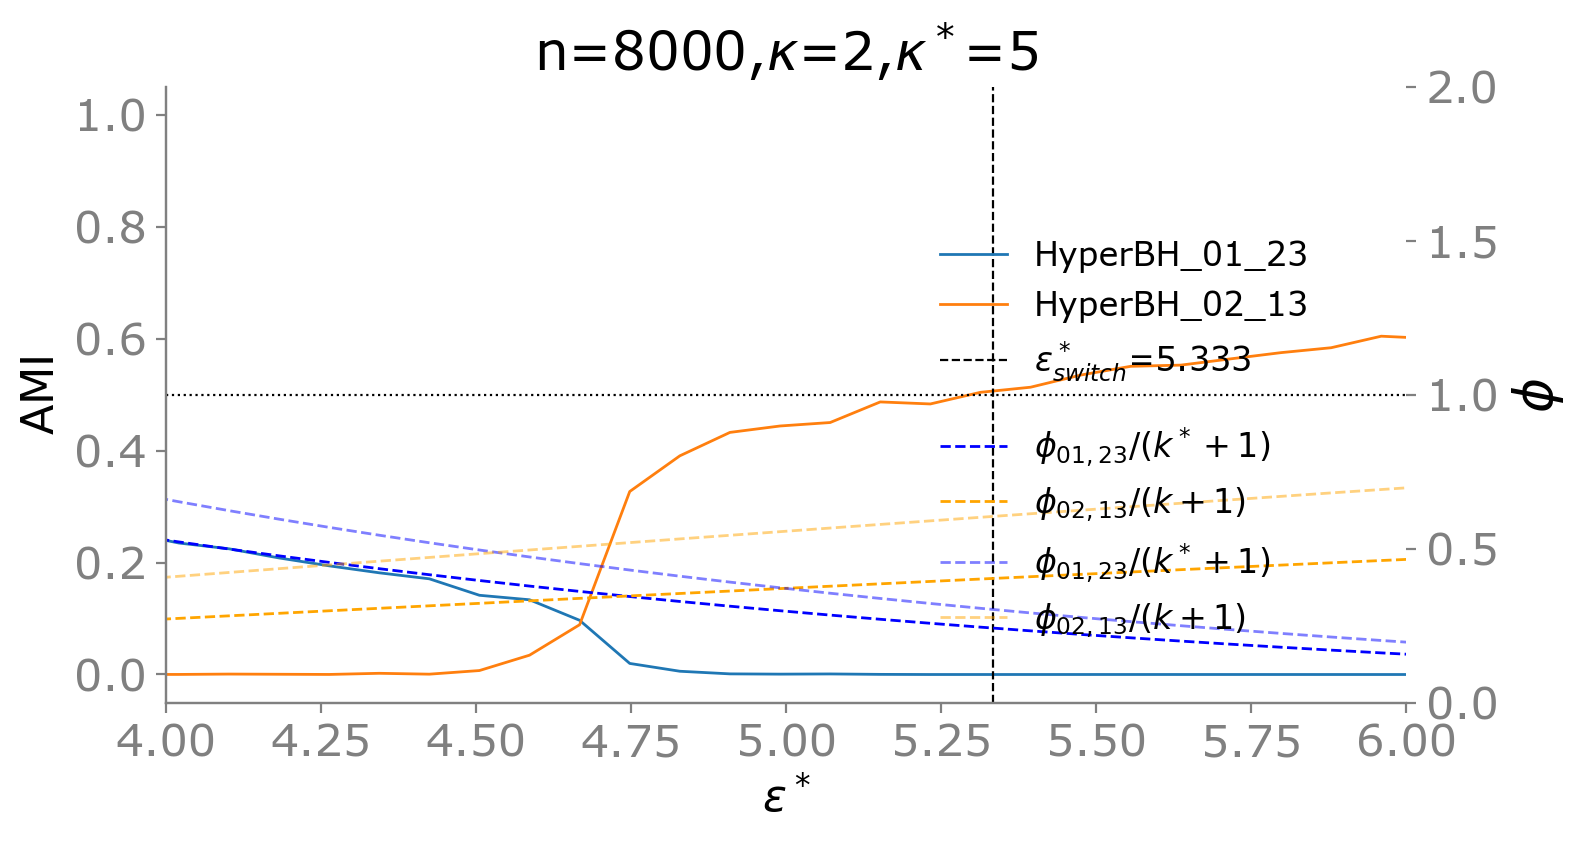

In [41]:
k = Ks[0]
k_star = Ks[1]
d = 10
aoverastar = []
phi_01_23 = []
phi_02_13 = []
for e in epsilons:
    a, astar = get_a_over_astar(e, k, k_star, d)
    aoverastar.append(a/astar)
    phi_01_23.append(get_phi(a, astar, k, k_star, community_conf="01_23"))
    phi_02_13.append(get_phi(a, astar, k, k_star, community_conf="02_13"))
# print(phi_01_23)
fig = plt.figure(figsize=(8, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

index = np.where(epsilons<10)[0]
ax.set_xlim(4, 6)
ax.plot(epsilons[index], results[index, 1], lw=1, label="HyperBH_01_23")
ax.plot(epsilons[index], results[index, 2], lw=1, label="HyperBH_02_13")
ax.axvline(epsilon_star_switch, color='black', lw=0.8, ls='--', label=r'$\epsilon^*_{switch}$'+f"={np.round(epsilon_star_switch, 3)}")
# ax.plot(np.array(aoverastar)[index], results[index, 1], lw=1, label="HyperBH_01_23")
# ax.plot(np.array(aoverastar)[index], results[index, 2], lw=1, label="HyperBH_02_13")
# aoverastar_switch = (2**(k-2)*math.factorial(k-2))/ (2**(k_star-2)*math.factorial(k_star-2))
# ax.axvline(aoverastar_switch, color='black', lw=0.8, ls='--', label=r'$\frac{a}{a^*}_{switch}$'+f"={np.round(epsilon_star_switch, 3)}")
ax.set_xlabel(r"$\epsilon^*$", fontsize=16)
ax.set_ylabel(r"$\rm AMI$", fontsize=16)
ax.set_title(rf"n={n},$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}")
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.8),  fontsize=12, markerscale=2, frameon=False)

ax_twin = ax.twinx()
ax_twin.set_ylim(0, 2)
ax_twin.plot(epsilons[index], np.array(phi_01_23)[index]/(k_star+5/2), lw=1, ls='--', color="blue", label=r"$\phi_{01,23}/(k^*+1)$")
ax_twin.plot(epsilons[index], np.array(phi_02_13)[index]/(k+5/2), lw=1, ls='--', color="orange", label=r"$\phi_{02,13}/(k+1)$")
ax_twin.plot(epsilons[index], np.array(phi_01_23)[index]/(k_star+1), lw=1, ls='--', color="blue", label=r"$\phi_{01,23}/(k^*+1)$", alpha=0.5) 
ax_twin.plot(epsilons[index], np.array(phi_02_13)[index]/(k+1), lw=1, ls='--', color="orange", label=r"$\phi_{02,13}/(k+1)$", alpha=0.5)
# ax_twin.plot(np.array(aoverastar)[index], np.array(phi_01_23)[index], lw=1, ls='--', color="blue", label="phi_01_23")
# ax_twin.plot(np.array(aoverastar)[index], np.array(phi_02_13)[index], lw=1, ls='--', color="orange", label="phi_02_13")
ax_twin.set_ylabel(r'$\phi$')
ax_twin.axhline(1, color='black', lw=0.8, ls=':')
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.5),  fontsize=12, markerscale=2, frameon=False)

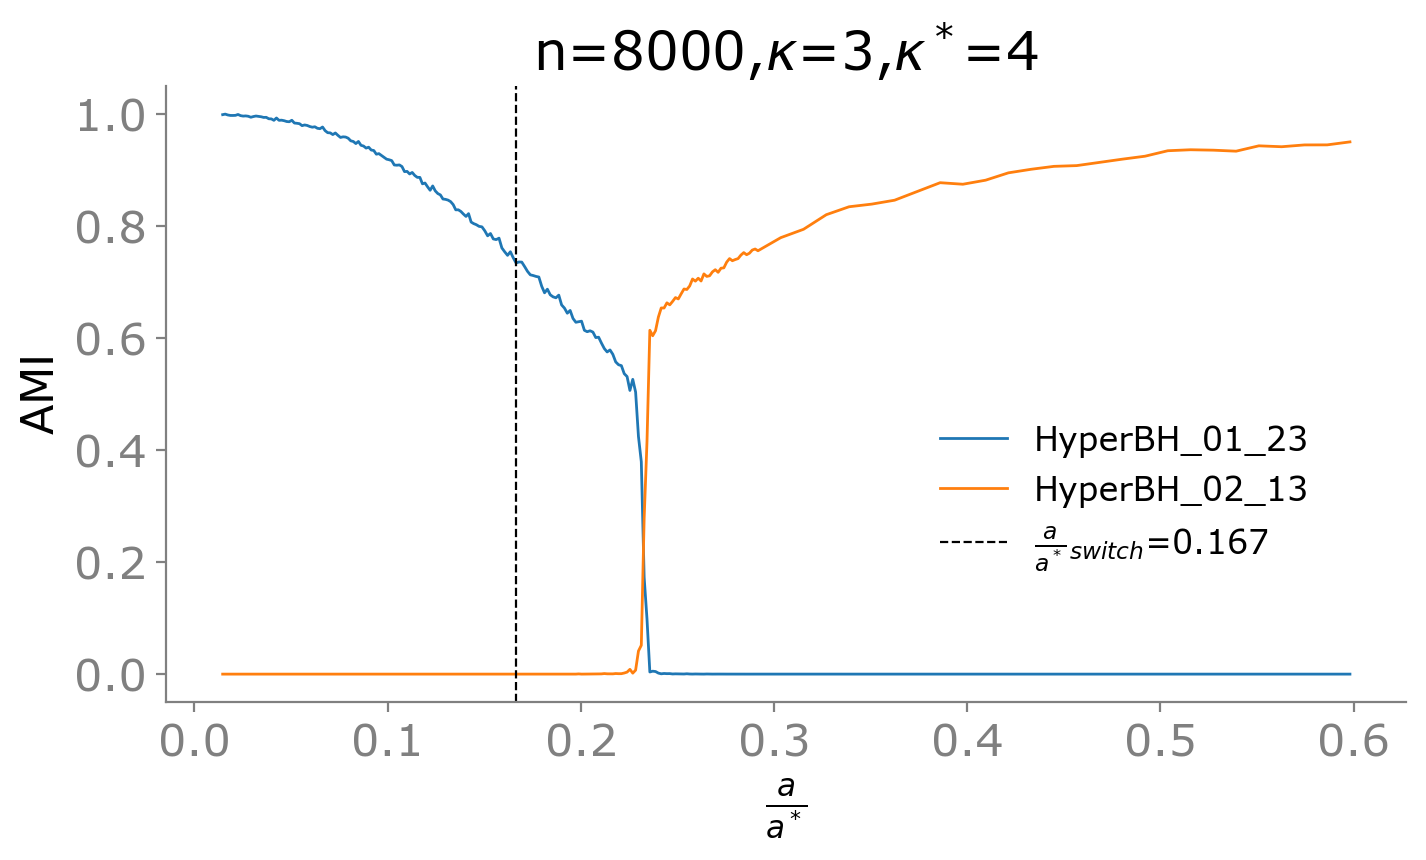

In [114]:
k = Ks[0]
k_star = Ks[1]
d = 10
aoverastar = []
phi_01_23 = []
phi_02_13 = []
for e in epsilons:
    a, astar = get_a_over_astar(e, k, k_star, d)
    aoverastar.append(a/astar)
    phi_01_23.append(get_phi(a, astar, k, k_star, community_conf="01_23"))
    phi_02_13.append(get_phi(a, astar, k, k_star, community_conf="02_13"))
# print(phi_01_23)
fig = plt.figure(figsize=(8, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

index = np.where(epsilons<10)[0]
# ax.plot(epsilons[index], results[index, 1], lw=1, label="HyperBH_01_23")
# ax.plot(epsilons[index], results[index, 2], lw=1, label="HyperBH_02_13")
# ax.axvline(epsilon_star_switch, color='black', lw=0.8, ls='--', label=r'$\epsilon^*_{switch}$'+f"={np.round(epsilon_star_switch, 3)}")
ax.plot(np.array(aoverastar)[index], results[index, 1], lw=1, label="HyperBH_01_23")
ax.plot(np.array(aoverastar)[index], results[index, 2], lw=1, label="HyperBH_02_13")
aoverastar_switch = (2**(k-2)*math.factorial(k-1))/ (2**(k_star-2)*math.factorial(k_star-1))
ax.axvline(aoverastar_switch, color='black', lw=0.8, ls='--', label=r'$\frac{a}{a^*}_{switch}$'+f"={np.round(aoverastar_switch, 3)}")
ax.set_xlabel(r"$\frac{a}{a^*}$", fontsize=16)
ax.set_ylabel(r"$\rm AMI$", fontsize=16)
ax.set_title(rf"n={n},$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}")
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.8),  fontsize=12, markerscale=2, frameon=False)

# ax_twin = ax.twinx()
# # ax_twin.plot(epsilons[index], np.array(phi_01_23)[index], lw=1, ls='--', color="blue", label="phi_01_23")
# # ax_twin.plot(epsilons[index], np.array(phi_02_13)[index], lw=1, ls='--', color="orange", label="phi_02_13")
# ax_twin.plot(np.array(aoverastar)[index], np.array(phi_01_23)[index], lw=1, ls='--', color="blue", label="phi_01_23")
# ax_twin.plot(np.array(aoverastar)[index], np.array(phi_02_13)[index], lw=1, ls='--', color="orange", label="phi_02_13")
# ax_twin.set_ylabel(r'$\phi$')
# ax_twin.axhline(1, color='black', lw=0.8, ls=':')
plt.legend(loc=2, bbox_to_anchor=(0.6, 0.5),  fontsize=12, markerscale=2, frameon=False)

## test parameter in experiment

In [85]:
n = 8000
q = 4
d = 10
Ks = (3, 4, )
epsilon = epsilon_star_switch
a, astar = get_a_over_astar(epsilon, Ks[0], Ks[1], d)
print(epsilon, a, astar, a/astar)
ps_dict = dict()
sizes = [int(n / q)] * q
for i, k, c in zip([0, 1], [Ks[0], Ks[1]], [a/n**(Ks[0]-1), astar/n**(Ks[1]-1)]):
    ps_dict[k] = np.zeros(tuple([q]*k))
    for index in itertools.product(range(q), repeat=k):
        if i == 0:
            if (0 in index and 2 in index and 1 not in index and 3 not in index) or (1 in index and 3 in index and 0 not in index and 2 not in index):
                ps_dict[k][index] = c  # order ks[0] hyperedge only exist between (0, 2), (1, 3)
        if i == 1:
            if (0 in index and 1 in index and 2 not in index and 3 not in index) or (2 in index and 3 in index and 0 not in index and 1 not in index):
                ps_dict[k][index] = c  # order ks[1] hyperedge only exist between (0, 1), (2, 3)
hsbm = HyperSBM(sizes, ps_dict)

1.7142857142857142 60.0 240.0 0.25
Generating hyper edges for order 3...
	 group set (0, 0, 0) have 0 hedges
	 group set (0, 0, 1) have 0 hedges
	 group set (0, 0, 2) have 3748 hedges
	 group set (0, 0, 3) have 0 hedges
	 group set (0, 1, 1) have 0 hedges
	 group set (0, 1, 2) have 0 hedges
	 group set (0, 1, 3) have 0 hedges
	 group set (0, 2, 2) have 3748 hedges
	 group set (0, 2, 3) have 0 hedges
	 group set (0, 3, 3) have 0 hedges
	 group set (1, 1, 1) have 0 hedges
	 group set (1, 1, 2) have 0 hedges
	 group set (1, 1, 3) have 3748 hedges
	 group set (1, 2, 2) have 0 hedges
	 group set (1, 2, 3) have 0 hedges
	 group set (1, 3, 3) have 3748 hedges
	 group set (2, 2, 2) have 0 hedges
	 group set (2, 2, 3) have 0 hedges
	 group set (2, 3, 3) have 0 hedges
	 group set (3, 3, 3) have 0 hedges
Generating hyper edges for order 4...
	 group set (0, 0, 0, 0) have 0 hedges
	 group set (0, 0, 0, 1) have 1248 hedges
	 group set (0, 0, 0, 2) have 0 hedges
	 group set (0, 0, 0, 3) have 0 hedge

In [56]:
np.unique(hsbm.H.toarray())

array([0, 1])

In [78]:
orders = hsbm.H.sum(axis=0).flatten()
edge_order, order_count = np.unique(orders, return_counts=True)
print(edge_order, order_count)

[3 4] [14992  8738]


In [79]:
order_count[0] / order_count[1]

1.7157244220645456

In [80]:
a / astar

0.25

In [81]:
epsilon

1.7142857142857142

In [82]:
for o in ps_dict:
    print(f"Order: {o}")
    coords = list(zip(*np.nonzero(ps_dict[o])))
    for coord in coords:
        print(coord, ps_dict[o][coord])

Order: 3
(0, 0, 2) 9.375e-07
(0, 2, 0) 9.375e-07
(0, 2, 2) 9.375e-07
(1, 1, 3) 9.375e-07
(1, 3, 1) 9.375e-07
(1, 3, 3) 9.375e-07
(2, 0, 0) 9.375e-07
(2, 0, 2) 9.375e-07
(2, 2, 0) 9.375e-07
(3, 1, 1) 9.375e-07
(3, 1, 3) 9.375e-07
(3, 3, 1) 9.375e-07
Order: 4
(0, 0, 0, 1) 4.6875e-10
(0, 0, 1, 0) 4.6875e-10
(0, 0, 1, 1) 4.6875e-10
(0, 1, 0, 0) 4.6875e-10
(0, 1, 0, 1) 4.6875e-10
(0, 1, 1, 0) 4.6875e-10
(0, 1, 1, 1) 4.6875e-10
(1, 0, 0, 0) 4.6875e-10
(1, 0, 0, 1) 4.6875e-10
(1, 0, 1, 0) 4.6875e-10
(1, 0, 1, 1) 4.6875e-10
(1, 1, 0, 0) 4.6875e-10
(1, 1, 0, 1) 4.6875e-10
(1, 1, 1, 0) 4.6875e-10
(2, 2, 2, 3) 4.6875e-10
(2, 2, 3, 2) 4.6875e-10
(2, 2, 3, 3) 4.6875e-10
(2, 3, 2, 2) 4.6875e-10
(2, 3, 2, 3) 4.6875e-10
(2, 3, 3, 2) 4.6875e-10
(2, 3, 3, 3) 4.6875e-10
(3, 2, 2, 2) 4.6875e-10
(3, 2, 2, 3) 4.6875e-10
(3, 2, 3, 2) 4.6875e-10
(3, 2, 3, 3) 4.6875e-10
(3, 3, 2, 2) 4.6875e-10
(3, 3, 2, 3) 4.6875e-10
(3, 3, 3, 2) 4.6875e-10


In [35]:
for index in itertools.product(range(q), repeat=3):
    print(index)

(0, 0, 0)
(0, 0, 1)
(0, 0, 2)
(0, 0, 3)
(0, 1, 0)
(0, 1, 1)
(0, 1, 2)
(0, 1, 3)
(0, 2, 0)
(0, 2, 1)
(0, 2, 2)
(0, 2, 3)
(0, 3, 0)
(0, 3, 1)
(0, 3, 2)
(0, 3, 3)
(1, 0, 0)
(1, 0, 1)
(1, 0, 2)
(1, 0, 3)
(1, 1, 0)
(1, 1, 1)
(1, 1, 2)
(1, 1, 3)
(1, 2, 0)
(1, 2, 1)
(1, 2, 2)
(1, 2, 3)
(1, 3, 0)
(1, 3, 1)
(1, 3, 2)
(1, 3, 3)
(2, 0, 0)
(2, 0, 1)
(2, 0, 2)
(2, 0, 3)
(2, 1, 0)
(2, 1, 1)
(2, 1, 2)
(2, 1, 3)
(2, 2, 0)
(2, 2, 1)
(2, 2, 2)
(2, 2, 3)
(2, 3, 0)
(2, 3, 1)
(2, 3, 2)
(2, 3, 3)
(3, 0, 0)
(3, 0, 1)
(3, 0, 2)
(3, 0, 3)
(3, 1, 0)
(3, 1, 1)
(3, 1, 2)
(3, 1, 3)
(3, 2, 0)
(3, 2, 1)
(3, 2, 2)
(3, 2, 3)
(3, 3, 0)
(3, 3, 1)
(3, 3, 2)
(3, 3, 3)


In [83]:
for index in itertools.combinations_with_replacement(range(q), r=3):
    print(index)

(0, 0, 0)
(0, 0, 1)
(0, 0, 2)
(0, 0, 3)
(0, 1, 1)
(0, 1, 2)
(0, 1, 3)
(0, 2, 2)
(0, 2, 3)
(0, 3, 3)
(1, 1, 1)
(1, 1, 2)
(1, 1, 3)
(1, 2, 2)
(1, 2, 3)
(1, 3, 3)
(2, 2, 2)
(2, 2, 3)
(2, 3, 3)
(3, 3, 3)


In [48]:
epsilon = epsilon_star_switch
a, astar = get_a_over_astar(epsilon, k, k_star, d)
print(epsilon, a, astar, a/astar)

1.7142857142857142 60.0 240.0 0.25


In [45]:
for e in epsilons:
    a, astar = get_a_over_astar(e, k, k_star, d)
    print(e, a, astar, a/astar)

0.1 49.870129870129865 498.70129870129864 0.1
0.10909 53.95744001195318 494.61398855947544 0.10909
0.11818 57.97829636424496 490.5931322071836 0.11818000000000001
0.12727 61.93430652309182 486.6371220483368 0.12727
0.13636 65.82702664648528 482.74440192494325 0.13636000000000004
0.14545 69.65796349531999 478.91346507610854 0.14545
0.15455 73.43269177230461 475.138736799124 0.15455
0.16364 77.14433035253909 471.42709821888957 0.16363999999999998
0.17273 80.79843003687365 467.77299853455486 0.17273
0.18182 84.39631851115833 464.1751100602702 0.18182
0.19091 87.93928292530202 460.6321456461266 0.19090999999999997
0.2 91.42857142857143 457.1428571428571 0.2
0.20909 94.86539463563507 453.70603393579347 0.20909000000000003
0.21818 98.25092702696999 450.3205015444586 0.21818000000000004
0.22727 101.5863082870343 446.98512028439427 0.22727000000000003
0.23636 104.87264458340844 443.6987839880201 0.23636000000000001
0.24545 108.11100978992103 440.46041878150754 0.24545
0.25455 111.3059321213639

In [62]:
q = 4
k = 3
k_star = 4
d = 10
epsilon_star = epsilon_star_switch
a = q**k*math.factorial(k)*d*epsilon_star / (2*(2**k-2)*(k*epsilon_star + k_star))
print(a)
a, astar = get_a_over_astar(epsilon_star, k, k_star, d)
print(a, astar)

60.0
60.0 240.0


# Plot together

In [9]:
def plot_ami_phi(ax, epsilons, k_star, k, ami_kstar, ami, phi_kstar, phi, phi_ylabel=r'$\phi$', title="", 
                 show_legend=True, leftYlabel=True, rightYlabel=True, Xlabel=True):
    ax.plot(epsilons, ami_kstar, lw=3, label=r"$\mathrm{AMI}_{01;23}$")
    ax.plot(epsilons, ami, lw=3, label=r"$\mathrm{AMI}_{02;13}$")
    epsilon_switch = get_epsilon_star_switch(k, k_star)
    # ax.axvline(epsilon_switch, color='gray', lw=0.8, ls='--', label=r'$\epsilon^*_{switch}$')
    if Xlabel:
        ax.set_xlabel(r"$\rho$", fontsize=20)
    if leftYlabel:
        ax.set_ylabel(r"$\rm AMI$", fontsize=20)
    ax.set_title(title)
    if show_legend:
        leg1 = ax.legend(loc="upper left", bbox_to_anchor=(1.1, 0.95),  fontsize=16, markerscale=2, frameon=False)
    
    ax_twin = ax.twinx()
    ax_twin.plot(epsilons, phi_kstar[index]/(k_star+1), lw=0.8, ls='--', color="blue", label=r"$\frac{\mathrm{SNR}_{\rm{BH}\ 01;23}}{(\kappa^*+1)}$", alpha=0.5)
    ax_twin.plot(epsilons, phi[index]/(k+1), lw=0.8, ls='--', color="orange", label=r"$\frac{\mathrm{SNR}_{\rm{BH}\ 02;13}}{(\kappa+1)}$", alpha=0.5)
    if rightYlabel:
        ax_twin.set_ylabel(phi_ylabel)
    diff = phi_kstar[index]/(k_star+1) - phi[index]/(k+1)
    indices = np.where(np.sign(diff[:-1]) * np.sign(diff[1:]) < 0)[0]
    epsilon_star_switch_m = epsilons[index][indices]
    # ax_twin.axvline(epsilon_star_switch_m, color='black', lw=2, ls='-.', label=r'$\epsilon^*_{\frac{\phi_{01;23}}{(k^*+1)}=\frac{\phi_{02;13}}{(k+1)}}$')
    ax_twin.axvline(epsilon_star_switch_m, color='black', lw=2, ls='-.', label=r'$\rho^*$')
    # ax_twin.axhline(1, color='black', lw=0.8, ls=':')
    if show_legend:
        leg2 = ax_twin.legend(loc="upper left", bbox_to_anchor=(1.1, 0.5), fontsize=16, markerscale=2, frameon=False)
        return leg1, leg2

In [10]:
def _get_phis(epsilons, index, k, k_star, d):
    phi_01_23 = []
    phi_02_13 = []
    for e in epsilons[index]:
        a, astar = get_a_over_astar(e, k, k_star, d)
        phi_01_23.append(get_phi(a, astar, k, k_star, community_conf="01_23"))
        phi_02_13.append(get_phi(a, astar, k, k_star, community_conf="02_13"))
    phi_01_23 = np.array(phi_01_23)
    phi_02_13 = np.array(phi_02_13)
    return phi_01_23, phi_02_13

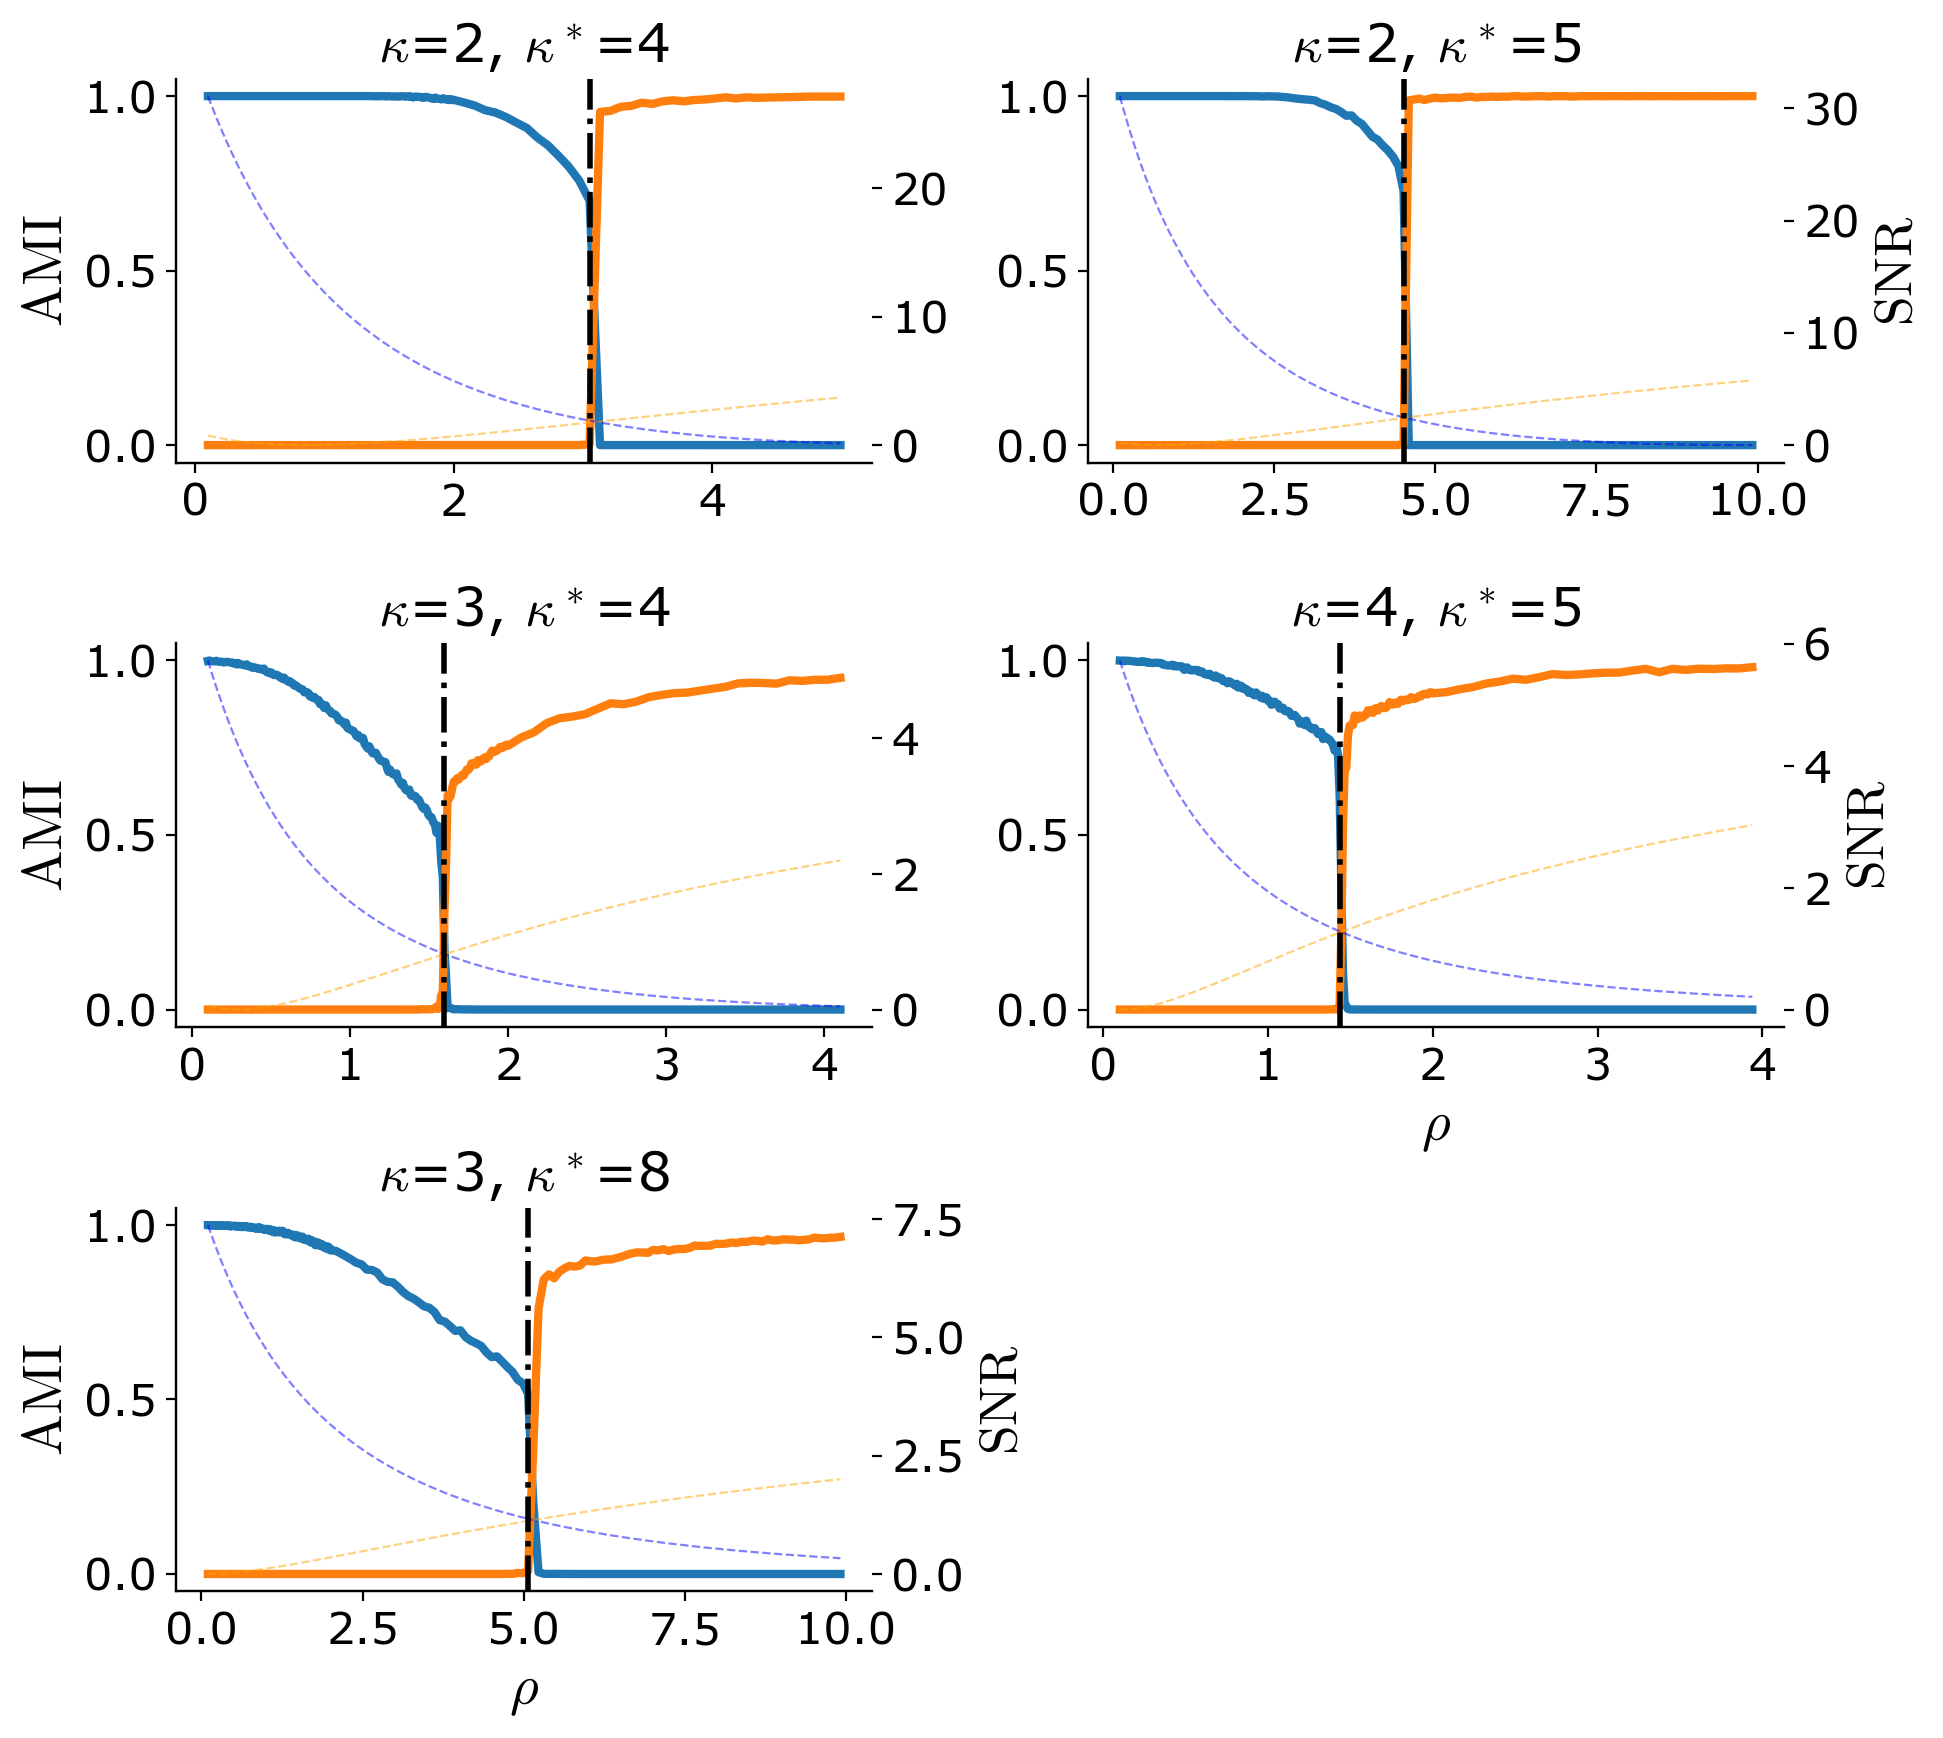

In [11]:
fig = plt.figure(figsize=(10, 9))
widths = [4, 4]
heights = [3, 3, 3]
spec5 = fig.add_gridspec(ncols=2, nrows=3, width_ratios=widths, height_ratios=heights)

row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
n = 8000
d = 50
Ks = (2, 4, )
load_path = f"./result/hyperOrderEffect/exp10.27_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}.txt"
epsilons, results = read_exp(load_path=load_path)
index = np.where(epsilons<5)[0]
k = Ks[0]
k_star = Ks[1]
phi_01_23, phi_02_13 = _get_phis(epsilons, index, k, k_star, d)
plot_ami_phi(ax, epsilons=epsilons[index], k_star=k_star, k=k, ami_kstar=results[index, 1], ami=results[index, 2],
             phi_kstar=phi_01_23, phi=phi_02_13, phi_ylabel=r'$\phi$', title=rf"$\kappa$={k}, $\kappa^*$={k_star}",
             show_legend=False, rightYlabel=False, Xlabel=False)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
n = 8000
d = 50
Ks = (2, 5, )
load_path = f"./result/hyperOrderEffect/exp10.27_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}.txt"
epsilons, results = read_exp(load_path=load_path)
index = np.where(epsilons<10)[0]
k = Ks[0]
k_star = Ks[1]
phi_01_23, phi_02_13 = _get_phis(epsilons, index, k, k_star, d)
plot_ami_phi(ax, epsilons=epsilons[index], k_star=k_star, k=k, ami_kstar=results[index, 1], ami=results[index, 2],
             phi_kstar=phi_01_23, phi=phi_02_13, phi_ylabel=r'$\mathrm{SNR}$', title=rf"$\kappa$={k}, $\kappa^*$={k_star}",
             show_legend=False, leftYlabel=False, Xlabel=False)

row = 1
col = 0
ax = fig.add_subplot(spec5[row, col])
n = 8000
d = 10
Ks = (3, 4, )
load_path = f"./result/hyperOrderEffect/exp8.26_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}.txt"
epsilons, results = read_exp(load_path=load_path)
index = np.where(epsilons<10)[0]
k = Ks[0]
k_star = Ks[1]
phi_01_23, phi_02_13 = _get_phis(epsilons, index, k, k_star, d)
plot_ami_phi(ax, epsilons=epsilons[index], k_star=k_star, k=k, ami_kstar=results[index, 1], ami=results[index, 2],
             phi_kstar=phi_01_23, phi=phi_02_13, phi_ylabel=r'$\phi$', title=rf"$\kappa$={k}, $\kappa^*$={k_star}",
             show_legend=False, rightYlabel=False, Xlabel=False)

row = 1
col = 1
ax = fig.add_subplot(spec5[row, col])
n = 8000
d = 10
Ks = (4, 5, )
load_path = f"./result/hyperOrderEffect/exp10.12_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}.txt"
epsilons, results = read_exp(load_path=load_path)
index = np.where(epsilons<4)[0]
k = Ks[0]
k_star = Ks[1]
phi_01_23, phi_02_13 = _get_phis(epsilons, index, k, k_star, d)
plot_ami_phi(ax, epsilons=epsilons[index], k_star=k_star, k=k, ami_kstar=results[index, 1], ami=results[index, 2],
             phi_kstar=phi_01_23, phi=phi_02_13, phi_ylabel=r'$\mathrm{SNR}$', title=rf"$\kappa$={k}, $\kappa^*$={k_star}",
             show_legend=False, leftYlabel=False)

row = 2
col = 0
ax = fig.add_subplot(spec5[row, col])
n = 8000
d = 10
Ks = (3, 8, )
load_path = f"./result/hyperOrderEffect/exp10.12_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}.txt"
epsilons, results = read_exp(load_path=load_path)
index = np.where(epsilons<10)[0]
k = Ks[0]
k_star = Ks[1]
phi_01_23, phi_02_13 = _get_phis(epsilons, index, k, k_star, d)
plot_ami_phi(ax, epsilons=epsilons[index], k_star=k_star, k=k, ami_kstar=results[index, 1], ami=results[index, 2],
             phi_kstar=phi_01_23, phi=phi_02_13, phi_ylabel=r'$\mathrm{SNR}$', title=rf"$\kappa$={k}, $\kappa^*$={k_star}",
             show_legend=False)

save_path = f"./_Figure/Hyper/OrderEffect/" + f"Figure_Appendix_orderdiff_appmore_v1.pdf"
plt.tight_layout()
plt.savefig(save_path, dpi=600)

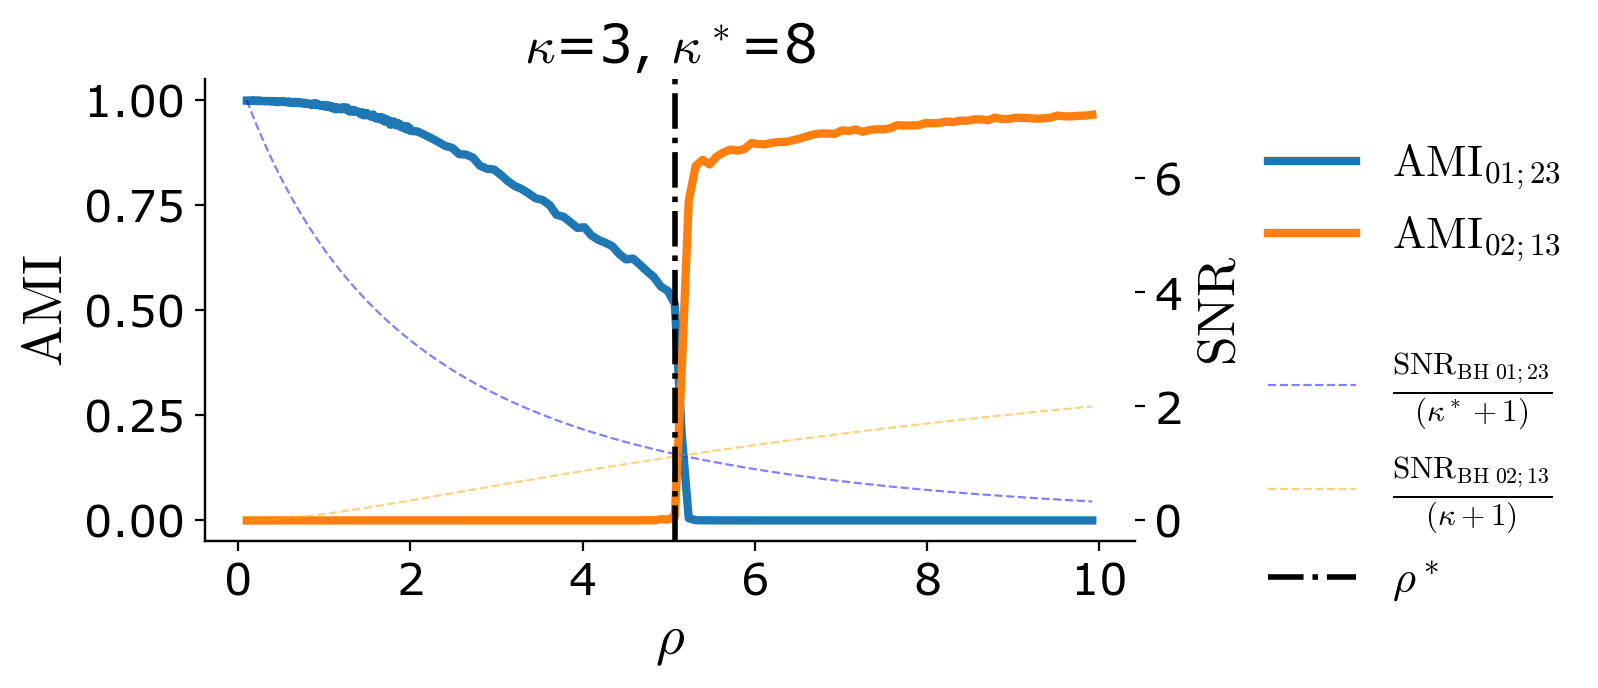

In [52]:
fig = plt.figure(figsize=(6, 3))
widths = [4]
heights = [3]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
n = 8000
d = 10
Ks = (3, 8, )
load_path = f"./result/hyperOrderEffect/exp10.12_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}.txt"
epsilons, results = read_exp(load_path=load_path)
index = np.where(epsilons<10)[0]
k = Ks[0]
k_star = Ks[1]
phi_01_23, phi_02_13 = _get_phis(epsilons, index, k, k_star, d)
leg1, leg2 = plot_ami_phi(ax, epsilons=epsilons[index], k_star=k_star, k=k, ami_kstar=results[index, 1], ami=results[index, 2],
             phi_kstar=phi_01_23, phi=phi_02_13, phi_ylabel=r'$\mathrm{SNR}$', title=rf"$\kappa$={k}, $\kappa^*$={k_star}",
             show_legend=True)
# leg1.set_in_layout(False)
# leg2.set_in_layout(False)
save_path = f"./_Figure/Hyper/OrderEffect/" + f"Figure_Appendix_orderdiff_more_legend_v1.pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_inches='tight', bbox_extra_artists=(leg1, leg2))
# fig.tight_layout(rect=(0, 0, 1, 1))

3.4285714285714284
5.333333333333333
1.7142857142857142


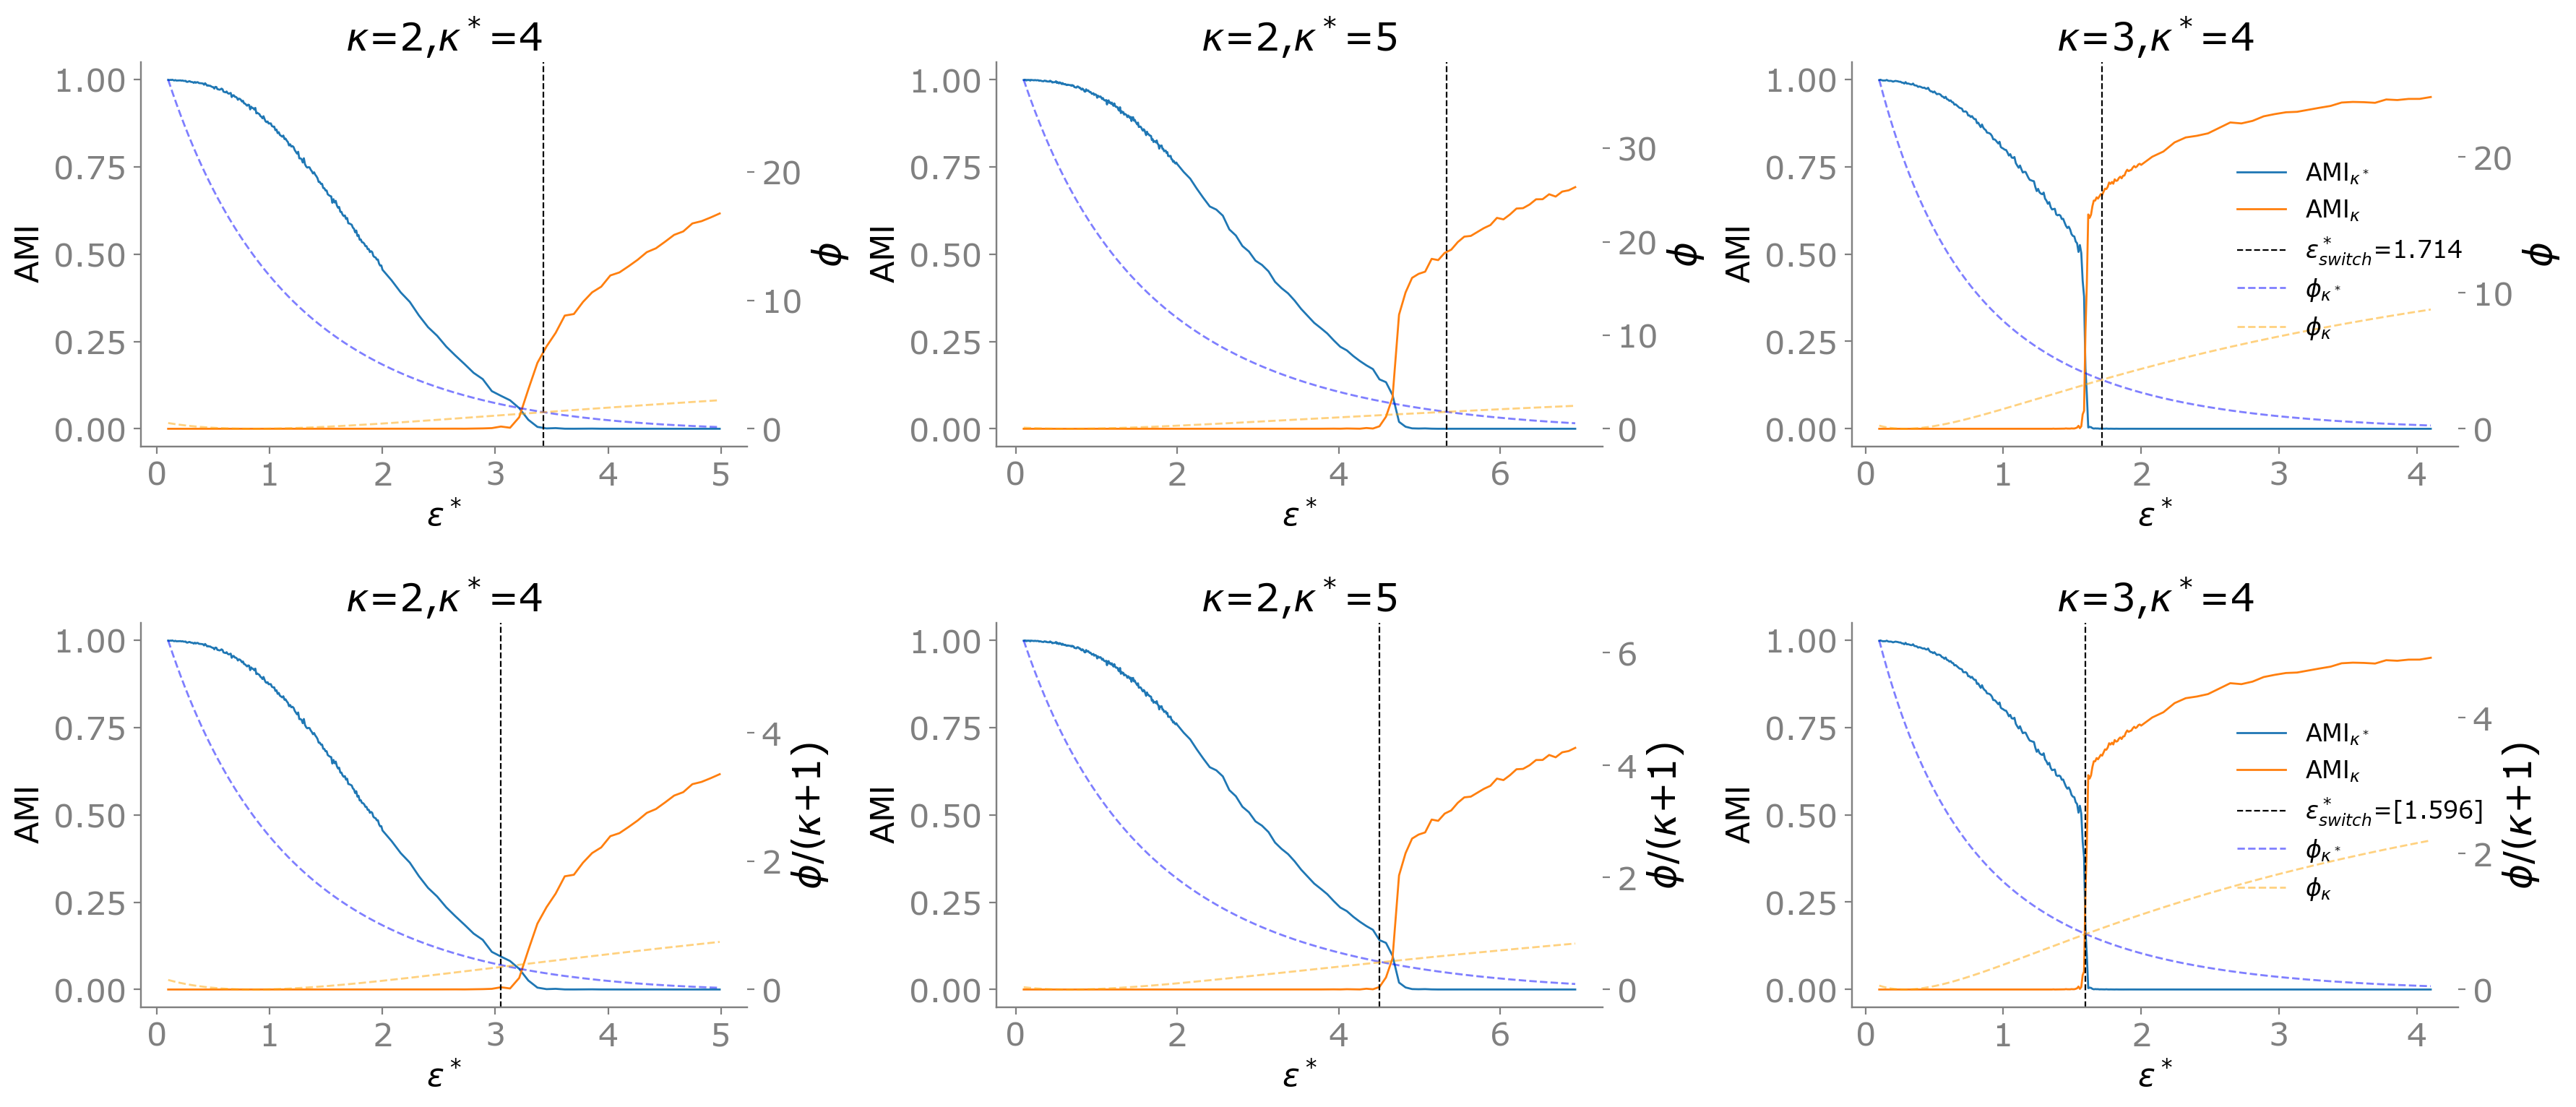

In [39]:
fig = plt.figure(figsize=(18, 8))
widths = [3, 3, 3]
heights = [4, 4]
spec5 = fig.add_gridspec(ncols=3, nrows=2, width_ratios=widths, height_ratios=heights)

row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
n = 8000
d = 10
Ks = (2, 4, )
load_path = f"./result/hyperOrderEffect/exp8.26_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}.txt"
epsilons, results = read_exp(load_path=load_path)
k = Ks[0]
k_star = Ks[1]
epsilon_star_switch = get_epsilon_star_switch(k, k_star)
print(epsilon_star_switch)
index = np.where(epsilons<5)[0]
phi_01_23 = []
phi_02_13 = []
for e in epsilons[index]:
    a, astar = get_a_over_astar(e, k, k_star, d)
    phi_01_23.append(get_phi(a, astar, k, k_star, community_conf="01_23"))
    phi_02_13.append(get_phi(a, astar, k, k_star, community_conf="02_13"))
phi_01_23 = np.array(phi_01_23)
phi_02_13 = np.array(phi_02_13)
plot_ami_phi(ax, epsilons=epsilons[index], ami_kstar=results[index, 1], ami=results[index, 2], 
             phi_kstar=phi_01_23, phi=phi_02_13, epsilon_switch=epsilon_star_switch, 
             title=rf"$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}", show_legend=False)

row = 1
ax = fig.add_subplot(spec5[row, col])
phi_01_23 = phi_01_23/(k_star+denominator_bias)
phi_02_13 = phi_02_13/(k+denominator_bias)
diff = phi_01_23 - phi_02_13
indices = np.where(np.sign(diff[:-1]) * np.sign(diff[1:]) < 0)[0]
epsilon_star_switch = epsilons[index][indices]
plot_ami_phi(ax, epsilons=epsilons[index], ami_kstar=results[index, 1], ami=results[index, 2], 
             phi_kstar=phi_01_23, phi=phi_02_13, phi_ylabel=rf'$\phi / (\kappa$+{denominator_bias})',  epsilon_switch=epsilon_star_switch, 
             title=rf"$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}", show_legend=False)


row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
n = 8000
d = 10
Ks = (2, 5, )
load_path = f"./result/hyperOrderEffect/exp8.26_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}.txt"
epsilons, results = read_exp(load_path=load_path)
k = Ks[0]
k_star = Ks[1]
epsilon_star_switch = get_epsilon_star_switch(k, k_star)
print(epsilon_star_switch)
index = np.where(epsilons<7)[0]
phi_01_23 = []
phi_02_13 = []
for e in epsilons[index]:
    a, astar = get_a_over_astar(e, k, k_star, d)
    phi_01_23.append(get_phi(a, astar, k, k_star, community_conf="01_23"))
    phi_02_13.append(get_phi(a, astar, k, k_star, community_conf="02_13"))
phi_01_23 = np.array(phi_01_23)
phi_02_13 = np.array(phi_02_13)
plot_ami_phi(ax, epsilons=epsilons[index], ami_kstar=results[index, 1], ami=results[index, 2], 
             phi_kstar=phi_01_23, phi=phi_02_13, epsilon_switch=epsilon_star_switch, 
             title=rf"$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}", show_legend=False)

row = 1
ax = fig.add_subplot(spec5[row, col])
phi_01_23 = phi_01_23/(k_star+denominator_bias)
phi_02_13 = phi_02_13/(k+denominator_bias)
diff = phi_01_23 - phi_02_13
indices = np.where(np.sign(diff[:-1]) * np.sign(diff[1:]) < 0)[0]
epsilon_star_switch = epsilons[index][indices]
plot_ami_phi(ax, epsilons=epsilons[index], ami_kstar=results[index, 1], ami=results[index, 2], 
             phi_kstar=phi_01_23, phi=phi_02_13, phi_ylabel=rf'$\phi / (\kappa$+{denominator_bias})',  epsilon_switch=epsilon_star_switch, 
             title=rf"$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}", show_legend=False)

row = 0
col = 2
ax = fig.add_subplot(spec5[row, col])
n = 8000
d = 10
Ks = (3, 4, )
load_path = f"./result/hyperOrderEffect/exp8.26_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}.txt"
epsilons, results = read_exp(load_path=load_path)
k = Ks[0]
k_star = Ks[1]
epsilon_star_switch = get_epsilon_star_switch(k, k_star)
print(epsilon_star_switch)
index = np.where(epsilons<7)[0]
phi_01_23 = []
phi_02_13 = []
for e in epsilons[index]:
    a, astar = get_a_over_astar(e, k, k_star, d)
    phi_01_23.append(get_phi(a, astar, k, k_star, community_conf="01_23"))
    phi_02_13.append(get_phi(a, astar, k, k_star, community_conf="02_13"))
phi_01_23 = np.array(phi_01_23)
phi_02_13 = np.array(phi_02_13)
plot_ami_phi(ax, epsilons=epsilons[index], ami_kstar=results[index, 1], ami=results[index, 2], 
             phi_kstar=phi_01_23, phi=phi_02_13, epsilon_switch=epsilon_star_switch, 
             title=rf"$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}", show_legend=True)

row = 1
ax = fig.add_subplot(spec5[row, col])
phi_01_23 = phi_01_23/(k_star+denominator_bias)
phi_02_13 = phi_02_13/(k+denominator_bias)
diff = phi_01_23 - phi_02_13
indices = np.where(np.sign(diff[:-1]) * np.sign(diff[1:]) < 0)[0]
epsilon_star_switch = epsilons[index][indices]
plot_ami_phi(ax, epsilons=epsilons[index], ami_kstar=results[index, 1], ami=results[index, 2], 
             phi_kstar=phi_01_23, phi=phi_02_13, phi_ylabel=rf'$\phi / (\kappa$+{denominator_bias})',  epsilon_switch=epsilon_star_switch, 
             title=rf"$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}", show_legend=True)


plt.tight_layout()

In [33]:
denominator_bias = 1

1.5555555555555556
7.055118110236221


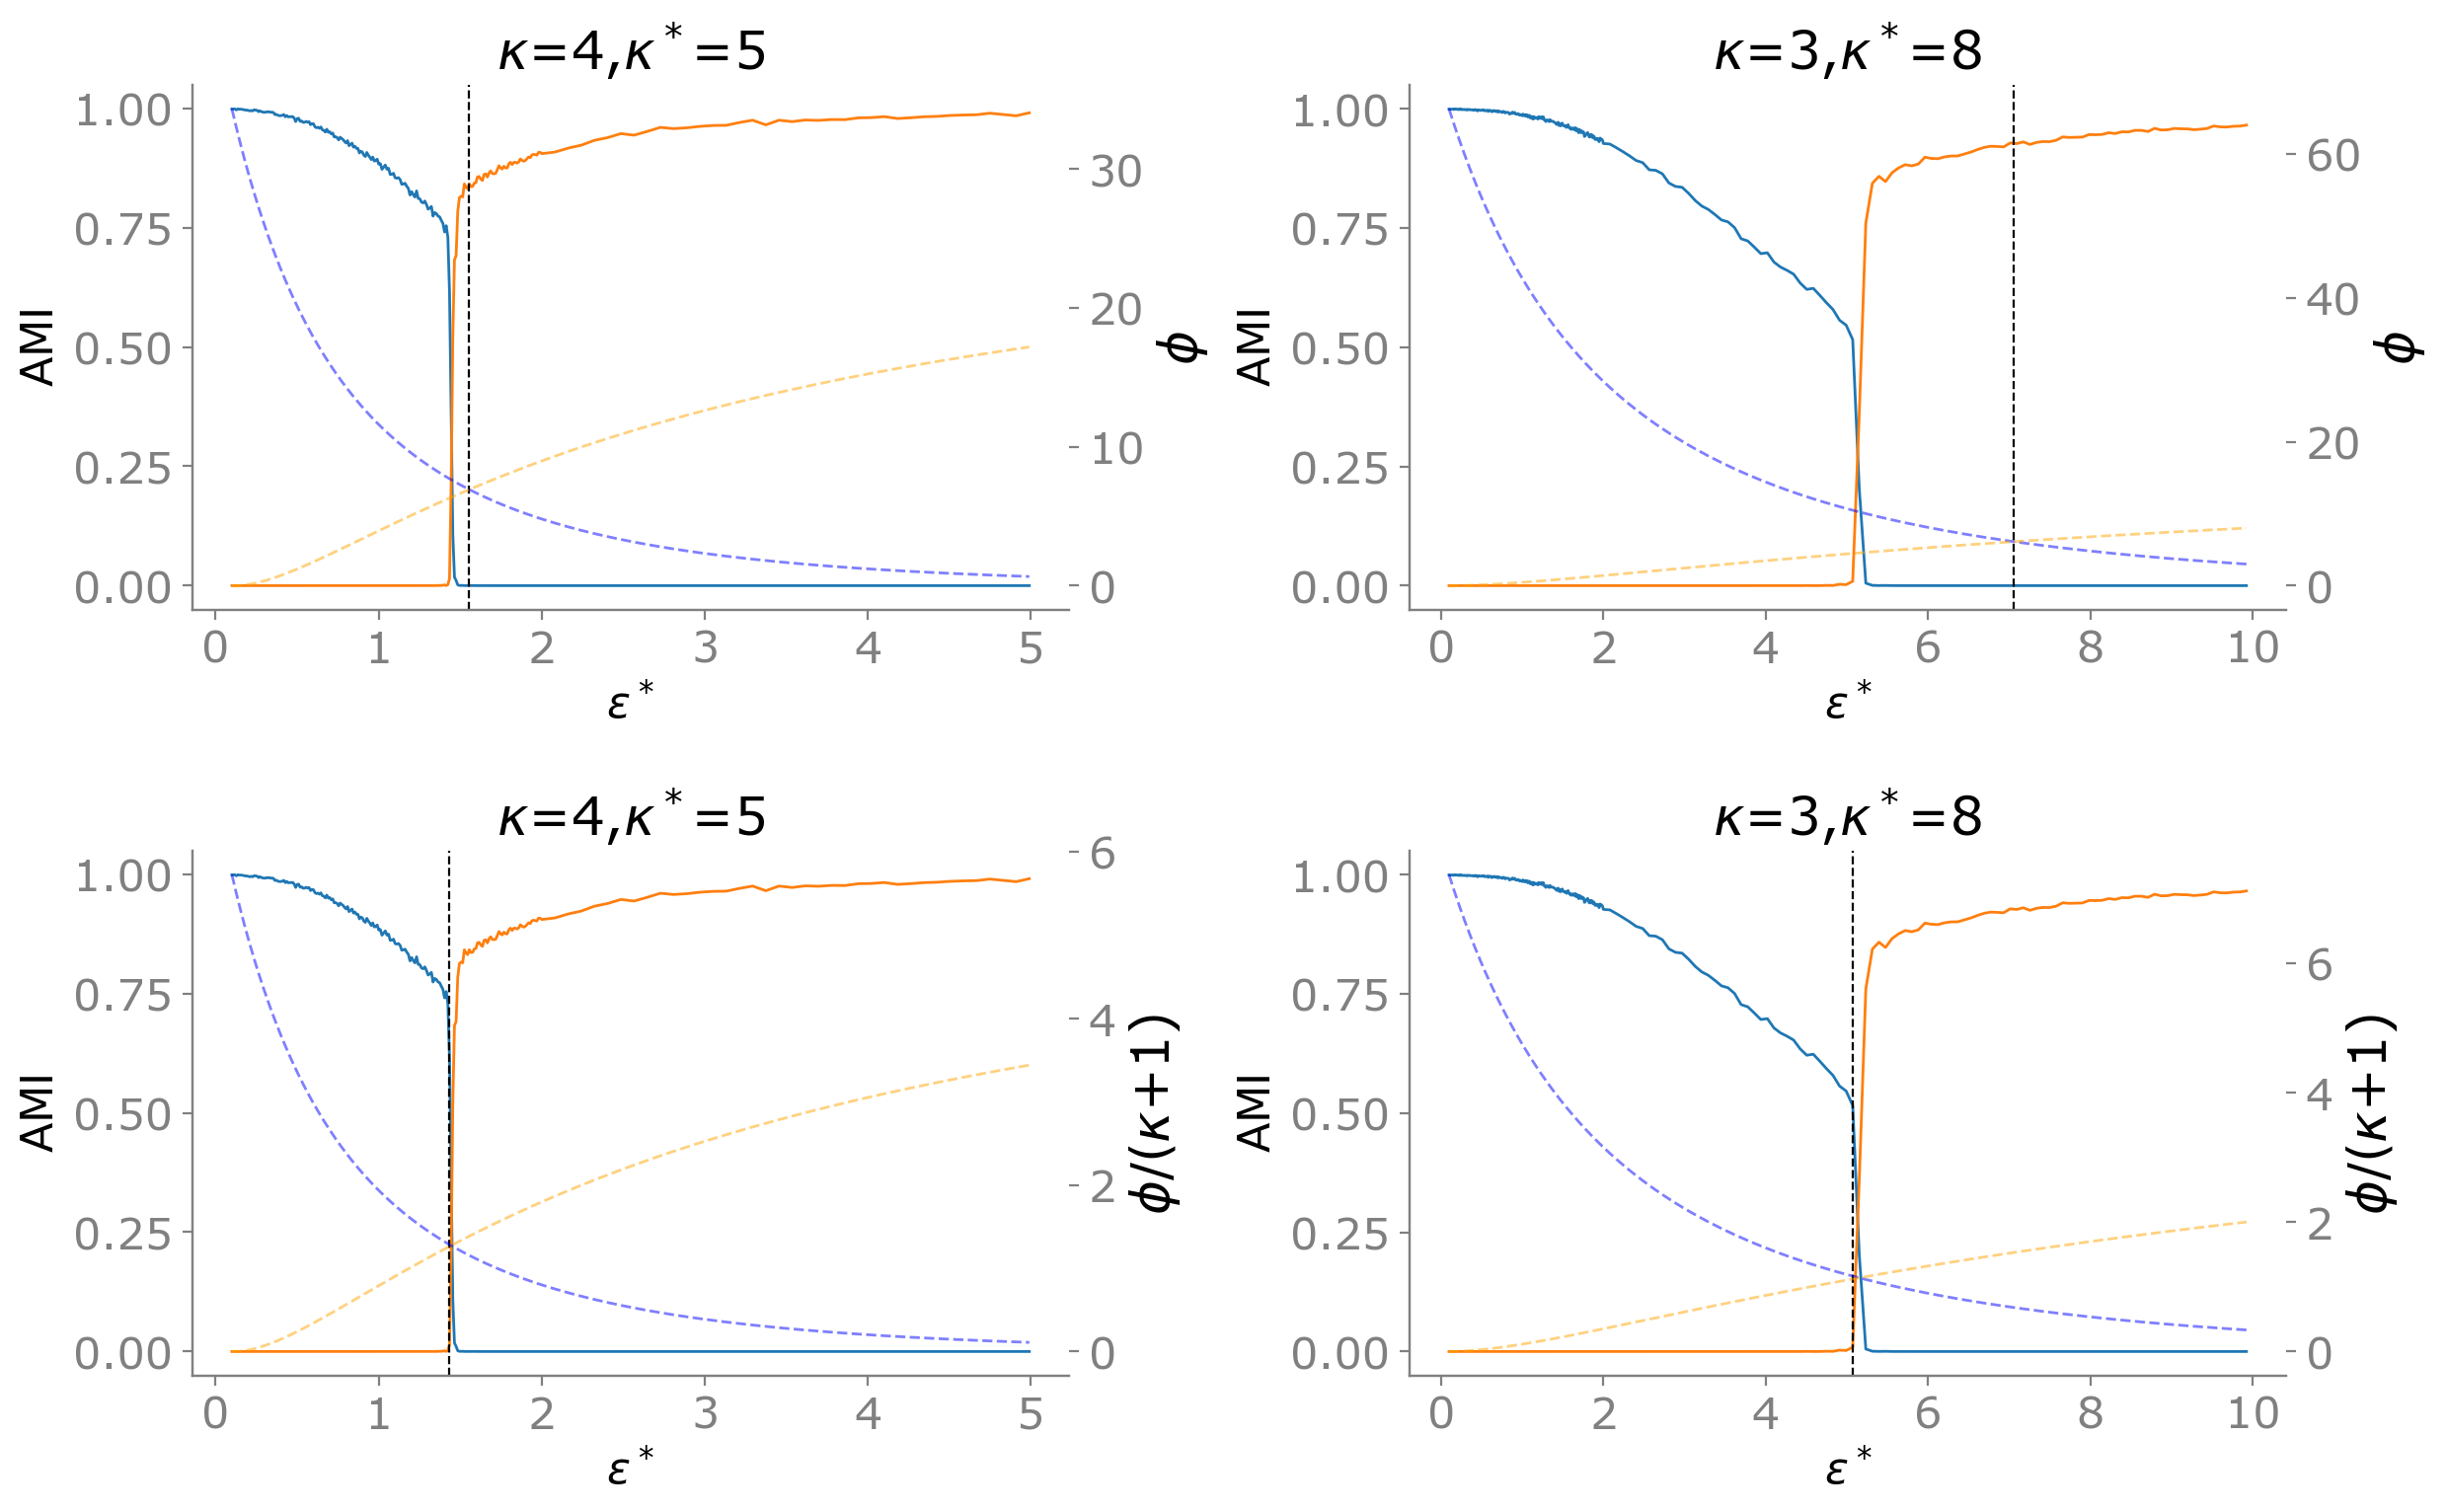

In [105]:
fig = plt.figure(figsize=(18, 8))
widths = [3, 3, 3]
heights = [4, 4]
spec5 = fig.add_gridspec(ncols=3, nrows=2, width_ratios=widths, height_ratios=heights)

row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
n = 8000
d = 10
Ks = (4, 5, )
load_path = f"./result/hyperOrderEffect/exp10.12_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}.txt"
epsilons, results = read_exp(load_path=load_path)
# print(np.shape(results))
k = Ks[0]
k_star = Ks[1]
epsilon_star_switch = get_epsilon_star_switch(k, k_star)
print(epsilon_star_switch)
index = np.where(epsilons<5)[0]
phi_01_23 = []
phi_02_13 = []
for e in epsilons[index]:
    a, astar = get_a_over_astar(e, k, k_star, d)
    phi_01_23.append(get_phi(a, astar, k, k_star, community_conf="01_23"))
    phi_02_13.append(get_phi(a, astar, k, k_star, community_conf="02_13"))
phi_01_23 = np.array(phi_01_23)
phi_02_13 = np.array(phi_02_13)
plot_ami_phi(ax, epsilons=epsilons[index], ami_kstar=results[index, 1], ami=results[index, 2], 
             phi_kstar=phi_01_23, phi=phi_02_13, epsilon_switch=epsilon_star_switch, 
             title=rf"$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}", show_legend=False)

row = 1
ax = fig.add_subplot(spec5[row, col])
phi_01_23 = phi_01_23/(k_star+denominator_bias)
phi_02_13 = phi_02_13/(k+denominator_bias)
diff = phi_01_23 - phi_02_13
indices = np.where(np.sign(diff[:-1]) * np.sign(diff[1:]) < 0)[0]
epsilon_star_switch = epsilons[index][indices]
plot_ami_phi(ax, epsilons=epsilons[index], ami_kstar=results[index, 1], ami=results[index, 2], 
             phi_kstar=phi_01_23, phi=phi_02_13, phi_ylabel=rf'$\phi / (\kappa$+{denominator_bias})',  epsilon_switch=epsilon_star_switch, 
             title=rf"$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}", show_legend=False)


row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
n = 8000
d = 10
Ks = (3, 8, )
load_path = f"./result/hyperOrderEffect/exp10.12_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}.txt"
epsilons, results = read_exp(load_path=load_path)
# print(np.shape(results))
k = Ks[0]
k_star = Ks[1]
epsilon_star_switch = get_epsilon_star_switch(k, k_star)
print(epsilon_star_switch)
index = np.where(epsilons<10)[0]
phi_01_23 = []
phi_02_13 = []
for e in epsilons[index]:
    a, astar = get_a_over_astar(e, k, k_star, d)
    phi_01_23.append(get_phi(a, astar, k, k_star, community_conf="01_23"))
    phi_02_13.append(get_phi(a, astar, k, k_star, community_conf="02_13"))
phi_01_23 = np.array(phi_01_23)
phi_02_13 = np.array(phi_02_13)
plot_ami_phi(ax, epsilons=epsilons[index], ami_kstar=results[index, 1], ami=results[index, 2], 
             phi_kstar=phi_01_23, phi=phi_02_13, epsilon_switch=epsilon_star_switch, 
             title=rf"$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}", show_legend=False)

row = 1
ax = fig.add_subplot(spec5[row, col])
phi_01_23 = phi_01_23/(k_star+denominator_bias)
phi_02_13 = phi_02_13/(k+denominator_bias)
diff = phi_01_23 - phi_02_13
indices = np.where(np.sign(diff[:-1]) * np.sign(diff[1:]) < 0)[0]
epsilon_star_switch = epsilons[index][indices]
plot_ami_phi(ax, epsilons=epsilons[index], ami_kstar=results[index, 1], ami=results[index, 2], 
             phi_kstar=phi_01_23, phi=phi_02_13, phi_ylabel=rf'$\phi / (\kappa$+{denominator_bias})',  epsilon_switch=epsilon_star_switch, 
             title=rf"$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}", show_legend=False)

# row = 0
# col = 2
# ax = fig.add_subplot(spec5[row, col])
# n = 8000
# d = 10
# Ks = (3, 4, )
# load_path = f"./result/hyperOrderEffect/exp8.26_onlyassort_amiwith2settinggroup_n{n}_d{d}_k{Ks[0]}_kstar{Ks[1]}.txt"
# epsilons, results = read_exp(load_path=load_path)
# k = Ks[0]
# k_star = Ks[1]
# epsilon_star_switch = get_epsilon_star_switch(k, k_star)
# print(epsilon_star_switch)
# index = np.where(epsilons<7)[0]
# phi_01_23 = []
# phi_02_13 = []
# for e in epsilons[index]:
#     a, astar = get_a_over_astar(e, k, k_star, d)
#     phi_01_23.append(get_phi(a, astar, k, k_star, community_conf="01_23"))
#     phi_02_13.append(get_phi(a, astar, k, k_star, community_conf="02_13"))
# phi_01_23 = np.array(phi_01_23)
# phi_02_13 = np.array(phi_02_13)
# plot_ami_phi(ax, epsilons=epsilons[index], ami_kstar=results[index, 1], ami=results[index, 2], 
#              phi_kstar=phi_01_23, phi=phi_02_13, epsilon_switch=epsilon_star_switch, 
#              title=rf"$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}", show_legend=False)

# row = 1
# ax = fig.add_subplot(spec5[row, col])
# phi_01_23 = phi_01_23/(k_star+denominator_bias)
# phi_02_13 = phi_02_13/(k+denominator_bias)
# diff = phi_01_23 - phi_02_13
# indices = np.where(np.sign(diff[:-1]) * np.sign(diff[1:]) < 0)[0]
# epsilon_star_switch = epsilons[index][indices]
# plot_ami_phi(ax, epsilons=epsilons[index], ami_kstar=results[index, 1], ami=results[index, 2], 
#              phi_kstar=phi_01_23, phi=phi_02_13, phi_ylabel=rf'$\phi / (\kappa$+{denominator_bias})',  epsilon_switch=epsilon_star_switch, 
#              title=rf"$\kappa$={Ks[0]},$\kappa^*$={Ks[1]}", show_legend=False)


plt.tight_layout()